In [13]:
import os
import sys
import random
import numpy as np
import cv2
import torch
import seaborn as sns
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.optim.lr_scheduler import ExponentialLR
from tqdm import tqdm
from PIL import Image
from dataclasses import dataclass
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt
from collections import Counter
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score

In [14]:
def seed_everything(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything()

In [50]:
@dataclass
class CFG: 
    batch_size : int = 32  
    seed: int = 42
    early_stopping_steps :int = 7
    number_of_channels : int = 3
    steps_until_plot: int = 3
    criterion : nn.Module = nn.CrossEntropyLoss(label_smoothing=0.1)
    epochs : int = 70
    device : str = 'mps' if torch.backends.mps.is_available() else 'cpu'
    img_size : int = 96
    base_path : str = 'imagebits'
    number_of_pictures_example: int = 5
    train_path : str = os.path.join(base_path, 'train')
    test_path : str = os.path.join(base_path, 'test')
    image_extension : str = '.png'
    mapping_between_folders_and_classes = {
        'airplane': '1',
        'bird': '2',
        'car': '3',
        'cat': '4',
        'deer': '5',
        'dog': '6',
        'horse': '7',
        'monkey': '8',
        'ship': '9',
        'truck': '10'
    }
    num_classes : int = len(mapping_between_folders_and_classes)
    imagenet_mean  = [0.485, 0.456, 0.406]
    imagenet_std  = [0.229, 0.224, 0.225]

In [4]:
class_distribution = {}

for class_folder in sorted(os.listdir(CFG.train_path)):
    class_path = os.path.join(CFG.train_path, class_folder)
    if os.path.isdir(class_path):
        num_images = len([f for f in os.listdir(class_path) if f.endswith(CFG.image_extension)])
        class_distribution[class_folder] = num_images

In [5]:
def remap_dictionary_keys_to_names_of_objects(original_dictionary):
    reversed_mapping = {v: k for k, v in CFG.mapping_between_folders_and_classes.items()}
    return {reversed_mapping.get(k, k): v for k, v in original_dictionary.items()}

new_dictionary = remap_dictionary_keys_to_names_of_objects(class_distribution)


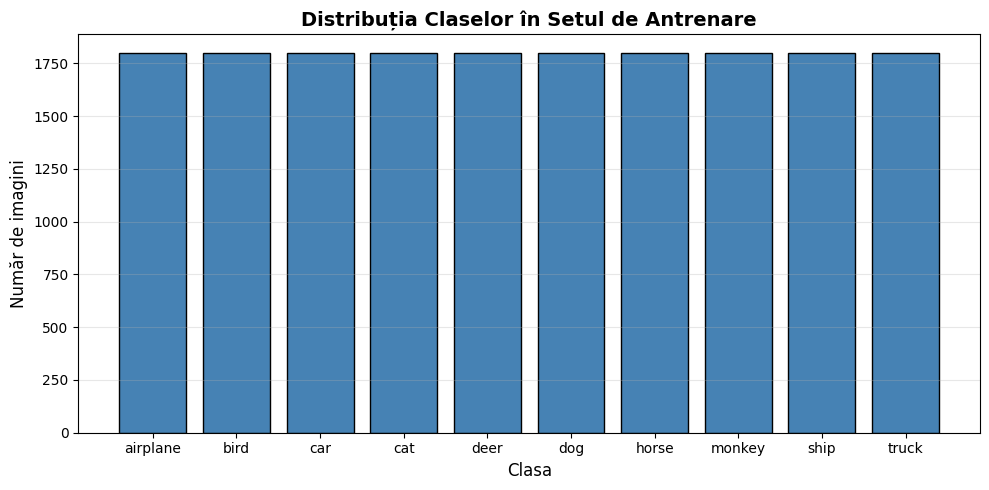

In [6]:
plt.figure(figsize=(10, 5))
classes = sorted(new_dictionary.keys(), key=lambda x: int(CFG.mapping_between_folders_and_classes[x]))
counts = [new_dictionary[c] for c in classes]
plt.bar(classes, counts, color='steelblue', edgecolor='black')
plt.xlabel('Clasa', fontsize=12)
plt.ylabel('Număr de imagini', fontsize=12)
plt.title('Distribuția Claselor în Setul de Antrenare', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
is_balanced = len(set(class_distribution.values())) == 1
print(f"Dataset-ul este {'Echilibrat' if is_balanced else 'Dezechilibrat'}")

Dataset-ul este Echilibrat


In [20]:
def get_parameters_for_type_of_operation(type = 'picture_stats'):
    if type == 'picture_stats':
        return [],{}
    elif type == 'correlation_purpose':
        return [],[]
    elif type == 'plot_images':
        return [],[]
    elif type == 'make_csv_files':
        return [],[]
    
    return None

In [21]:
def get_random_images_to_plot(all_images):
    random.seed(CFG.seed)
    return random.sample(all_images, min(CFG.number_of_pictures_example, len(all_images)))

In [22]:
def set_path(train=True):
    return CFG.train_path if train else CFG.test_path

In [23]:
def get_path(class_idx,train=True):
    return os.path.join(set_path(train), str(class_idx))

In [24]:
def get_all_images(class_idx,train=True):
    return [f for f in os.listdir(get_path(class_idx,train)) if f.endswith(CFG.image_extension)]

In [25]:
def read_images(image_name,class_idx,train=True):
    img_path = os.path.join(get_path(class_idx,train),image_name)
    return img_path, cv2.imread(img_path)

In [26]:
def prepare_plot():
    fig, axes = plt.subplots(CFG.num_classes, CFG.number_of_pictures_example, figsize=(16, 20))
    fig.suptitle('Exemple din Fiecare Clasă - Variabilitate Intra-Clasă', fontsize=16, fontweight='bold')
    return fig, axes

In [55]:
def plot_examples_from_dataset(image,axes,class_idx,img_idx):
    ax = axes[class_idx - 1, img_idx]
    ax.imshow(image)
    ax.axis('off')
        
    if img_idx == 0:
        ax.set_title(f'Clasa {class_idx}', fontsize=12, fontweight='bold', loc='left')

In [18]:
def process_all_images(number_of_classes=CFG.num_classes, operation_type='picture_stats', train=True):
    container1, container2 = get_parameters_for_type_of_operation(operation_type)

    if operation_type == 'plot_images':
        _, axes = prepare_plot()
    
    for class_idx in range(1, number_of_classes + 1):
        all_images = get_all_images(class_idx, train=train)

        if operation_type == 'plot_images':
            all_images = get_random_images_to_plot(all_images)
        
        class_pixels = [] 
        for img_name in all_images:
            img_path, image = read_images(img_name, class_idx, train=train)
            
            if image is None:
                continue
            
            if operation_type == 'picture_stats':
                container1.append(image.shape[:2]) 
                class_pixels.append(np.array(image))
                
            elif operation_type == 'correlation_purpose':
                image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                vector = image_rgb.flatten()
                container1.append(vector)
                container2.append(class_idx)
                
            elif operation_type == 'plot_images':
                image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                plot_examples_from_dataset(image_rgb, axes, class_idx, img_idx=all_images.index(img_name))

            elif operation_type == 'make_csv_files':
                container1.append({'ID': img_path, 'label': class_idx})
                
        if operation_type == 'picture_stats' and class_pixels:
            class_pixels_np = np.array(class_pixels)
            container2[class_idx] = {
                'mean': np.mean(class_pixels_np),
                'std': np.std(class_pixels_np),
                'min': np.min(class_pixels_np),
                'max': np.max(class_pixels_np)
            }

    if operation_type == 'correlation_purpose':
        return np.array(container1), np.array(container2)
    
    if operation_type == 'plot_images':
        plt.tight_layout()
        plt.show()
    
    return container1, container2

In [17]:
image_sizes, pixel_stats_per_class = process_all_images()
print(f"\n{'Dimensiuni imagini:':<25} {Counter(image_sizes).most_common(1)[0][0]}")

print("-" * 60)
print("Statistici pixeli per clasă (Media ± Deviație Standard):")
print("-" * 60)

for class_idx in range(1, CFG.num_classes + 1):
    stats = pixel_stats_per_class[class_idx]
    print(f"Clasa {class_idx:2d}: {stats['mean']:6.2f} ± {stats['std']:6.2f}  (min: {stats['min']:3.0f}, max: {stats['max']:3.0f})")

print("=" * 60)


Dimensiuni imagini:       (96, 96)
------------------------------------------------------------
Statistici pixeli per clasă (Media ± Deviație Standard):
------------------------------------------------------------
Clasa  1: 132.09 ±  63.90  (min:   0, max: 255)
Clasa  2: 114.48 ±  63.07  (min:   0, max: 255)
Clasa  3:  91.31 ±  71.56  (min:   0, max: 255)
Clasa  4: 105.74 ±  60.70  (min:   0, max: 255)
Clasa  5: 111.49 ±  57.00  (min:   0, max: 255)
Clasa  6: 111.10 ±  64.86  (min:   0, max: 255)
Clasa  7: 103.40 ±  64.33  (min:   0, max: 255)
Clasa  8: 103.74 ±  61.17  (min:   0, max: 255)
Clasa  9: 119.04 ±  70.17  (min:   0, max: 255)
Clasa 10: 100.86 ±  75.39  (min:   0, max: 255)


In [18]:
X, y = process_all_images(operation_type = 'correlation_purpose')
corr_matrix = np.corrcoef(X)

intra_correlations = []
inter_correlations = []
num_samples = len(y)

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

class_mask = (y[:, None] == y[None, :]) & mask

intra_correlations = corr_matrix[class_mask]
inter_correlations = corr_matrix[mask & ~class_mask]

avg_intra = np.mean(intra_correlations)
avg_inter = np.mean(inter_correlations)

print(f"Average Intra-class Correlation (Consistency): {avg_intra:.4f}")
print(f"Average Inter-class Correlation (Confusion):   {avg_inter:.4f}")
print(f"Separability Score (Intra - Inter):            {avg_intra - avg_inter:.4f}")

Average Intra-class Correlation (Consistency): 0.0795
Average Inter-class Correlation (Confusion):   0.0211
Separability Score (Intra - Inter):            0.0584


/Users/denis2104/Desktop/Tema 2 IA/.venv/lib/python3.14/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/denis2104/Desktop/Tema 2 IA/.venv/lib/python3.14/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/denis2104/Desktop/Tema 2 IA/.venv/lib/python3.14/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/denis2104/Desktop/Tema 2 IA/.venv/lib/python3.14/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/denis2104/Desktop/Tema 2 IA/.venv/lib/python3.14/site-packages/scipy/_lib/_util.py:1280: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/denis2104/Desktop/Tema 2 IA/.venv/lib/python3.14/site-packages/scipy/_l

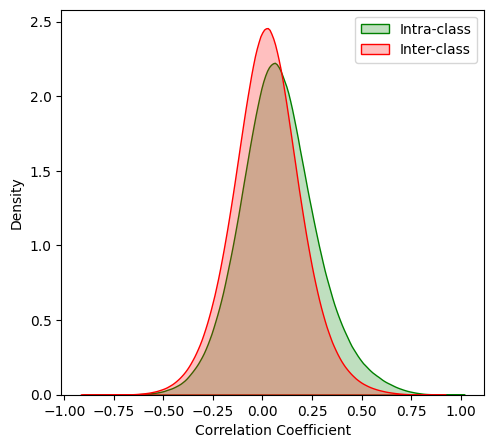

In [19]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.kdeplot(intra_correlations, label='Intra-class', fill=True, color='green')
sns.kdeplot(inter_correlations, label='Inter-class', fill=True, color='red')
plt.xlabel('Correlation Coefficient')
plt.legend()

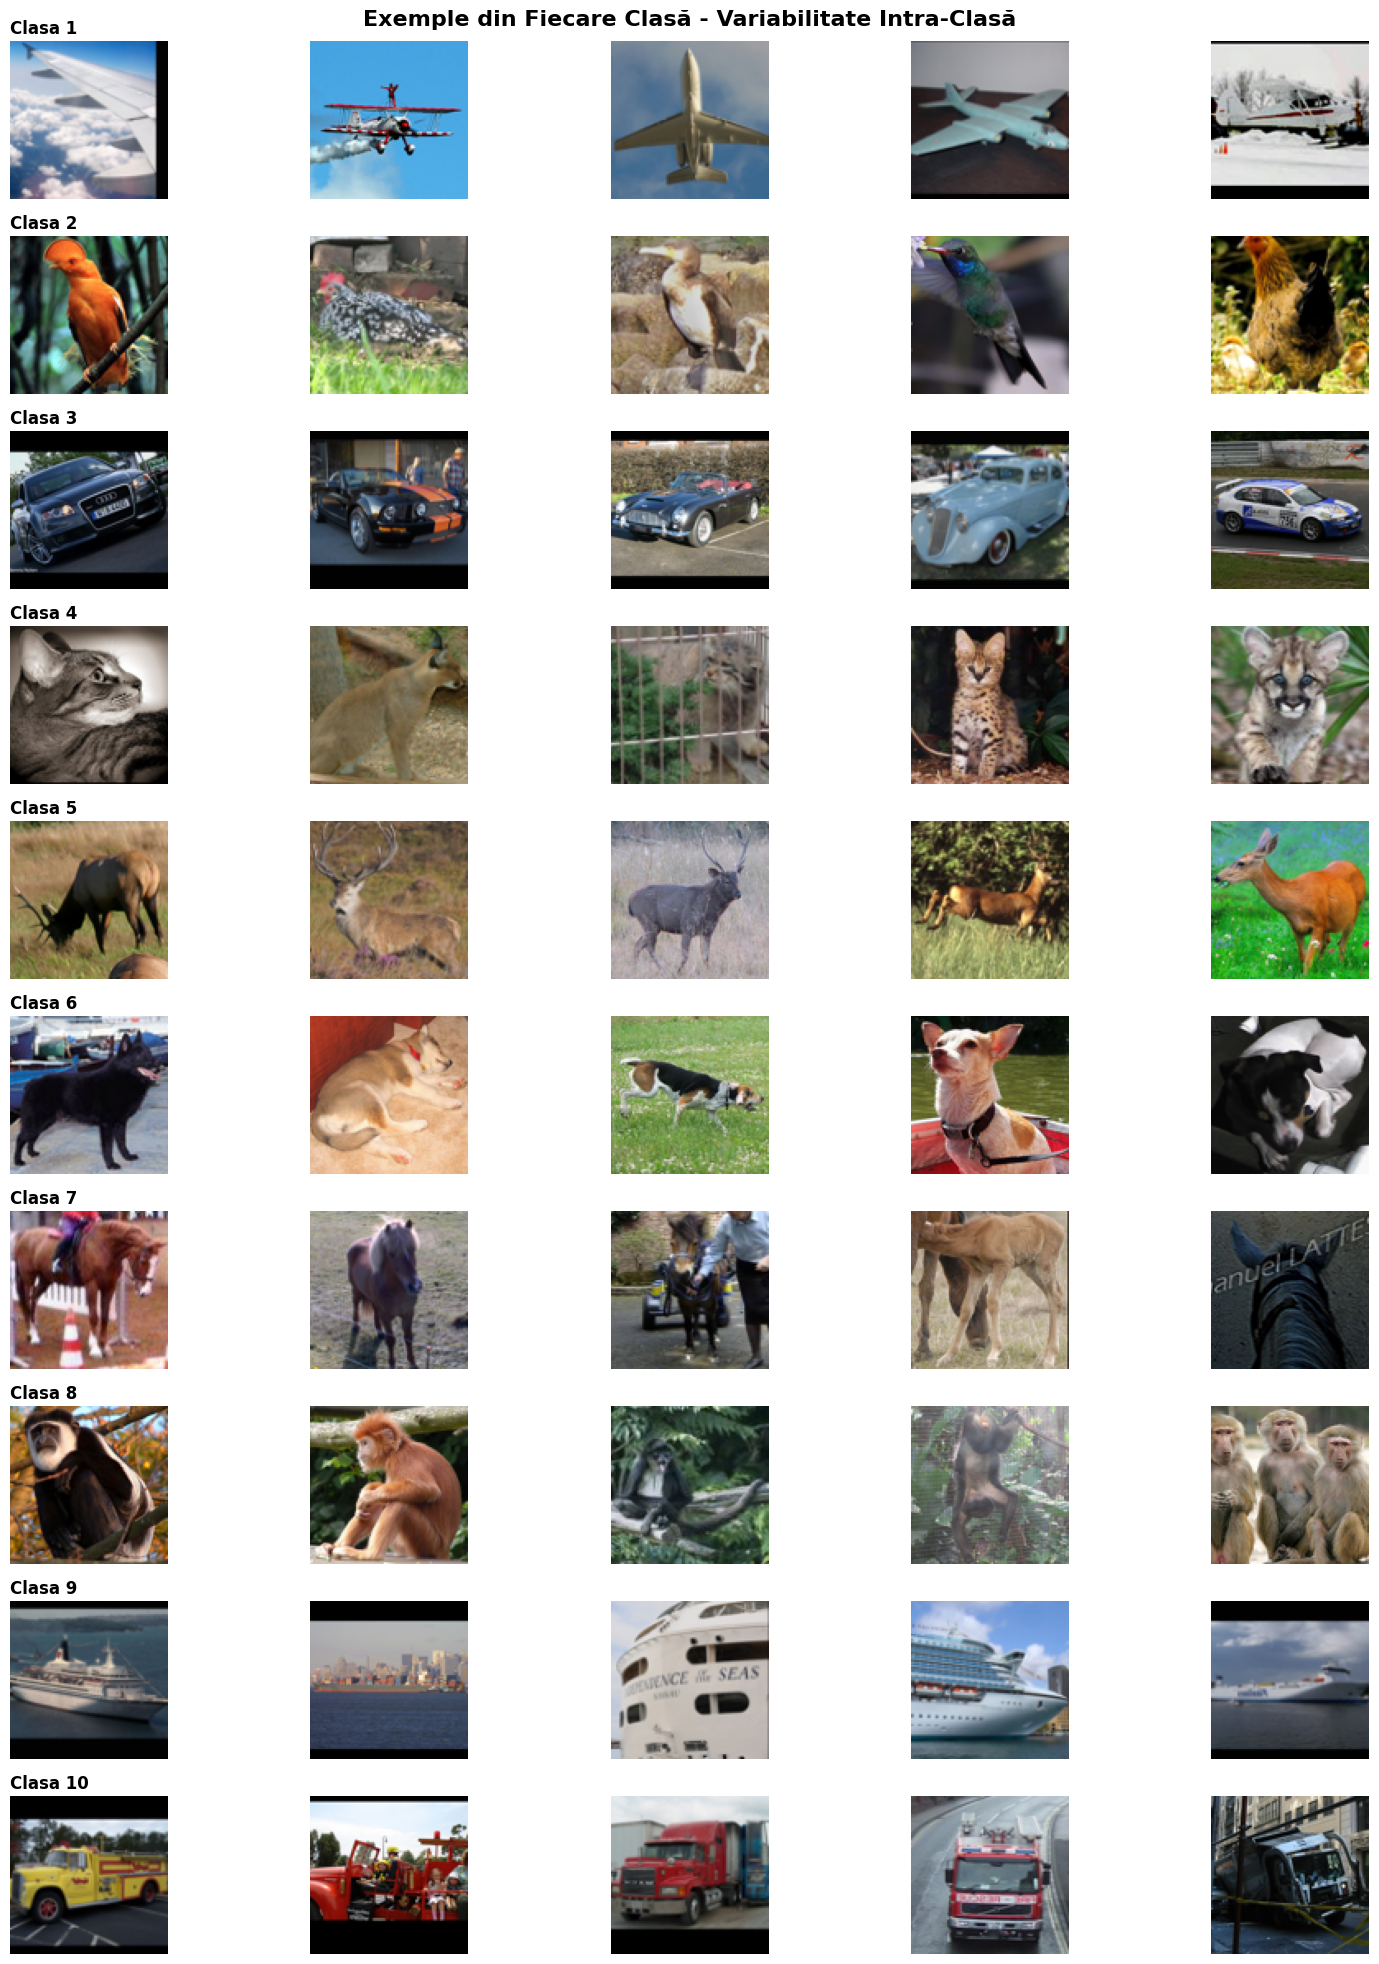

In [20]:
_, _ = process_all_images(operation_type = 'plot_images')

In [15]:
def make_train_and_test_csvs(train=True):
    data, _ = process_all_images(operation_type='make_csv_files', train=train)
    return pd.DataFrame(data)

In [16]:
def locate_csv_to_folders(train=True):
    df = make_train_and_test_csvs(train=train)
    split_name = "train" if train else "test"
    csv_path = os.path.join(set_path(train), f"{split_name}_data.csv")
    df.to_csv(csv_path, index=False)

In [28]:
locate_csv_to_folders(train=True)
locate_csv_to_folders(train=False)

In [29]:
train_set = pd.read_csv(f'{CFG.train_path}/train_data.csv')
test_set = pd.read_csv(f'{CFG.test_path}/test_data.csv')

In [30]:
train_set, val_set = train_test_split(
    train_set, 
    test_size=0.20, 
    stratify=train_set['label'], 
    random_state=CFG.seed
)

In [31]:
def return_images_per_label(df):
    label_dictionary_of_images = {}
    for row in df.itertuples():
        label = row.ID.split('/')[-2]
        if label not in label_dictionary_of_images:
            label_dictionary_of_images[label] = []

        label_dictionary_of_images[label].append(row.ID)

    return label_dictionary_of_images

In [32]:
augmentation_transform = transforms.Compose([
    transforms.RandomRotation(degrees=(-8, 8)),
    transforms.RandomResizedCrop(size=(CFG.img_size, CFG.img_size), scale=(0.9, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.05, contrast=0.05)
])

train_images_by_label = return_images_per_label(train_set)

target_count = 1200

for label, train_image_paths in train_images_by_label.items():
    folder_name = str(label)
    folder_path = os.path.join(CFG.train_path, folder_name)
    
    train_image_names = [os.path.basename(path) for path in train_image_paths]
    
    num_current = len(train_image_names)
    num_needed = target_count - num_current
    
    if num_needed > 0 and target_count > num_current:
        print(f"Class {label}: Found {num_current} training images. Generating {num_needed} synthetic...")
        
        generated = 0
        while generated < num_needed:
            source_img_name = random.choice(train_image_names)
            source_img_path = os.path.join(folder_path, source_img_name)
            
            image = Image.open(source_img_path).convert('RGB')
            image = transforms.Resize((CFG.img_size, CFG.img_size))(image)
            
            augmented_image = augmentation_transform(image)
            
            aug_filename = f'aug_{generated}_{source_img_name}'
            aug_path = os.path.join(folder_path, aug_filename)
            augmented_image.save(aug_path)
            
            generated += 1
            
            if (generated % 100) == 0:
                print(f"  Generated {generated}/{num_needed} images for class {label}")
    else:
        print(f"Class {label}: Already has {num_current} images (>= {target_count})")
                
print(f"\nSynthetic data generation complete!")
print(f"Training set now has ~{target_count} images per class")
print(f"Validation set remains unchanged with original images only")

Class 3: Found 640 training images. Generating 560 synthetic...
  Generated 100/560 images for class 3
  Generated 200/560 images for class 3
  Generated 300/560 images for class 3
  Generated 400/560 images for class 3
  Generated 500/560 images for class 3
Class 7: Found 640 training images. Generating 560 synthetic...
  Generated 100/560 images for class 7
  Generated 200/560 images for class 7
  Generated 300/560 images for class 7
  Generated 400/560 images for class 7
  Generated 500/560 images for class 7
Class 2: Found 640 training images. Generating 560 synthetic...
  Generated 100/560 images for class 2
  Generated 200/560 images for class 2
  Generated 300/560 images for class 2
  Generated 400/560 images for class 2
  Generated 500/560 images for class 2
Class 9: Found 640 training images. Generating 560 synthetic...
  Generated 100/560 images for class 9
  Generated 200/560 images for class 9
  Generated 300/560 images for class 9
  Generated 400/560 images for class 9
  G

In [33]:
# REBUILD train_set to include synthetic data
print("\nRebuilding training dataset to include synthetic images...")

# Recreate CSV with ALL images (original + synthetic) from folders
train_data_with_synthetic = []
for class_idx in range(1, CFG.num_classes + 1):
    class_folder = os.path.join(CFG.train_path, str(class_idx))
    all_images = [f for f in os.listdir(class_folder) if f.endswith(CFG.image_extension)]
    
    for img_name in all_images:
        img_path = os.path.join(class_folder, img_name)
        train_data_with_synthetic.append({'ID': img_path, 'label': class_idx})

train_set_full = pd.DataFrame(train_data_with_synthetic)

# Filter to keep ONLY the training images (original + their synthetic copies)
train_image_basenames = set()
for row in train_set.itertuples():
    train_image_basenames.add(os.path.basename(row.ID))

# Include original training images + all aug_ versions generated from them
train_set_final = []
for row in train_set_full.itertuples():
    img_basename = os.path.basename(row.ID)
    # Keep if it's an original training image OR a synthetic image derived from training
    if img_basename in train_image_basenames or img_basename.startswith('aug_'):
        train_set_final.append({'ID': row.ID, 'label': row.label})

train_set = pd.DataFrame(train_set_final)

print(f"Training set rebuilt: {len(train_set)} total images")
print(f"Validation set unchanged: {len(val_set)} images")

# Print class distribution
train_class_counts = train_set['label'].value_counts().sort_index()
print("\nTraining set distribution:")
for class_idx, count in train_class_counts.items():
    print(f"  Class {class_idx}: {count} images")


Rebuilding training dataset to include synthetic images...
Training set rebuilt: 12000 total images
Validation set unchanged: 1600 images

Training set distribution:
  Class 1: 1200 images
  Class 2: 1200 images
  Class 3: 1200 images
  Class 4: 1200 images
  Class 5: 1200 images
  Class 6: 1200 images
  Class 7: 1200 images
  Class 8: 1200 images
  Class 9: 1200 images
  Class 10: 1200 images


In [34]:
class EarlyStopping:
    def __init__(self, patience=CFG.early_stopping_steps, verbose=False, path='checkpoint.pt', trace_func=print):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = -np.inf
        self.early_stop = False
        self.path = path
        self.trace_func = trace_func

    def __call__(self, current_accuracy, model):
        if current_accuracy <= self.best_score + 1e-6:
            self.counter += 1
            if self.verbose:
                self.trace_func(f"EarlyStopping counter: {self.counter} out of {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            if self.verbose:
                self.trace_func(
                    f"Validation accuracy increased ({self.best_score:.6f} → {current_accuracy:.6f}). Saving model..."
                )
            self.save_checkpoint(model)
            self.best_score = current_accuracy
            self.counter = 0

    def save_checkpoint(self, model):
        torch.save(model.state_dict(), self.path)


In [126]:
class ImprovedMLP(nn.Module):
    def __init__(self, input_size = CFG.number_of_channels * CFG.img_size * CFG.img_size, 
                 hidden_sizes=[512, 256, 128], num_classes=10, dropout_rate=0.35):
        super(ImprovedMLP, self).__init__()
        
        layers = []
        in_features = input_size
        
        for i, hidden in enumerate(hidden_sizes):
            layers.append(nn.Linear(in_features, hidden))
            layers.append(nn.BatchNorm1d(hidden))
            layers.append(nn.ReLU())
            dropout = dropout_rate if i < len(hidden_sizes) - 1 else dropout_rate * 0.5
            layers.append(nn.Dropout(dropout))
            in_features = hidden
            
        layers.append(nn.Linear(in_features, num_classes))
        
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.model(x)

In [127]:
default_transform = transforms.Compose([
    transforms.RandomCrop(size=(CFG.img_size, CFG.img_size), padding=4),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=(-8, 8)),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1)
])


class MyDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

        self.resize = transforms.Resize((CFG.img_size, CFG.img_size))
        self.normalize = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=CFG.imagenet_mean, std=CFG.imagenet_std)
        ])
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx): 
        img_name = self.df.iloc[idx]['ID']
        label = self.df.iloc[idx]['label']
        image = Image.open(f'{img_name}').convert('RGB')

        label = label - 1  

        if self.transform:
            image = self.resize(image)
            image = self.transform(image)
            image = self.normalize(image)
        else:
            image = self.resize(image)
            image = self.normalize(image)
        
        return image, label


train_transform = transforms.Compose([
    transforms.RandomCrop(size=(CFG.img_size, CFG.img_size), padding=4),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=(-8, 8)),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1)
])

train_dataset = MyDataset(train_set, transform=train_transform)
validation_dataset = MyDataset(val_set)
test_dataset = MyDataset(test_set)

train_loader = DataLoader(train_dataset, batch_size=CFG.batch_size, shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=CFG.batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=CFG.batch_size, shuffle=False)

In [128]:
def get_number_of_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [129]:
def top_k_accuracy(k, target, output, device):
    batch_size = target.size(0)
    
    _, pred = output.topk(k, 1, True, True)
    
    pred = pred.t()
    
    correct = pred.eq(target.to(device).view(1, -1).expand_as(pred))
    
    correct_k = correct[:k].reshape(-1).float().sum(0, keepdim=True)
    correct_k = correct_k.mul_(100.0 / batch_size)
    
    return correct_k.item()

In [130]:
def plot_loss_curves(train_losses, val_losses):
    plt.figure(figsize=(10, 6))
    epochs = range(1, len(train_losses) + 1)
    
    plt.plot(epochs, train_losses, 'b-o', label='Training Loss', linewidth=2, markersize=5)
    plt.plot(epochs, val_losses, 'r-o', label='Validation Loss', linewidth=2, markersize=5)
    plt.xlabel('Epoch', fontsize=14)
    plt.ylabel('Loss', fontsize=14)
    plt.title('Curbe de Loss pentru Antrenare și Validare', fontsize=16, fontweight='bold')
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [131]:
def plot_accuracy_curves(train_top1, val_top1):
    plt.figure(figsize=(10, 6))
    epochs = range(1, len(train_top1) + 1)
    
    plt.plot(epochs, train_top1, 'b-o', label='Training Top-1 Accuracy', linewidth=2, markersize=5)
    plt.plot(epochs, val_top1, 'r-o', label='Validation Top-1 Accuracy', linewidth=2, markersize=5)
    plt.xlabel('Epoch', fontsize=14)
    plt.ylabel('Acuratețe (%)', fontsize=14)
    plt.title('Curbe de Acuratețe pentru Antrenare și Validare', fontsize=16, fontweight='bold')
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [132]:
def plot_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=range(1, CFG.num_classes + 1),
                yticklabels=range(1, CFG.num_classes + 1),
                cbar_kws={'label': 'Număr de predicții'})
    plt.xlabel('Predicted Label', fontsize=14)
    plt.ylabel('True Label', fontsize=14)
    plt.title('Matricea de Confuzie', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    return cm

In [133]:
def validate(model, criterion, val_loader, device, epoch):
    model.eval()
    running_loss = 0.0
    running_top1_acc = 0.0
    
    bar = tqdm(enumerate(val_loader), total=len(val_loader), colour='green', file=sys.stdout)
    
    with torch.no_grad():
        for i, (images, labels) in bar:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels.long())
            
            top1_acc = top_k_accuracy(1, labels, outputs, device)
            
            running_loss += loss.item() * images.size(0)
            running_top1_acc += top1_acc * images.size(0)
            
            avg_loss = running_loss / ((i + 1) * images.size(0))
            avg_top1 = running_top1_acc / ((i + 1) * images.size(0))
            
            bar.set_postfix({
                'epoch': epoch,
                'val_loss': f'{avg_loss:.4f}',
                'top1_accuracy': f'{avg_top1:.2f}%'
            })
    
    epoch_loss = running_loss / len(val_loader.dataset)
    epoch_top1 = running_top1_acc / len(val_loader.dataset)
    
    return epoch_loss, epoch_top1

In [134]:
def train_single_model(config, train_loader, val_loader, device, num_epochs=CFG.epochs):
    model = ImprovedMLP().to(device)
    optimizer = optim.AdamW(model.parameters(), lr=config['lr'], weight_decay=config['weight_decay'])
    scheduler = ExponentialLR(optimizer, gamma=config['lr_decay'])
    criterion = CFG.criterion
    early_stopping = EarlyStopping(patience=CFG.early_stopping_steps, verbose=True, path='best_model.pth')
    
    train_losses, train_top1 = [], []
    val_losses, val_top1 = [], []
    
    best_val_acc = 0.0
    
    for epoch in range(1, num_epochs + 1):
        model.train()
        running_loss = 0.0
        running_top1_acc = 0.0
        
        bar = tqdm(enumerate(train_loader), total=len(train_loader), colour='cyan', file=sys.stdout)

        for i, (images, labels) in bar:
            images = images.to(device)
            labels = labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            
            loss = criterion(outputs, labels.long())
            loss.backward()
            optimizer.step()
            
            top1_acc = top_k_accuracy(1, labels, outputs, device)
            
            running_loss += loss.item() * images.size(0)
            running_top1_acc += top1_acc * images.size(0)

            avg_loss = running_loss / ((i + 1) * images.size(0))
            avg_top1 = running_top1_acc / ((i + 1) * images.size(0))

            bar.set_postfix({
            'epoch': epoch,
            'train_loss': f'{avg_loss:.4f}',
            'top1_accuracy': f'{avg_top1:.2f}%'
            })
            
        scheduler.step()

        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_top1 = running_top1_acc / len(train_loader.dataset)

        print(f"Train - Loss: {epoch_loss:.4f}, Top-1: {epoch_top1:.2f}%")

        train_losses.append(epoch_loss)
        train_top1.append(epoch_top1)
        
        val_loss, val_acc = validate(model, criterion, val_loader, device, epoch)

        print(f"Val - Loss: {val_loss:.4f}, Val - Top-1: {val_acc:.2f}%")

        val_losses.append(val_loss)
        val_top1.append(val_acc)
        
        early_stopping(val_acc, model)
        
        if early_stopping.early_stop:
            print(f"Early stopping triggered at epoch {epoch}")
            break
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc

        if epoch % CFG.steps_until_plot == 0:
            plot_loss_curves(train_losses, val_losses)
            plot_accuracy_curves(train_top1, val_top1)

    return model, best_val_acc

In [135]:
def predict_ensemble(models, loader, device):
    for m in models:
        m.eval()
        
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            
            avg_probs = torch.zeros(images.size(0), CFG.num_classes).to(device)
            
            for model in models:
                outputs = model(images)
                probs = F.softmax(outputs, dim=1)
                avg_probs += probs
                
            avg_probs /= len(models)
            
            _, predicted = torch.max(avg_probs, 1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    return np.array(all_preds), np.array(all_labels)

In [136]:
def predict_hard_voting_ensemble(models, loader, device):
    for m in models:
        m.eval()
        
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            model_predictions  = []
            
            for model in models:
                outputs = model(images)
                _, predicted = outputs.max(1)
                model_predictions.append(predicted.cpu().numpy())
                
            model_predictions = np.array(model_predictions)
            
            ensemble_pred = []
            for i in range(model_predictions.shape[1]):
                votes = model_predictions[:, i]
                majority = Counter(votes).most_common(1)[0][0]
                ensemble_pred.append(majority)
            
            all_preds.extend(ensemble_pred)
            all_labels.extend(labels.cpu().numpy())
            
    return np.array(all_preds), np.array(all_labels)

In [ ]:
def apply_tta_augmentations(img_tensor):
    augmentations = []
    
    augmentations.append(img_tensor)
    
    augmentations.append(torch.flip(img_tensor, dims=[2]))
    
    return augmentations


def predict_ensemble_with_tta(models, loader, device, num_tta=2):
    for m in models:
        m.eval()
        
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="TTA Ensemble Prediction", colour='magenta'):
            images, labels = images.to(device), labels.to(device)
            batch_size = images.size(0)
            
            final_probs = torch.zeros(batch_size, CFG.num_classes).to(device)
            
            for img_idx in range(batch_size):
                img = images[img_idx]
                
                
                augmented_images = apply_tta_augmentations(img)
                augmented_images = augmented_images[:min(num_tta, 2)]
                
                aug_batch = torch.stack(augmented_images)
                
                tta_probs = torch.zeros(CFG.num_classes).to(device)
                
                for model in models:
                    outputs = model(aug_batch)
                    probs = F.softmax(outputs, dim=1)
                    avg_probs = probs.mean(dim=0)
                    tta_probs += avg_probs
                
                tta_probs /= len(models)
                final_probs[img_idx] = tta_probs
            
            _, predicted = torch.max(final_probs, 1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    return np.array(all_preds), np.array(all_labels)


In [138]:
def calculate_f1_score(y_true, y_pred):
    return f1_score(y_true, y_pred, average='weighted') * 100

In [139]:
def create_performance_table(configs_results):
    df = pd.DataFrame(configs_results)
    
    print("\n" + "="*80)
    print("TABEL DE PERFORMANȚĂ - CONFIGURAȚII ARHITECTURALE ȘI DE OPTIMIZARE")
    print("="*80)
    print(df.to_string(index=False))
    print("="*80 + "\n")
    
    return df

Starting Ensemble Training of 5 models...


Training Model 1/5
Config: lr=0.0008, weight_decay=0.0001, lr_decay=0.92

100%|██████████| 375/375 [00:18<00:00, 20.63it/s, epoch=1, train_loss=1.9852, top1_accuracy=29.12%]
Train - Loss: 1.9852, Top-1: 29.12%
100%|██████████| 50/50 [00:01<00:00, 37.82it/s, epoch=1, val_loss=1.8820, top1_accuracy=32.62%]
Val - Loss: 1.8820, Val - Top-1: 32.62%
Validation accuracy increased (-inf → 32.625000). Saving model...
100%|██████████| 375/375 [00:15<00:00, 24.34it/s, epoch=2, train_loss=1.8670, top1_accuracy=34.64%]
Train - Loss: 1.8670, Top-1: 34.64%
100%|██████████| 50/50 [00:01<00:00, 47.03it/s, epoch=2, val_loss=1.7983, top1_accuracy=38.38%]
Val - Loss: 1.7983, Val - Top-1: 38.38%
Validation accuracy increased (32.625000 → 38.375000). Saving model...
100%|██████████| 375/375 [00:15<00:00, 24.55it/s, epoch=3, train_loss=1.8205, top1_accuracy=37.78%]
Train - Loss: 1.8205, Top-1: 37.78%
100%|██████████| 50/50 [00:01<00:00, 47.04it/s, epoch=3, val_loss

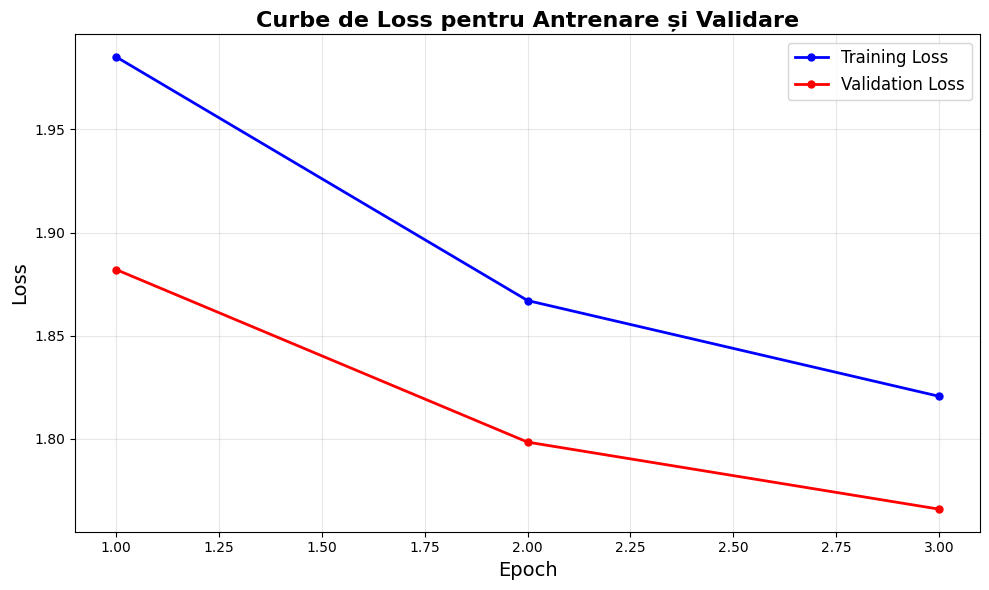

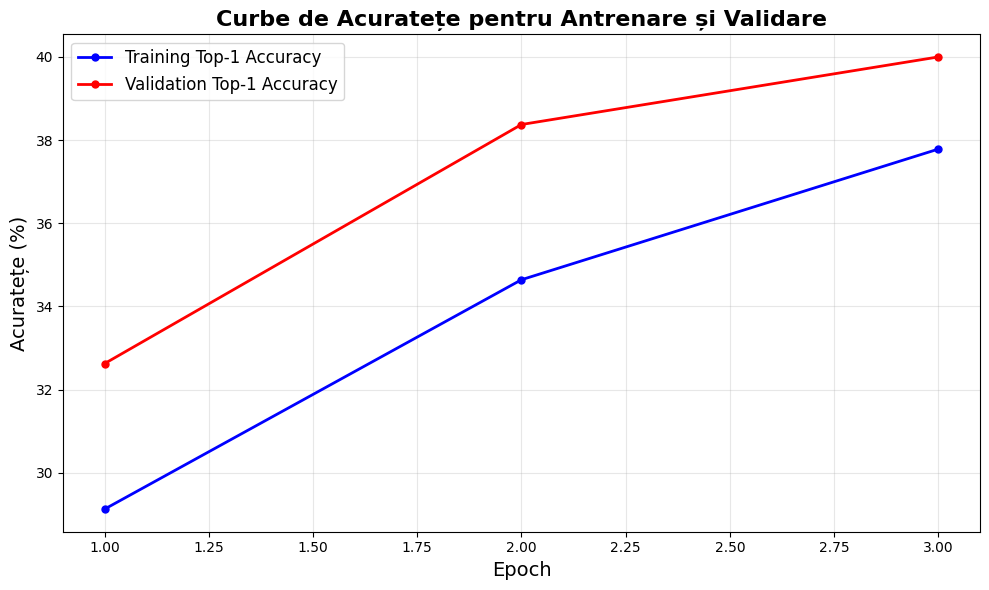

100%|██████████| 375/375 [00:15<00:00, 24.22it/s, epoch=4, train_loss=1.7888, top1_accuracy=39.84%]
Train - Loss: 1.7888, Top-1: 39.84%
100%|██████████| 50/50 [00:01<00:00, 39.32it/s, epoch=4, val_loss=1.7516, top1_accuracy=40.19%]
Val - Loss: 1.7516, Val - Top-1: 40.19%
Validation accuracy increased (40.000000 → 40.187500). Saving model...
100%|██████████| 375/375 [00:16<00:00, 22.24it/s, epoch=5, train_loss=1.7555, top1_accuracy=41.51%]
Train - Loss: 1.7555, Top-1: 41.51%
100%|██████████| 50/50 [00:01<00:00, 39.75it/s, epoch=5, val_loss=1.7088, top1_accuracy=42.38%]
Val - Loss: 1.7088, Val - Top-1: 42.38%
Validation accuracy increased (40.187500 → 42.375000). Saving model...
100%|██████████| 375/375 [00:15<00:00, 23.79it/s, epoch=6, train_loss=1.7301, top1_accuracy=43.23%]
Train - Loss: 1.7301, Top-1: 43.23%
100%|██████████| 50/50 [00:01<00:00, 42.28it/s, epoch=6, val_loss=1.7038, top1_accuracy=43.19%]
Val - Loss: 1.7038, Val - Top-1: 43.19%
Validation accuracy increased (42.375000 →

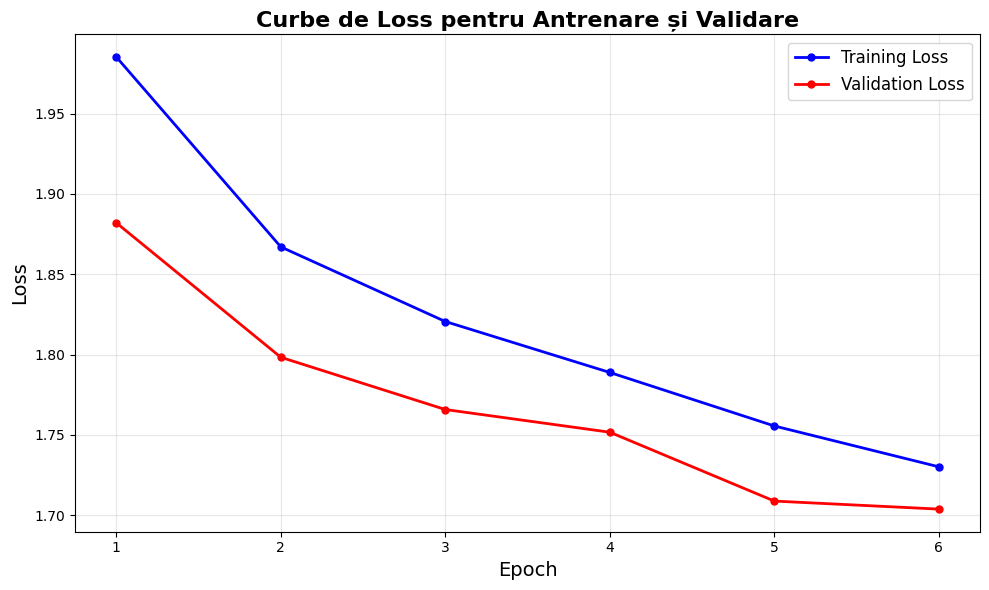

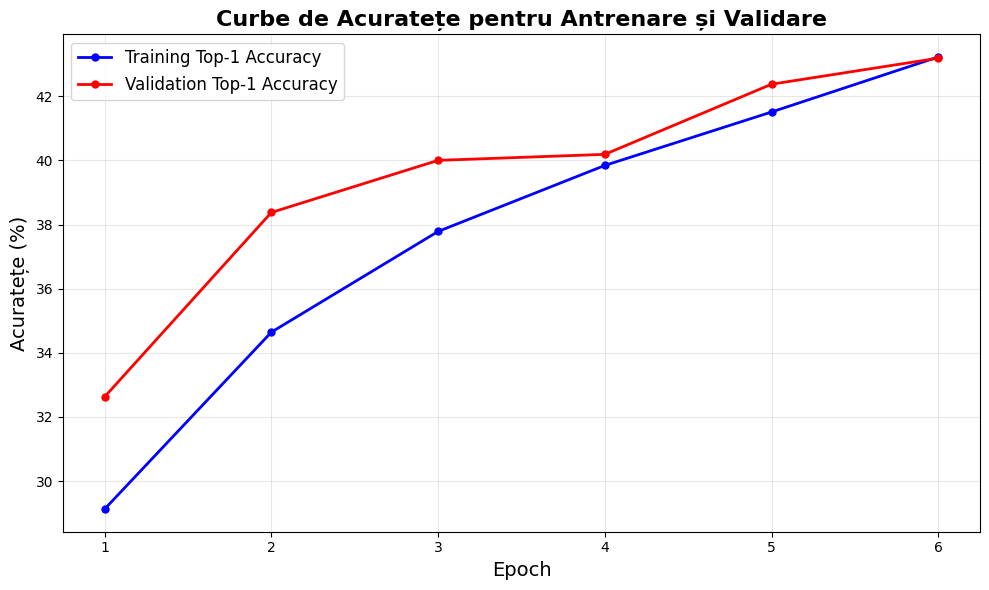

100%|██████████| 375/375 [00:15<00:00, 24.04it/s, epoch=7, train_loss=1.7125, top1_accuracy=43.26%]
Train - Loss: 1.7125, Top-1: 43.26%
100%|██████████| 50/50 [00:01<00:00, 47.63it/s, epoch=7, val_loss=1.6793, top1_accuracy=44.19%]
Val - Loss: 1.6793, Val - Top-1: 44.19%
Validation accuracy increased (43.187500 → 44.187500). Saving model...
100%|██████████| 375/375 [00:18<00:00, 20.55it/s, epoch=8, train_loss=1.6948, top1_accuracy=44.50%]
Train - Loss: 1.6948, Top-1: 44.50%
100%|██████████| 50/50 [00:01<00:00, 34.41it/s, epoch=8, val_loss=1.6488, top1_accuracy=45.50%]
Val - Loss: 1.6488, Val - Top-1: 45.50%
Validation accuracy increased (44.187500 → 45.500000). Saving model...
100%|██████████| 375/375 [00:22<00:00, 16.55it/s, epoch=9, train_loss=1.6669, top1_accuracy=46.06%]
Train - Loss: 1.6669, Top-1: 46.06%
100%|██████████| 50/50 [00:01<00:00, 33.75it/s, epoch=9, val_loss=1.6521, top1_accuracy=46.12%]
Val - Loss: 1.6521, Val - Top-1: 46.12%
Validation accuracy increased (45.500000 →

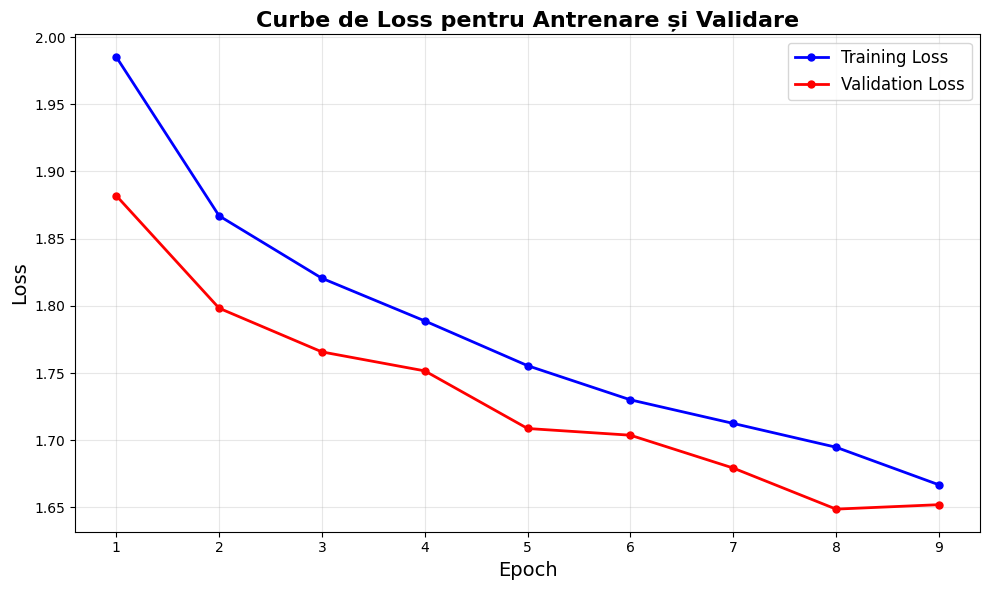

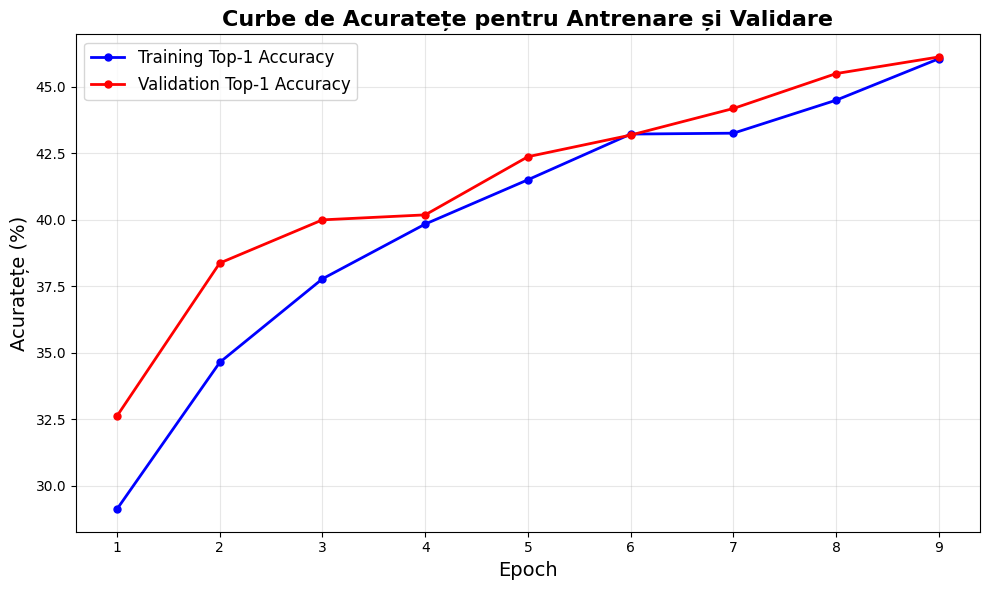

100%|██████████| 375/375 [00:18<00:00, 19.81it/s, epoch=10, train_loss=1.6561, top1_accuracy=46.11%]
Train - Loss: 1.6561, Top-1: 46.11%
100%|██████████| 50/50 [00:01<00:00, 41.42it/s, epoch=10, val_loss=1.6421, top1_accuracy=46.69%]
Val - Loss: 1.6421, Val - Top-1: 46.69%
Validation accuracy increased (46.125000 → 46.687500). Saving model...
100%|██████████| 375/375 [00:17<00:00, 21.07it/s, epoch=11, train_loss=1.6472, top1_accuracy=47.10%]
Train - Loss: 1.6472, Top-1: 47.10%
100%|██████████| 50/50 [00:01<00:00, 42.83it/s, epoch=11, val_loss=1.6284, top1_accuracy=47.75%]
Val - Loss: 1.6284, Val - Top-1: 47.75%
Validation accuracy increased (46.687500 → 47.750000). Saving model...
100%|██████████| 375/375 [00:18<00:00, 20.53it/s, epoch=12, train_loss=1.6252, top1_accuracy=47.88%]
Train - Loss: 1.6252, Top-1: 47.88%
100%|██████████| 50/50 [00:01<00:00, 30.97it/s, epoch=12, val_loss=1.6178, top1_accuracy=47.75%]
Val - Loss: 1.6178, Val - Top-1: 47.75%
EarlyStopping counter: 1 out of 7


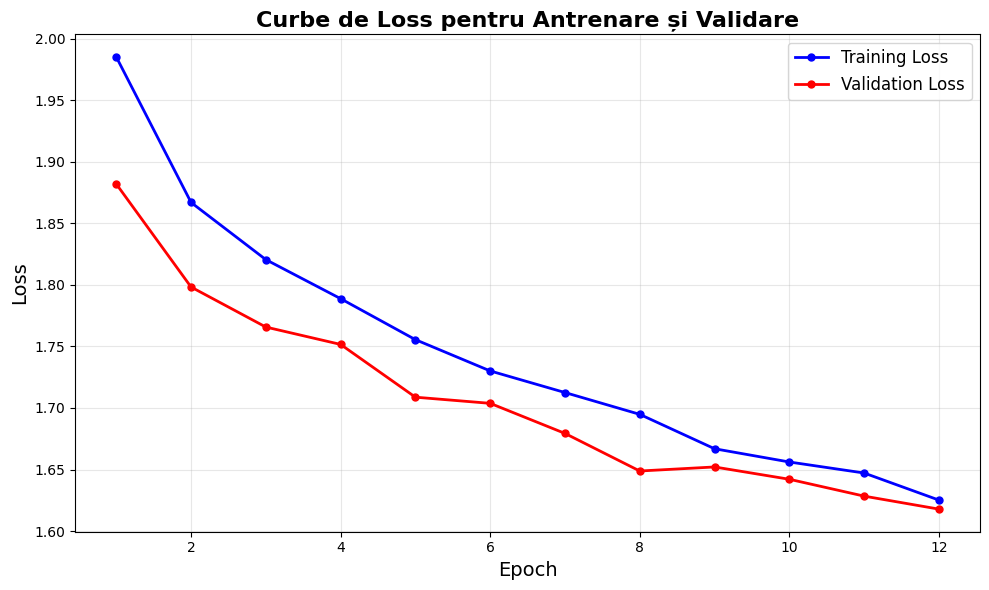

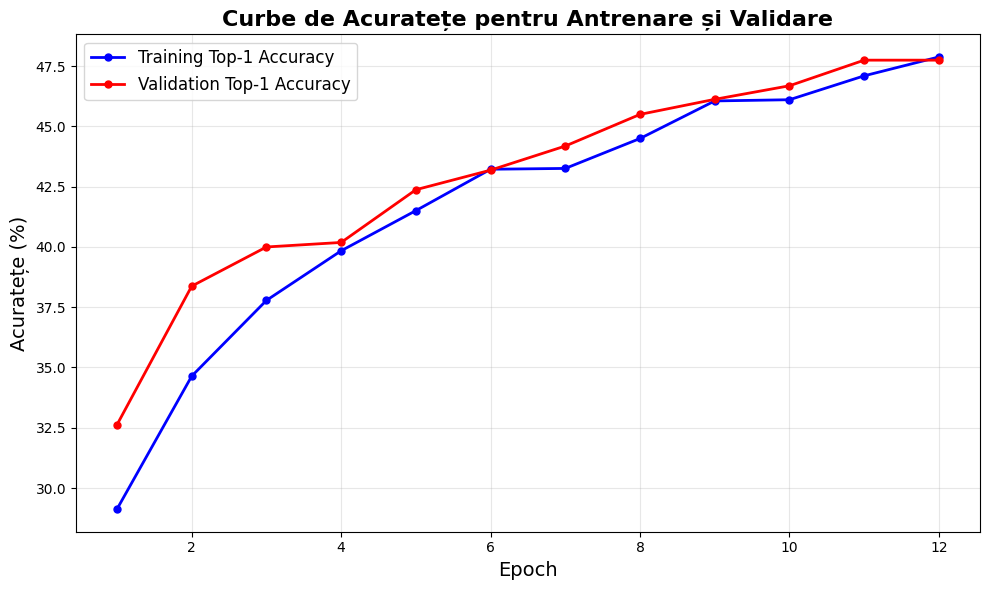

100%|██████████| 375/375 [00:16<00:00, 22.53it/s, epoch=13, train_loss=1.6218, top1_accuracy=48.37%]
Train - Loss: 1.6218, Top-1: 48.37%
100%|██████████| 50/50 [00:01<00:00, 44.94it/s, epoch=13, val_loss=1.6241, top1_accuracy=48.00%]
Val - Loss: 1.6241, Val - Top-1: 48.00%
Validation accuracy increased (47.750000 → 48.000000). Saving model...
100%|██████████| 375/375 [00:16<00:00, 22.78it/s, epoch=14, train_loss=1.6029, top1_accuracy=49.81%]
Train - Loss: 1.6029, Top-1: 49.81%
100%|██████████| 50/50 [00:01<00:00, 44.53it/s, epoch=14, val_loss=1.6070, top1_accuracy=48.44%]
Val - Loss: 1.6070, Val - Top-1: 48.44%
Validation accuracy increased (48.000000 → 48.437500). Saving model...
100%|██████████| 375/375 [00:16<00:00, 23.35it/s, epoch=15, train_loss=1.5993, top1_accuracy=48.78%]
Train - Loss: 1.5993, Top-1: 48.78%
100%|██████████| 50/50 [00:01<00:00, 44.39it/s, epoch=15, val_loss=1.6179, top1_accuracy=47.12%]
Val - Loss: 1.6179, Val - Top-1: 47.12%
EarlyStopping counter: 1 out of 7


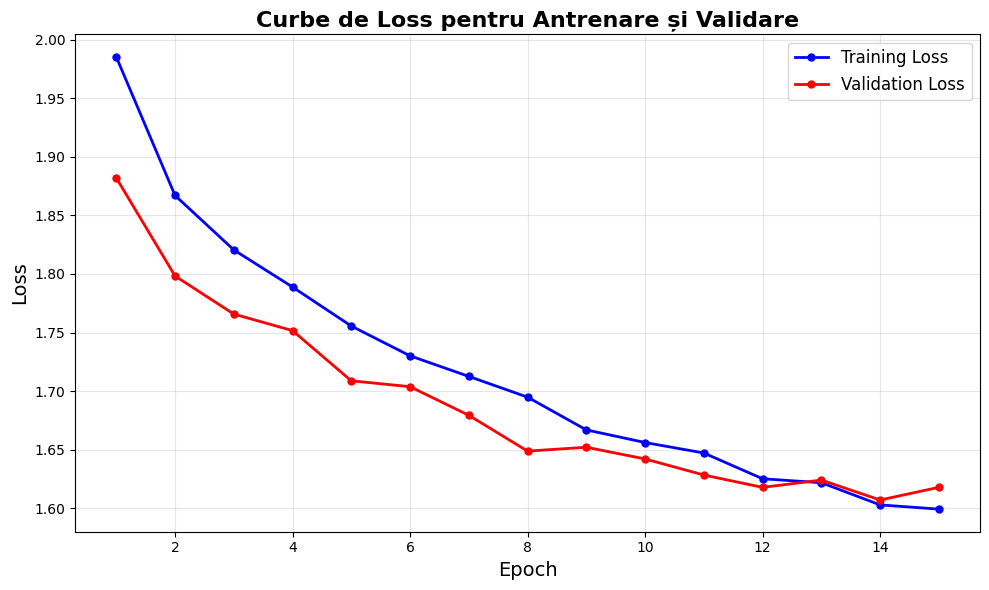

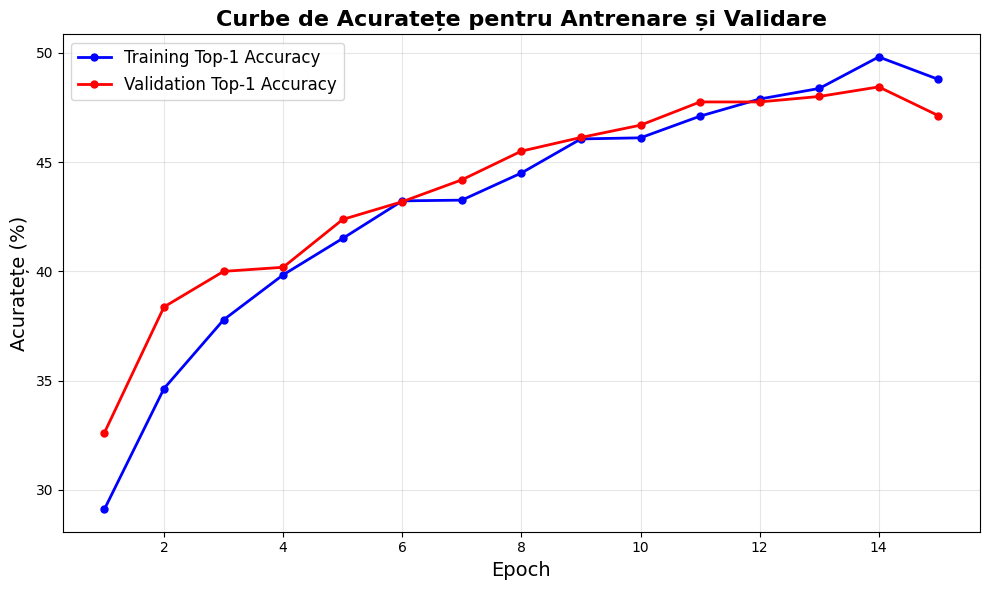

100%|██████████| 375/375 [00:15<00:00, 23.63it/s, epoch=16, train_loss=1.5830, top1_accuracy=50.48%]
Train - Loss: 1.5830, Top-1: 50.48%
100%|██████████| 50/50 [00:01<00:00, 36.51it/s, epoch=16, val_loss=1.6021, top1_accuracy=48.62%]
Val - Loss: 1.6021, Val - Top-1: 48.62%
Validation accuracy increased (48.437500 → 48.625000). Saving model...
100%|██████████| 375/375 [00:17<00:00, 21.31it/s, epoch=17, train_loss=1.5813, top1_accuracy=50.15%]
Train - Loss: 1.5813, Top-1: 50.15%
100%|██████████| 50/50 [00:01<00:00, 40.89it/s, epoch=17, val_loss=1.6025, top1_accuracy=48.69%]
Val - Loss: 1.6025, Val - Top-1: 48.69%
Validation accuracy increased (48.625000 → 48.687500). Saving model...
100%|██████████| 375/375 [00:17<00:00, 21.74it/s, epoch=18, train_loss=1.5638, top1_accuracy=50.83%]
Train - Loss: 1.5638, Top-1: 50.83%
100%|██████████| 50/50 [00:01<00:00, 40.04it/s, epoch=18, val_loss=1.5925, top1_accuracy=49.56%]
Val - Loss: 1.5925, Val - Top-1: 49.56%
Validation accuracy increased (48.68

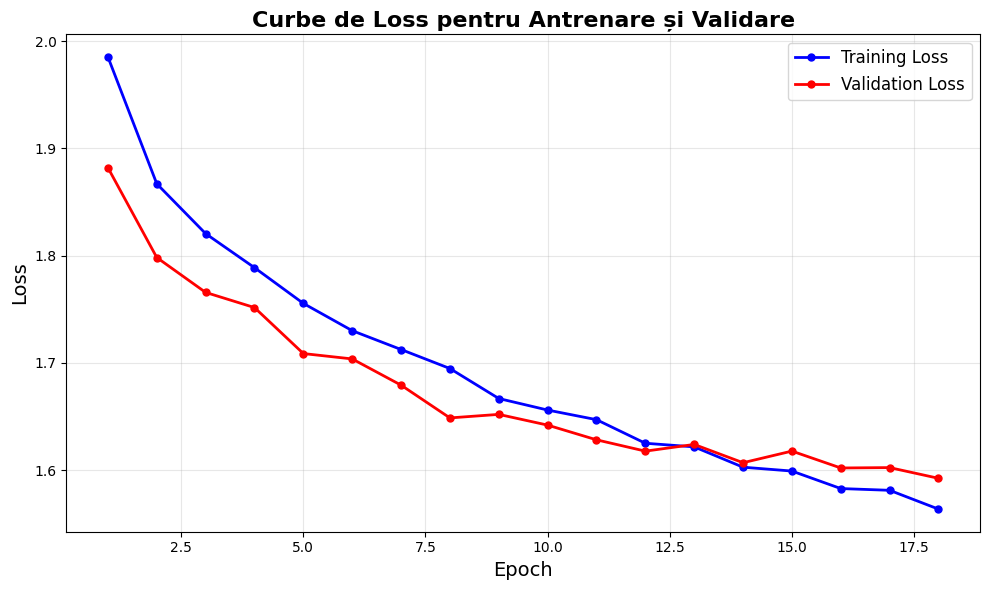

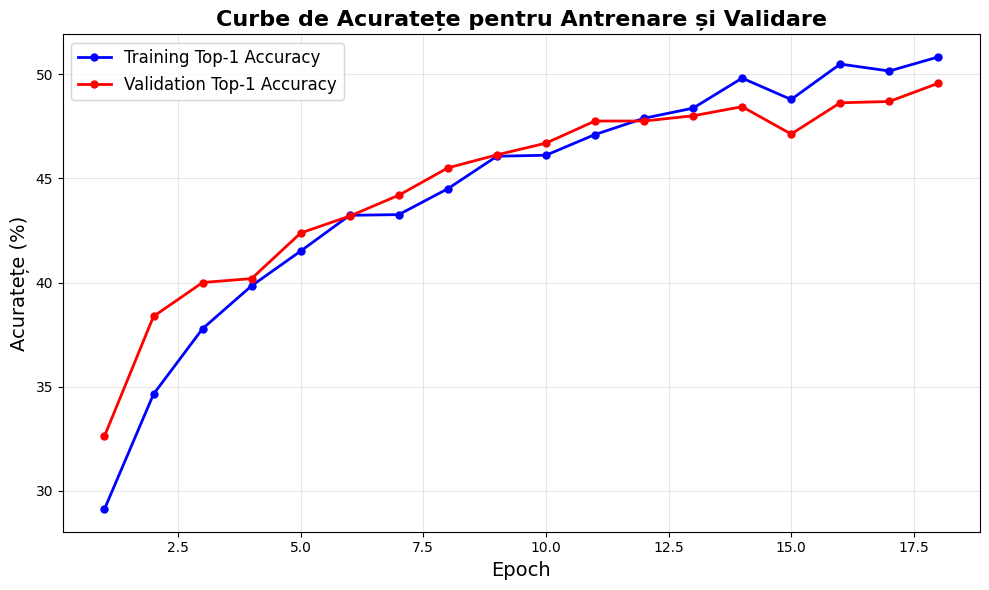

100%|██████████| 375/375 [00:17<00:00, 20.89it/s, epoch=19, train_loss=1.5497, top1_accuracy=51.17%]
Train - Loss: 1.5497, Top-1: 51.17%
100%|██████████| 50/50 [00:01<00:00, 40.05it/s, epoch=19, val_loss=1.5952, top1_accuracy=49.50%]
Val - Loss: 1.5952, Val - Top-1: 49.50%
EarlyStopping counter: 1 out of 7
100%|██████████| 375/375 [00:15<00:00, 24.39it/s, epoch=20, train_loss=1.5545, top1_accuracy=51.88%]
Train - Loss: 1.5545, Top-1: 51.88%
100%|██████████| 50/50 [00:00<00:00, 58.57it/s, epoch=20, val_loss=1.5933, top1_accuracy=49.38%]
Val - Loss: 1.5933, Val - Top-1: 49.38%
EarlyStopping counter: 2 out of 7
100%|██████████| 375/375 [00:15<00:00, 24.93it/s, epoch=21, train_loss=1.5422, top1_accuracy=52.38%]
Train - Loss: 1.5422, Top-1: 52.38%
100%|██████████| 50/50 [00:00<00:00, 55.38it/s, epoch=21, val_loss=1.5825, top1_accuracy=50.25%]
Val - Loss: 1.5825, Val - Top-1: 50.25%
Validation accuracy increased (49.562500 → 50.250000). Saving model...


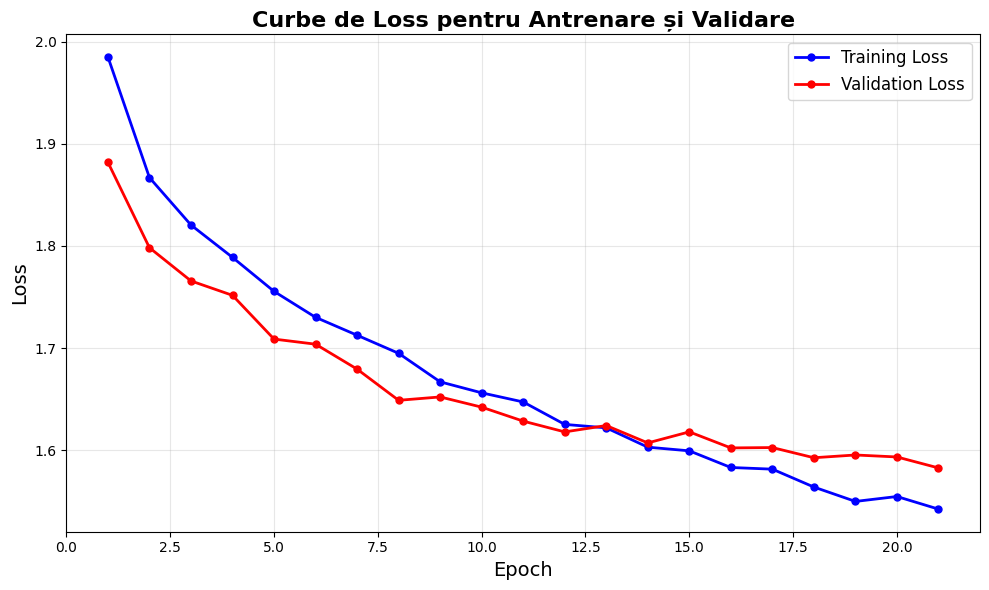

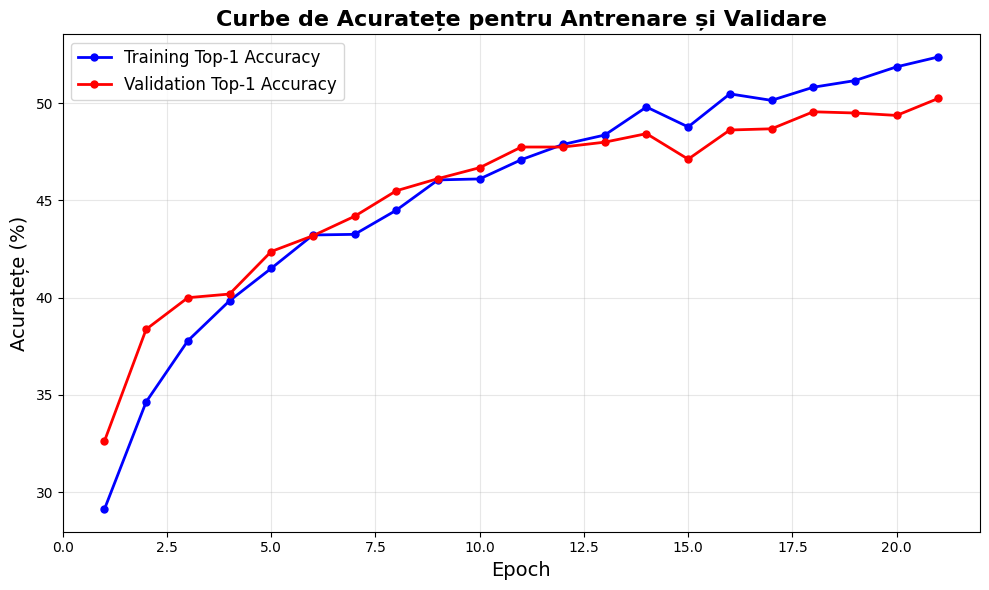

100%|██████████| 375/375 [00:16<00:00, 23.33it/s, epoch=22, train_loss=1.5386, top1_accuracy=52.11%]
Train - Loss: 1.5386, Top-1: 52.11%
100%|██████████| 50/50 [00:00<00:00, 60.33it/s, epoch=22, val_loss=1.5817, top1_accuracy=50.56%]
Val - Loss: 1.5817, Val - Top-1: 50.56%
Validation accuracy increased (50.250000 → 50.562500). Saving model...
100%|██████████| 375/375 [00:16<00:00, 23.29it/s, epoch=23, train_loss=1.5341, top1_accuracy=52.73%]
Train - Loss: 1.5341, Top-1: 52.73%
100%|██████████| 50/50 [00:00<00:00, 58.65it/s, epoch=23, val_loss=1.5792, top1_accuracy=50.06%]
Val - Loss: 1.5792, Val - Top-1: 50.06%
EarlyStopping counter: 1 out of 7
100%|██████████| 375/375 [00:15<00:00, 23.56it/s, epoch=24, train_loss=1.5218, top1_accuracy=53.35%]
Train - Loss: 1.5218, Top-1: 53.35%
100%|██████████| 50/50 [00:00<00:00, 53.28it/s, epoch=24, val_loss=1.5717, top1_accuracy=50.81%]
Val - Loss: 1.5717, Val - Top-1: 50.81%
Validation accuracy increased (50.562500 → 50.812500). Saving model...


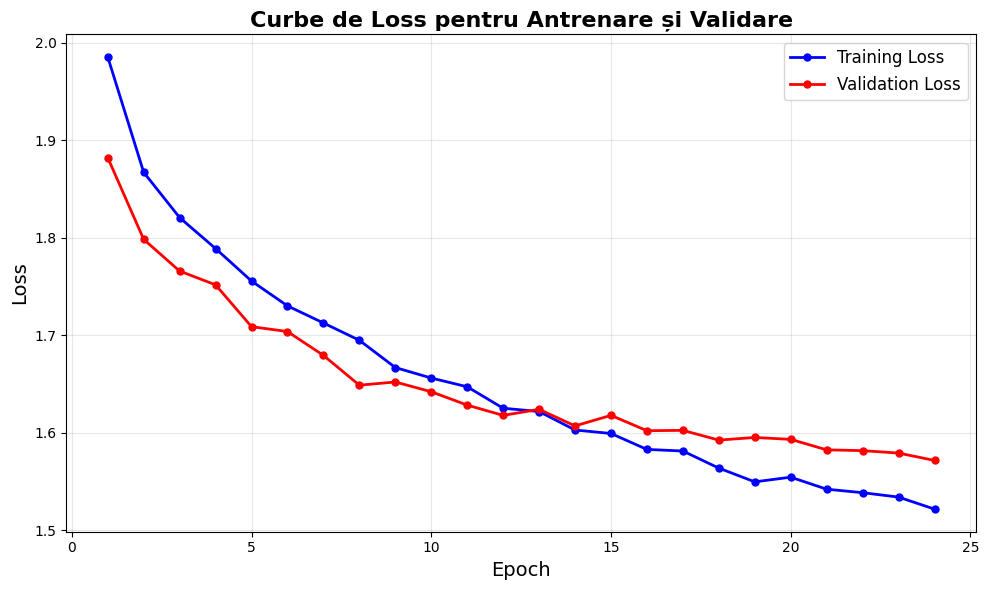

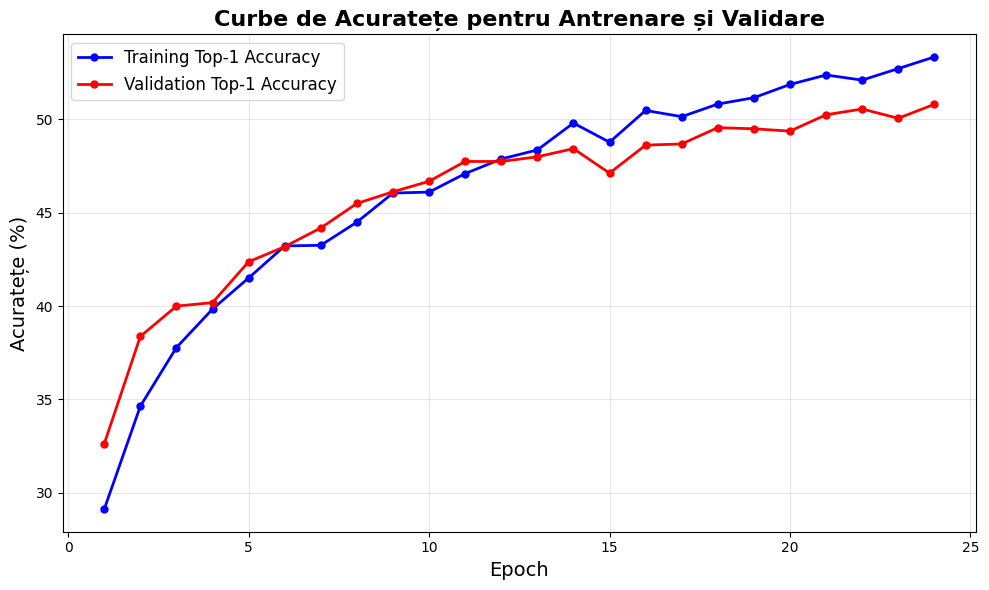

100%|██████████| 375/375 [00:16<00:00, 23.36it/s, epoch=25, train_loss=1.5239, top1_accuracy=53.44%]
Train - Loss: 1.5239, Top-1: 53.44%
100%|██████████| 50/50 [00:00<00:00, 57.72it/s, epoch=25, val_loss=1.5780, top1_accuracy=50.56%]
Val - Loss: 1.5780, Val - Top-1: 50.56%
EarlyStopping counter: 1 out of 7
100%|██████████| 375/375 [00:15<00:00, 24.05it/s, epoch=26, train_loss=1.5140, top1_accuracy=53.58%]
Train - Loss: 1.5140, Top-1: 53.58%
100%|██████████| 50/50 [00:00<00:00, 55.47it/s, epoch=26, val_loss=1.5743, top1_accuracy=51.19%]
Val - Loss: 1.5743, Val - Top-1: 51.19%
Validation accuracy increased (50.812500 → 51.187500). Saving model...
100%|██████████| 375/375 [00:15<00:00, 23.66it/s, epoch=27, train_loss=1.5104, top1_accuracy=53.92%]
Train - Loss: 1.5104, Top-1: 53.92%
100%|██████████| 50/50 [00:00<00:00, 54.48it/s, epoch=27, val_loss=1.5705, top1_accuracy=50.56%]
Val - Loss: 1.5705, Val - Top-1: 50.56%
EarlyStopping counter: 1 out of 7


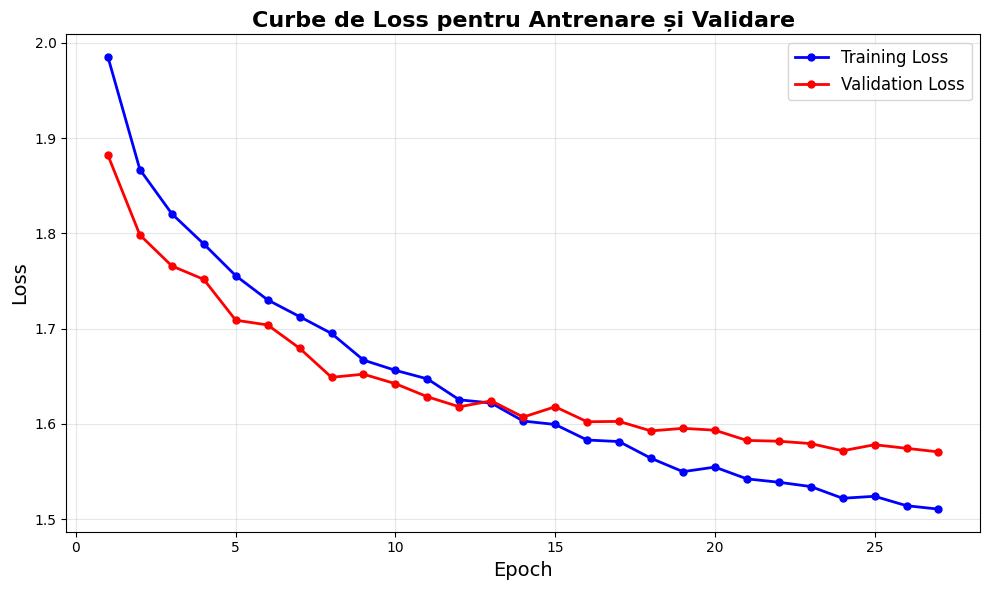

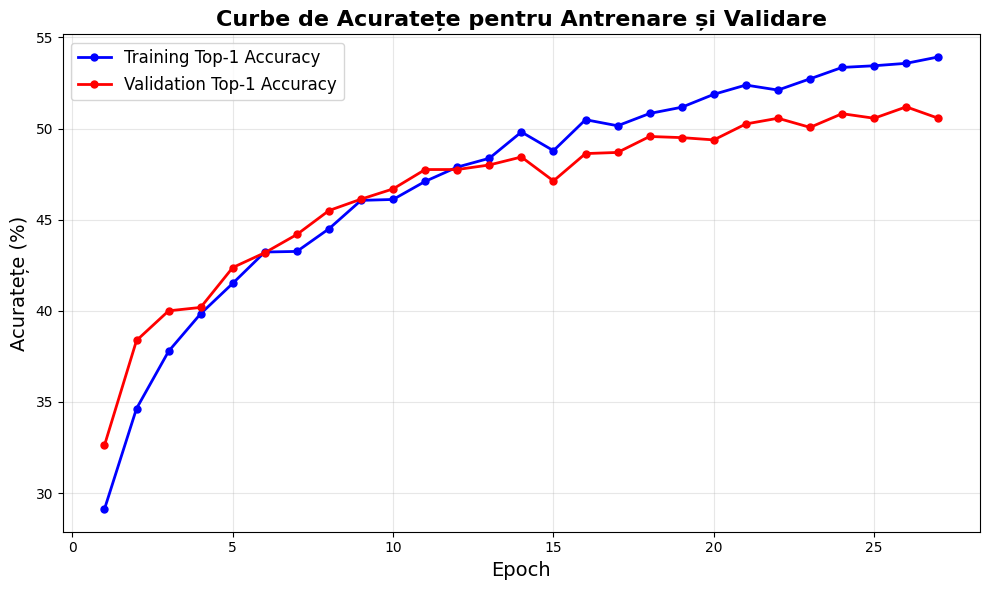

100%|██████████| 375/375 [00:15<00:00, 23.86it/s, epoch=28, train_loss=1.4983, top1_accuracy=54.66%]
Train - Loss: 1.4983, Top-1: 54.66%
100%|██████████| 50/50 [00:00<00:00, 53.99it/s, epoch=28, val_loss=1.5744, top1_accuracy=50.31%]
Val - Loss: 1.5744, Val - Top-1: 50.31%
EarlyStopping counter: 2 out of 7
100%|██████████| 375/375 [00:15<00:00, 23.98it/s, epoch=29, train_loss=1.5009, top1_accuracy=54.18%]
Train - Loss: 1.5009, Top-1: 54.18%
100%|██████████| 50/50 [00:00<00:00, 54.83it/s, epoch=29, val_loss=1.5731, top1_accuracy=50.44%]
Val - Loss: 1.5731, Val - Top-1: 50.44%
EarlyStopping counter: 3 out of 7
100%|██████████| 375/375 [00:15<00:00, 23.47it/s, epoch=30, train_loss=1.5064, top1_accuracy=54.02%]
Train - Loss: 1.5064, Top-1: 54.02%
100%|██████████| 50/50 [00:01<00:00, 49.81it/s, epoch=30, val_loss=1.5707, top1_accuracy=51.12%]
Val - Loss: 1.5707, Val - Top-1: 51.12%
EarlyStopping counter: 4 out of 7


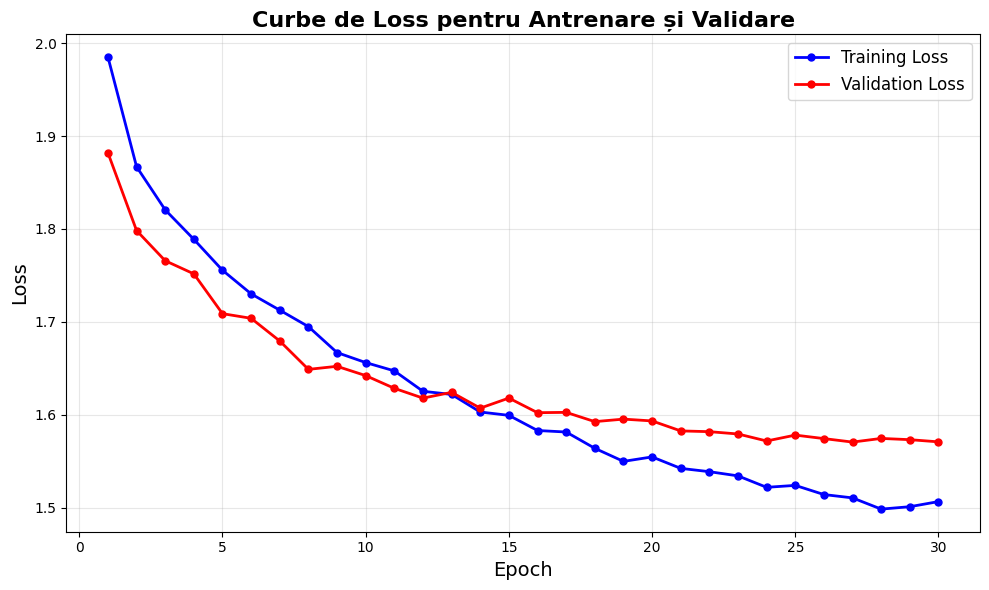

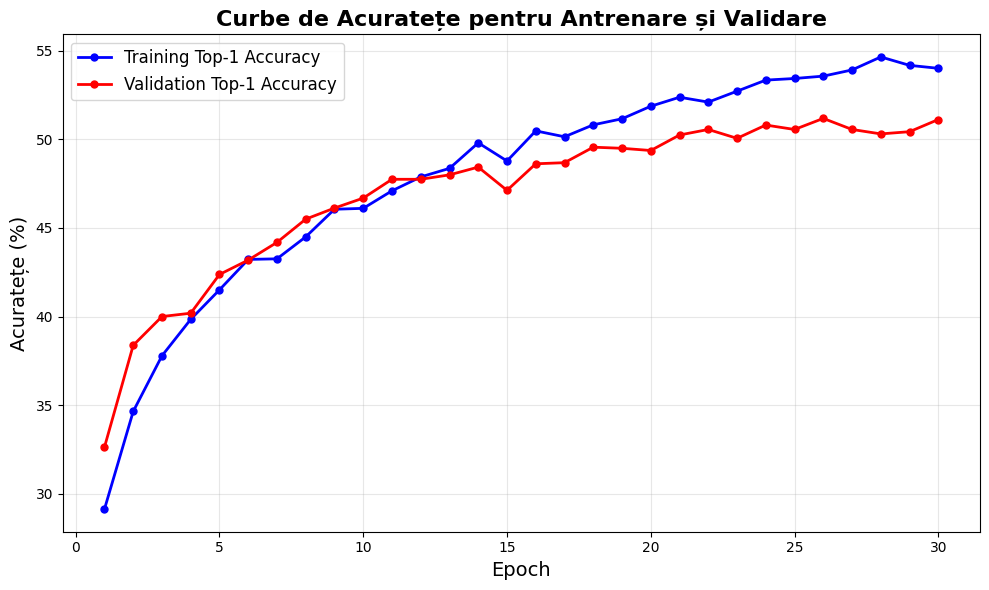

100%|██████████| 375/375 [00:15<00:00, 23.50it/s, epoch=31, train_loss=1.4951, top1_accuracy=54.38%]
Train - Loss: 1.4951, Top-1: 54.38%
100%|██████████| 50/50 [00:00<00:00, 50.25it/s, epoch=31, val_loss=1.5657, top1_accuracy=50.19%]
Val - Loss: 1.5657, Val - Top-1: 50.19%
EarlyStopping counter: 5 out of 7
100%|██████████| 375/375 [00:15<00:00, 23.69it/s, epoch=32, train_loss=1.4862, top1_accuracy=55.23%]
Train - Loss: 1.4862, Top-1: 55.23%
100%|██████████| 50/50 [00:01<00:00, 49.80it/s, epoch=32, val_loss=1.5722, top1_accuracy=50.25%]
Val - Loss: 1.5722, Val - Top-1: 50.25%
EarlyStopping counter: 6 out of 7
100%|██████████| 375/375 [00:15<00:00, 23.63it/s, epoch=33, train_loss=1.4912, top1_accuracy=54.56%]
Train - Loss: 1.4912, Top-1: 54.56%
100%|██████████| 50/50 [00:01<00:00, 40.65it/s, epoch=33, val_loss=1.5704, top1_accuracy=50.56%]
Val - Loss: 1.5704, Val - Top-1: 50.56%
EarlyStopping counter: 7 out of 7
Early stopping triggered at epoch 33

Model 1 Best Validation Accuracy: 51.1

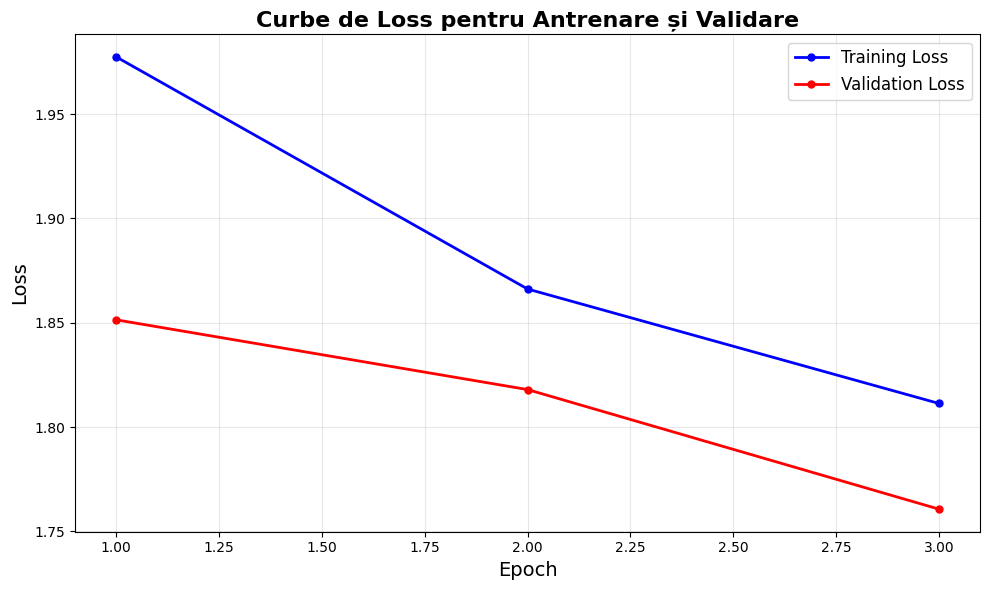

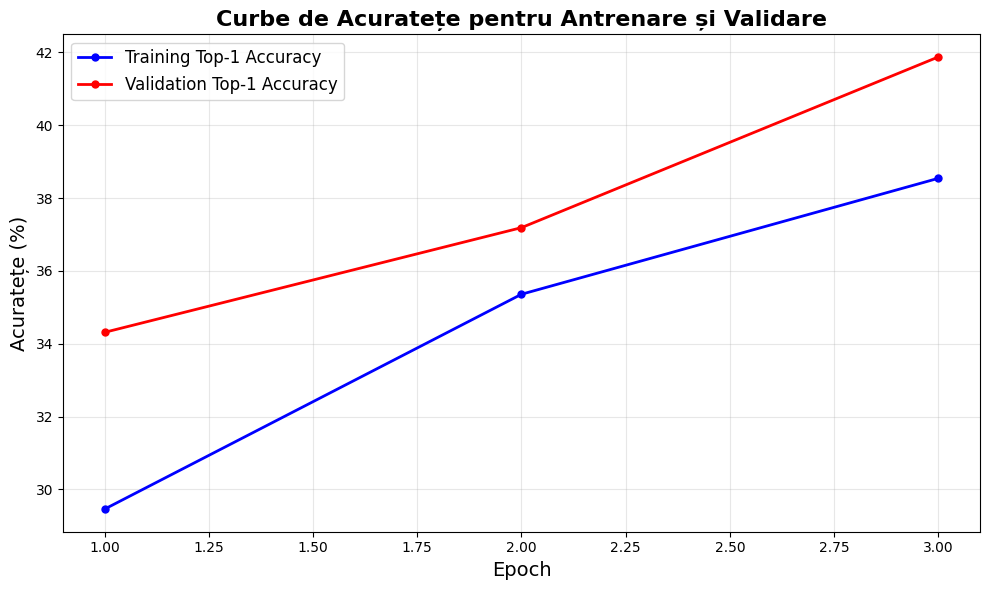

100%|██████████| 375/375 [00:16<00:00, 23.19it/s, epoch=4, train_loss=1.7862, top1_accuracy=39.73%]
Train - Loss: 1.7862, Top-1: 39.73%
100%|██████████| 50/50 [00:00<00:00, 58.80it/s, epoch=4, val_loss=1.7458, top1_accuracy=40.75%]
Val - Loss: 1.7458, Val - Top-1: 40.75%
EarlyStopping counter: 1 out of 7
100%|██████████| 375/375 [00:14<00:00, 25.07it/s, epoch=5, train_loss=1.7588, top1_accuracy=40.95%]
Train - Loss: 1.7588, Top-1: 40.95%
100%|██████████| 50/50 [00:00<00:00, 56.29it/s, epoch=5, val_loss=1.7172, top1_accuracy=42.12%]
Val - Loss: 1.7172, Val - Top-1: 42.12%
Validation accuracy increased (41.875000 → 42.125000). Saving model...
100%|██████████| 375/375 [00:14<00:00, 25.23it/s, epoch=6, train_loss=1.7286, top1_accuracy=42.53%]
Train - Loss: 1.7286, Top-1: 42.53%
100%|██████████| 50/50 [00:00<00:00, 57.91it/s, epoch=6, val_loss=1.6860, top1_accuracy=43.31%]
Val - Loss: 1.6860, Val - Top-1: 43.31%
Validation accuracy increased (42.125000 → 43.312500). Saving model...


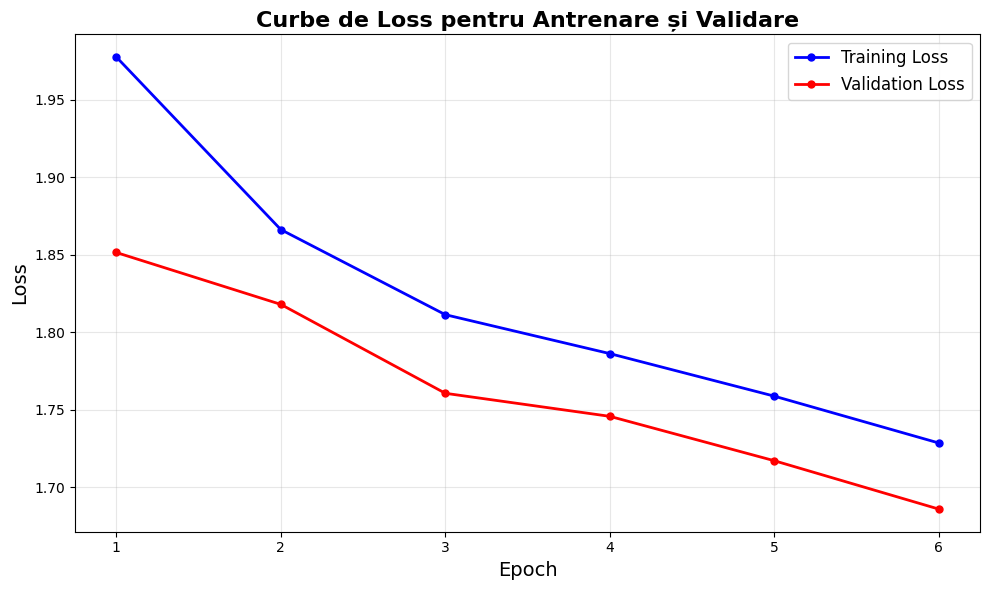

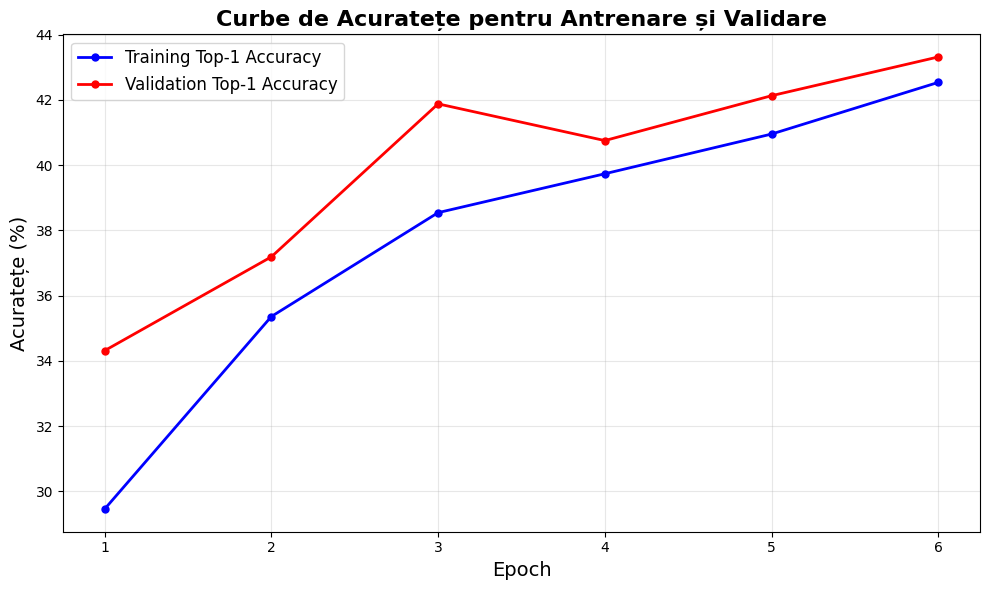

100%|██████████| 375/375 [00:16<00:00, 23.08it/s, epoch=7, train_loss=1.7100, top1_accuracy=43.89%]
Train - Loss: 1.7100, Top-1: 43.89%
100%|██████████| 50/50 [00:01<00:00, 41.77it/s, epoch=7, val_loss=1.6835, top1_accuracy=44.38%]
Val - Loss: 1.6835, Val - Top-1: 44.38%
Validation accuracy increased (43.312500 → 44.375000). Saving model...
100%|██████████| 375/375 [00:17<00:00, 21.40it/s, epoch=8, train_loss=1.6818, top1_accuracy=44.91%]
Train - Loss: 1.6818, Top-1: 44.91%
100%|██████████| 50/50 [00:01<00:00, 41.01it/s, epoch=8, val_loss=1.6634, top1_accuracy=45.44%]
Val - Loss: 1.6634, Val - Top-1: 45.44%
Validation accuracy increased (44.375000 → 45.437500). Saving model...
100%|██████████| 375/375 [00:17<00:00, 21.91it/s, epoch=9, train_loss=1.6720, top1_accuracy=46.23%]
Train - Loss: 1.6720, Top-1: 46.23%
100%|██████████| 50/50 [00:01<00:00, 41.73it/s, epoch=9, val_loss=1.6515, top1_accuracy=45.44%]
Val - Loss: 1.6515, Val - Top-1: 45.44%
EarlyStopping counter: 1 out of 7


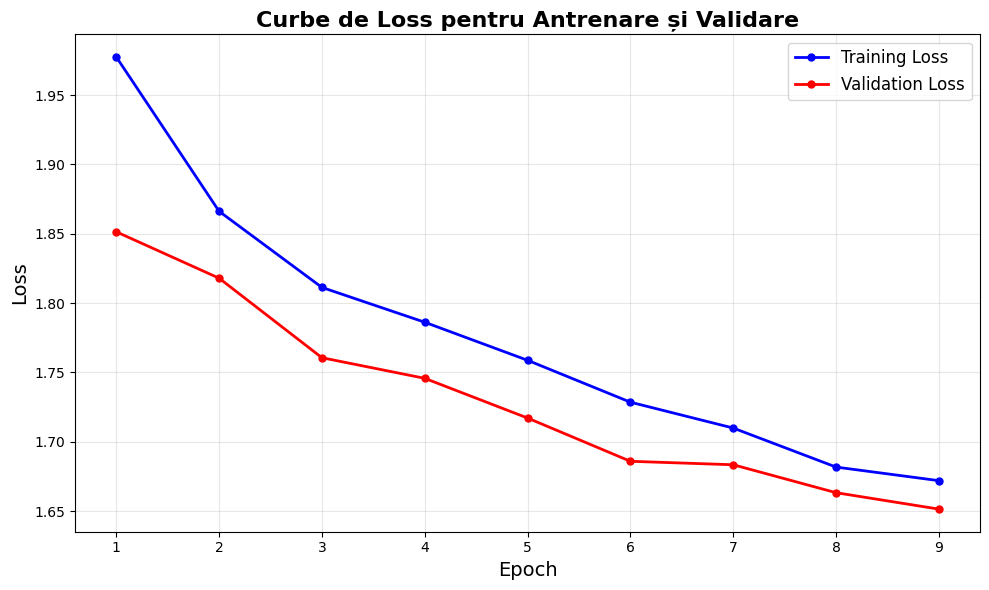

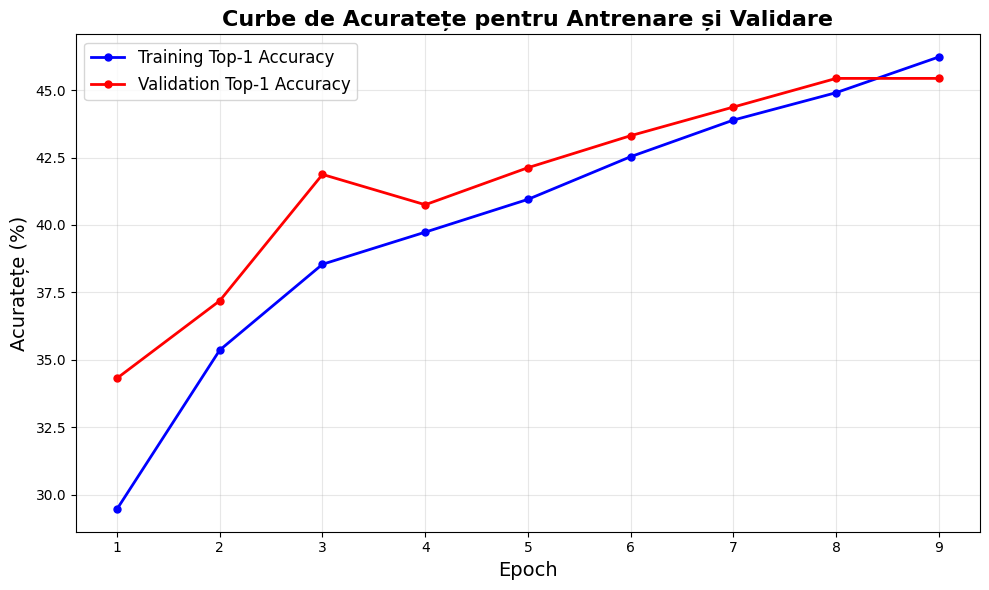

100%|██████████| 375/375 [00:17<00:00, 21.28it/s, epoch=10, train_loss=1.6591, top1_accuracy=46.08%]
Train - Loss: 1.6591, Top-1: 46.08%
100%|██████████| 50/50 [00:01<00:00, 46.26it/s, epoch=10, val_loss=1.6503, top1_accuracy=46.31%]
Val - Loss: 1.6503, Val - Top-1: 46.31%
Validation accuracy increased (45.437500 → 46.312500). Saving model...
100%|██████████| 375/375 [00:16<00:00, 22.63it/s, epoch=11, train_loss=1.6404, top1_accuracy=47.05%]
Train - Loss: 1.6404, Top-1: 47.05%
100%|██████████| 50/50 [00:01<00:00, 37.48it/s, epoch=11, val_loss=1.6441, top1_accuracy=46.25%]
Val - Loss: 1.6441, Val - Top-1: 46.25%
EarlyStopping counter: 1 out of 7
100%|██████████| 375/375 [00:15<00:00, 23.54it/s, epoch=12, train_loss=1.6321, top1_accuracy=47.85%]
Train - Loss: 1.6321, Top-1: 47.85%
100%|██████████| 50/50 [00:00<00:00, 53.87it/s, epoch=12, val_loss=1.6289, top1_accuracy=47.06%]
Val - Loss: 1.6289, Val - Top-1: 47.06%
Validation accuracy increased (46.312500 → 47.062500). Saving model...


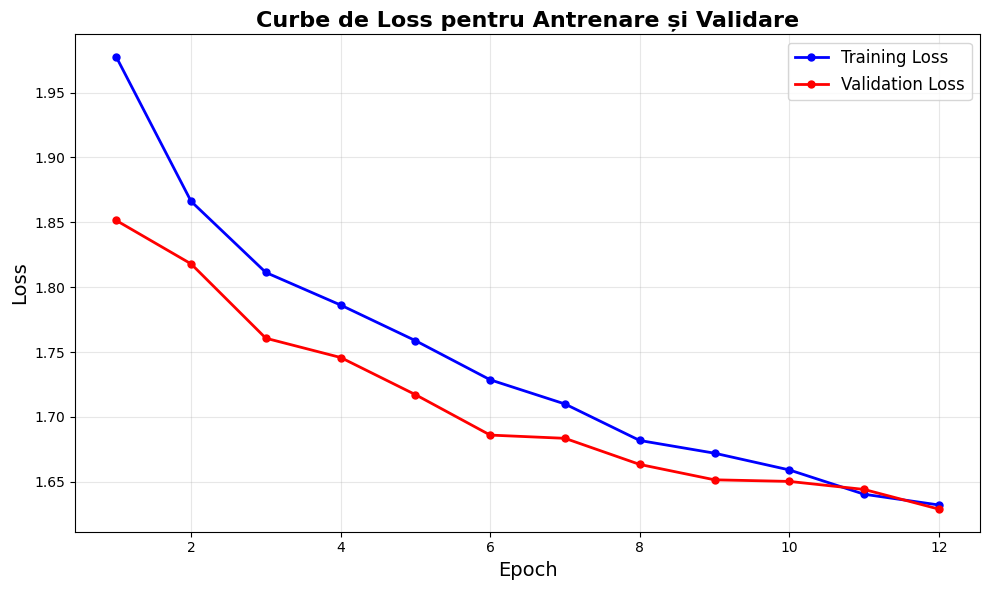

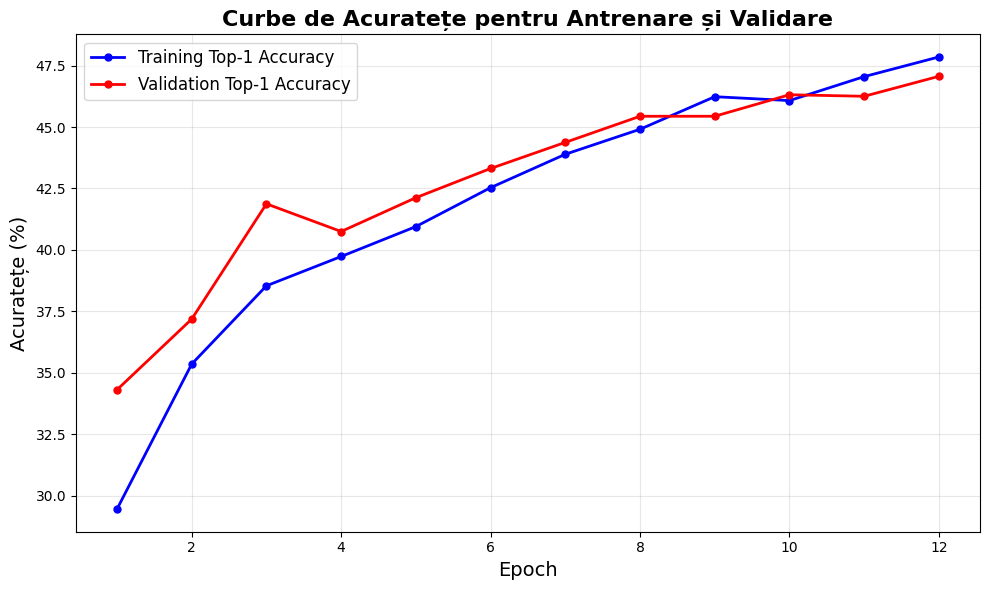

100%|██████████| 375/375 [00:15<00:00, 24.51it/s, epoch=13, train_loss=1.6113, top1_accuracy=49.04%]
Train - Loss: 1.6113, Top-1: 49.04%
100%|██████████| 50/50 [00:00<00:00, 54.55it/s, epoch=13, val_loss=1.6231, top1_accuracy=47.69%]
Val - Loss: 1.6231, Val - Top-1: 47.69%
Validation accuracy increased (47.062500 → 47.687500). Saving model...
100%|██████████| 375/375 [00:15<00:00, 24.41it/s, epoch=14, train_loss=1.6083, top1_accuracy=48.96%]
Train - Loss: 1.6083, Top-1: 48.96%
100%|██████████| 50/50 [00:00<00:00, 55.68it/s, epoch=14, val_loss=1.6180, top1_accuracy=48.38%]
Val - Loss: 1.6180, Val - Top-1: 48.38%
Validation accuracy increased (47.687500 → 48.375000). Saving model...
100%|██████████| 375/375 [00:15<00:00, 24.69it/s, epoch=15, train_loss=1.5990, top1_accuracy=49.26%]
Train - Loss: 1.5990, Top-1: 49.26%
100%|██████████| 50/50 [00:00<00:00, 54.22it/s, epoch=15, val_loss=1.6226, top1_accuracy=47.19%]
Val - Loss: 1.6226, Val - Top-1: 47.19%
EarlyStopping counter: 1 out of 7


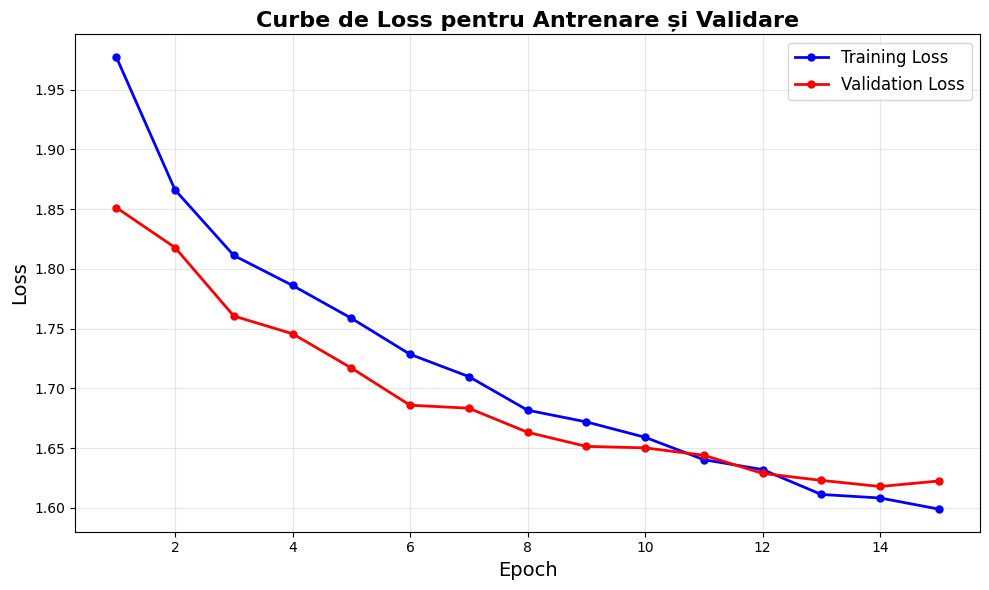

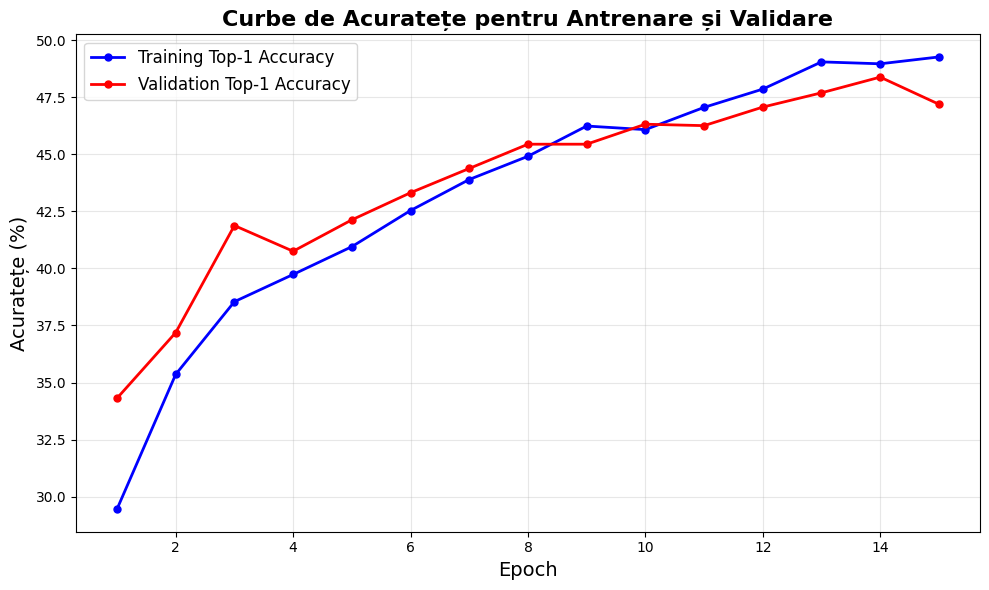

100%|██████████| 375/375 [00:15<00:00, 24.39it/s, epoch=16, train_loss=1.5796, top1_accuracy=50.13%]
Train - Loss: 1.5796, Top-1: 50.13%
100%|██████████| 50/50 [00:00<00:00, 56.16it/s, epoch=16, val_loss=1.6084, top1_accuracy=48.38%]
Val - Loss: 1.6084, Val - Top-1: 48.38%
EarlyStopping counter: 2 out of 7
100%|██████████| 375/375 [00:15<00:00, 24.99it/s, epoch=17, train_loss=1.5725, top1_accuracy=50.83%]
Train - Loss: 1.5725, Top-1: 50.83%
100%|██████████| 50/50 [00:01<00:00, 48.14it/s, epoch=17, val_loss=1.6210, top1_accuracy=47.50%]
Val - Loss: 1.6210, Val - Top-1: 47.50%
EarlyStopping counter: 3 out of 7
100%|██████████| 375/375 [00:14<00:00, 25.64it/s, epoch=18, train_loss=1.5636, top1_accuracy=51.26%]
Train - Loss: 1.5636, Top-1: 51.26%
100%|██████████| 50/50 [00:00<00:00, 55.77it/s, epoch=18, val_loss=1.6131, top1_accuracy=48.50%]
Val - Loss: 1.6131, Val - Top-1: 48.50%
Validation accuracy increased (48.375000 → 48.500000). Saving model...


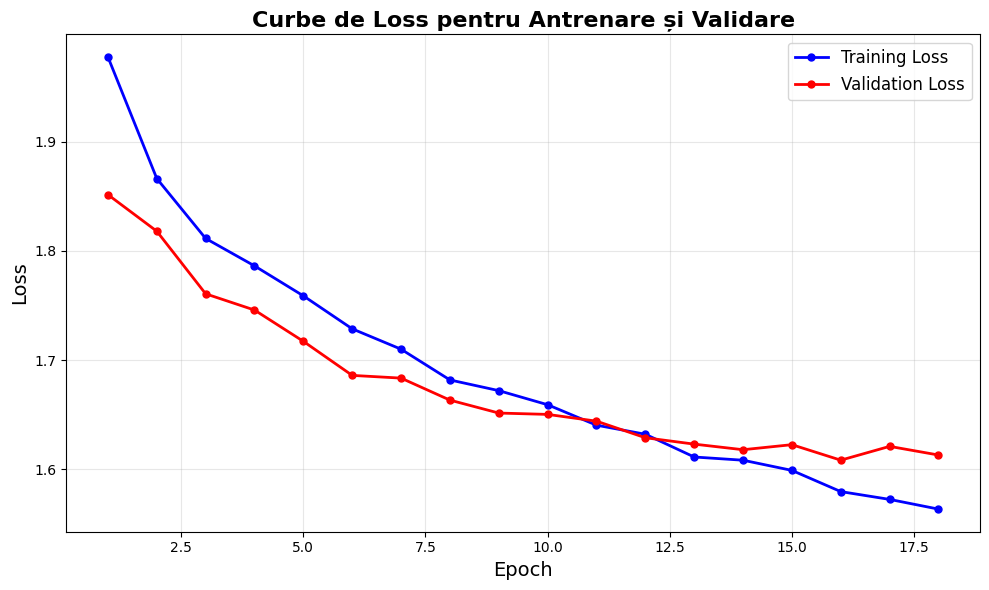

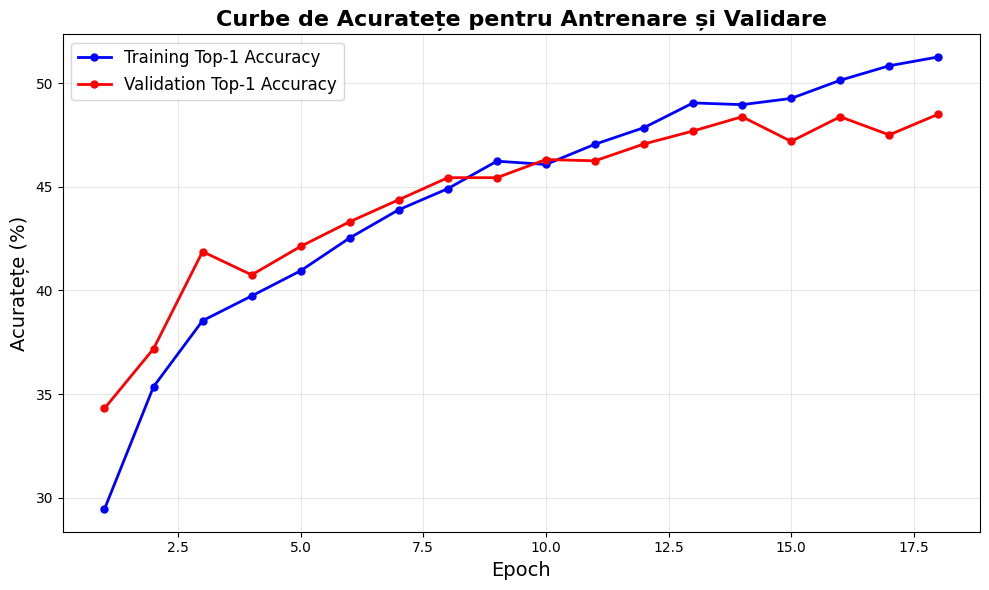

100%|██████████| 375/375 [00:15<00:00, 23.44it/s, epoch=19, train_loss=1.5579, top1_accuracy=51.28%]
Train - Loss: 1.5579, Top-1: 51.28%
100%|██████████| 50/50 [00:01<00:00, 41.08it/s, epoch=19, val_loss=1.6020, top1_accuracy=48.69%]
Val - Loss: 1.6020, Val - Top-1: 48.69%
Validation accuracy increased (48.500000 → 48.687500). Saving model...
100%|██████████| 375/375 [00:15<00:00, 23.60it/s, epoch=20, train_loss=1.5512, top1_accuracy=51.98%]
Train - Loss: 1.5512, Top-1: 51.98%
100%|██████████| 50/50 [00:01<00:00, 49.30it/s, epoch=20, val_loss=1.6054, top1_accuracy=49.88%]
Val - Loss: 1.6054, Val - Top-1: 49.88%
Validation accuracy increased (48.687500 → 49.875000). Saving model...
100%|██████████| 375/375 [00:16<00:00, 22.40it/s, epoch=21, train_loss=1.5428, top1_accuracy=52.50%]
Train - Loss: 1.5428, Top-1: 52.50%
100%|██████████| 50/50 [00:01<00:00, 45.86it/s, epoch=21, val_loss=1.5948, top1_accuracy=50.69%]
Val - Loss: 1.5948, Val - Top-1: 50.69%
Validation accuracy increased (49.87

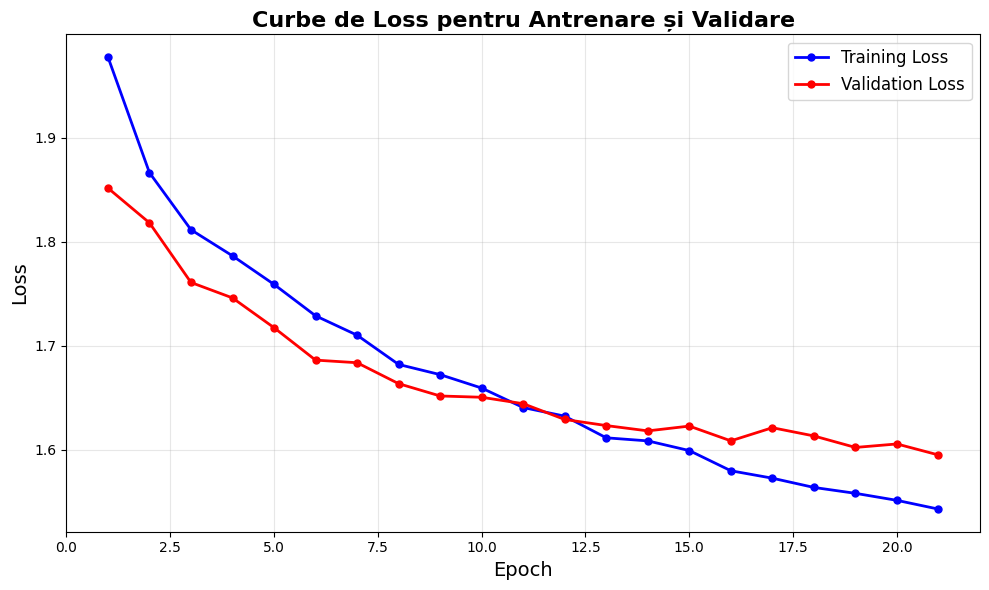

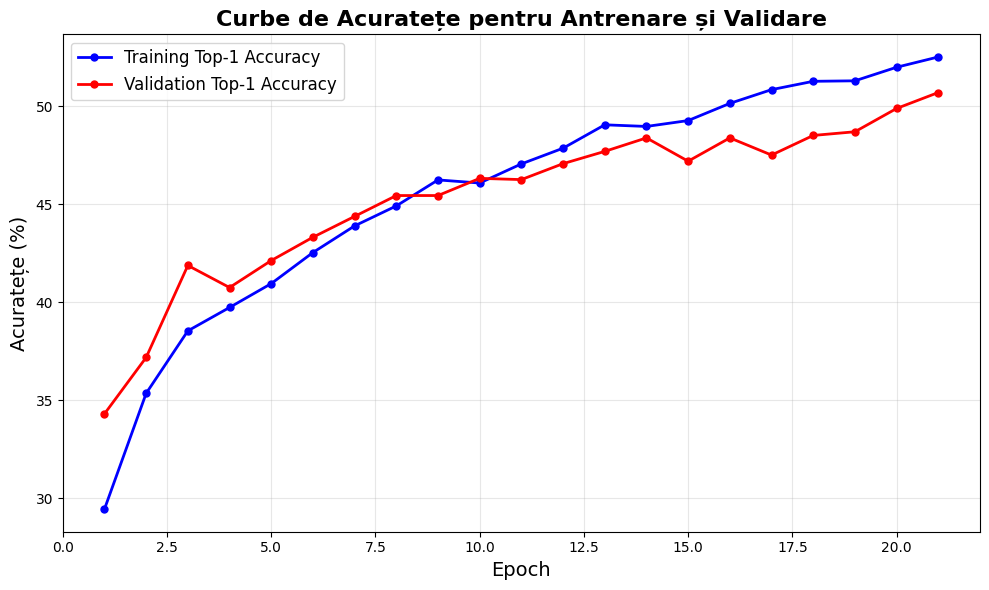

100%|██████████| 375/375 [00:18<00:00, 20.50it/s, epoch=22, train_loss=1.5346, top1_accuracy=52.79%]
Train - Loss: 1.5346, Top-1: 52.79%
100%|██████████| 50/50 [00:01<00:00, 43.87it/s, epoch=22, val_loss=1.5878, top1_accuracy=49.94%]
Val - Loss: 1.5878, Val - Top-1: 49.94%
EarlyStopping counter: 1 out of 7
100%|██████████| 375/375 [00:18<00:00, 19.95it/s, epoch=23, train_loss=1.5292, top1_accuracy=53.08%]
Train - Loss: 1.5292, Top-1: 53.08%
100%|██████████| 50/50 [00:01<00:00, 36.11it/s, epoch=23, val_loss=1.5987, top1_accuracy=49.88%]
Val - Loss: 1.5987, Val - Top-1: 49.88%
EarlyStopping counter: 2 out of 7
100%|██████████| 375/375 [00:17<00:00, 21.34it/s, epoch=24, train_loss=1.5259, top1_accuracy=53.42%]
Train - Loss: 1.5259, Top-1: 53.42%
100%|██████████| 50/50 [00:01<00:00, 42.68it/s, epoch=24, val_loss=1.5840, top1_accuracy=50.31%]
Val - Loss: 1.5840, Val - Top-1: 50.31%
EarlyStopping counter: 3 out of 7


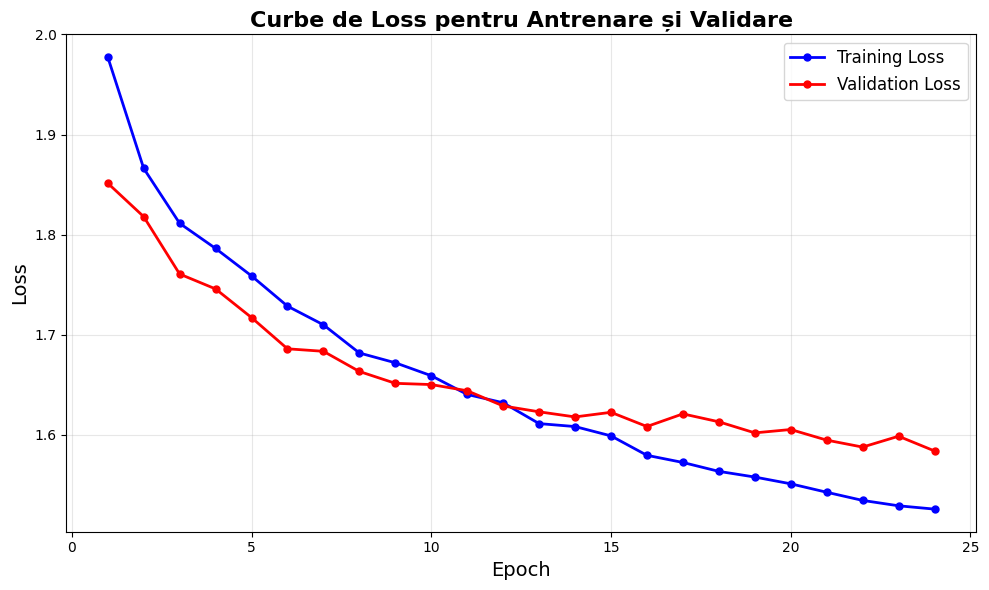

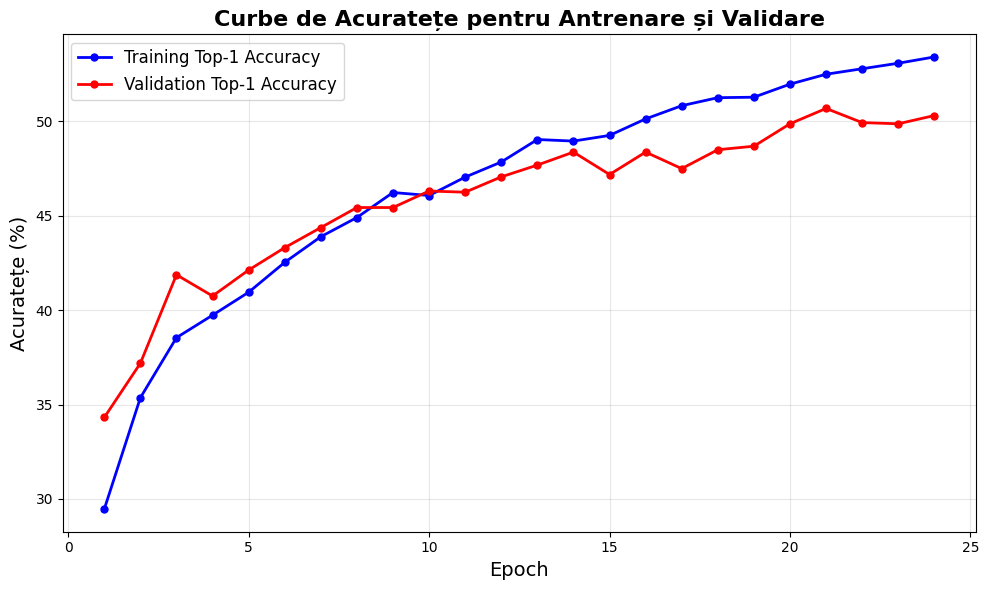

100%|██████████| 375/375 [00:18<00:00, 19.81it/s, epoch=25, train_loss=1.5066, top1_accuracy=54.28%]
Train - Loss: 1.5066, Top-1: 54.28%
100%|██████████| 50/50 [00:01<00:00, 38.99it/s, epoch=25, val_loss=1.5741, top1_accuracy=51.38%]
Val - Loss: 1.5741, Val - Top-1: 51.38%
Validation accuracy increased (50.687500 → 51.375000). Saving model...
100%|██████████| 375/375 [00:18<00:00, 20.67it/s, epoch=26, train_loss=1.5158, top1_accuracy=53.70%]
Train - Loss: 1.5158, Top-1: 53.70%
100%|██████████| 50/50 [00:01<00:00, 39.96it/s, epoch=26, val_loss=1.5703, top1_accuracy=51.88%]
Val - Loss: 1.5703, Val - Top-1: 51.88%
Validation accuracy increased (51.375000 → 51.875000). Saving model...
100%|██████████| 375/375 [00:27<00:00, 13.70it/s, epoch=27, train_loss=1.4894, top1_accuracy=54.98%]
Train - Loss: 1.4894, Top-1: 54.98%
100%|██████████| 50/50 [00:01<00:00, 31.67it/s, epoch=27, val_loss=1.5753, top1_accuracy=50.94%]
Val - Loss: 1.5753, Val - Top-1: 50.94%
EarlyStopping counter: 1 out of 7


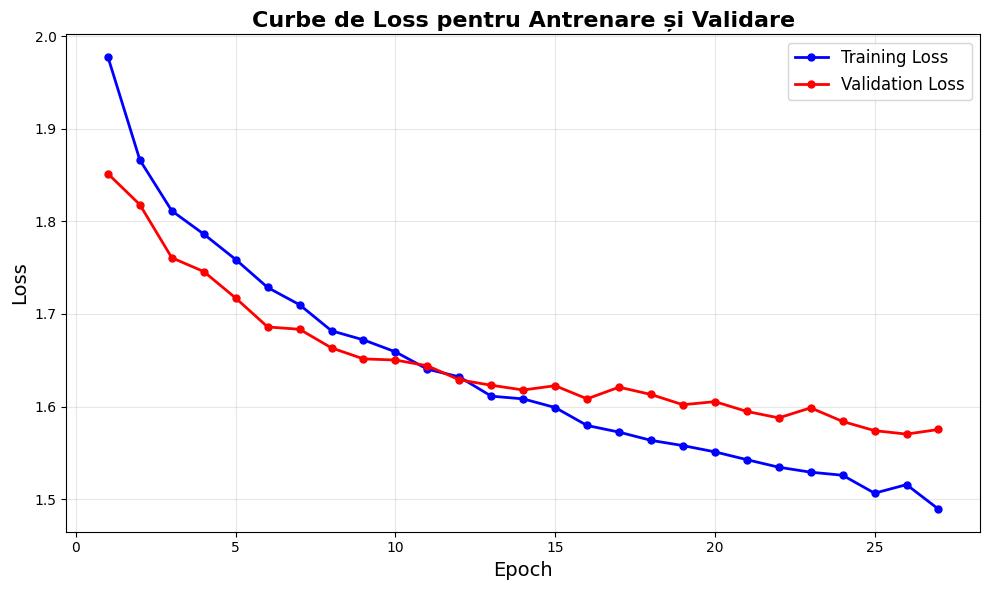

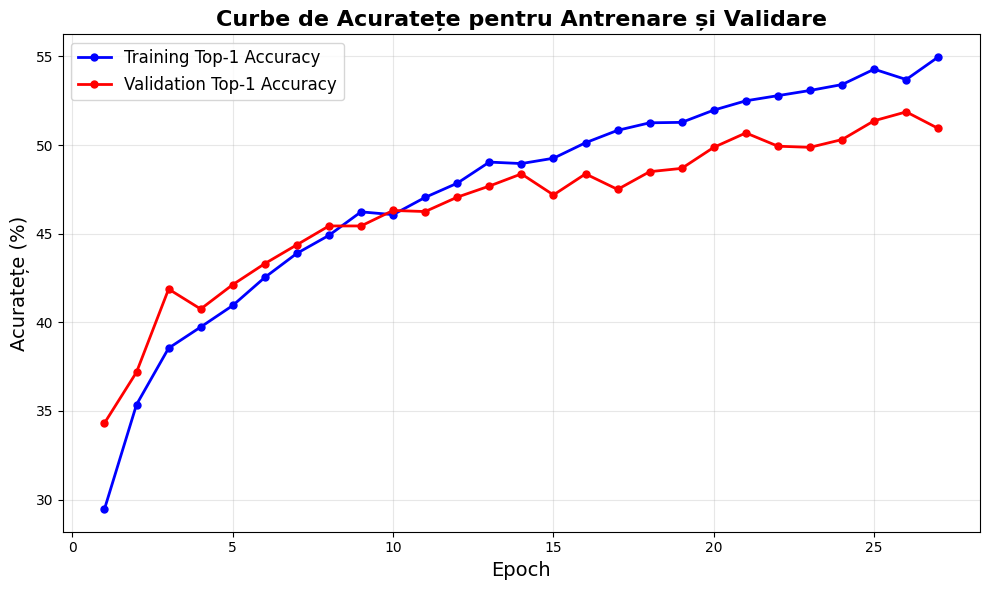

100%|██████████| 375/375 [00:25<00:00, 14.48it/s, epoch=28, train_loss=1.4944, top1_accuracy=54.65%]
Train - Loss: 1.4944, Top-1: 54.65%
100%|██████████| 50/50 [00:01<00:00, 28.43it/s, epoch=28, val_loss=1.5840, top1_accuracy=50.62%]
Val - Loss: 1.5840, Val - Top-1: 50.62%
EarlyStopping counter: 2 out of 7
100%|██████████| 375/375 [00:23<00:00, 15.92it/s, epoch=29, train_loss=1.4838, top1_accuracy=55.61%]
Train - Loss: 1.4838, Top-1: 55.61%
100%|██████████| 50/50 [00:01<00:00, 33.98it/s, epoch=29, val_loss=1.5723, top1_accuracy=51.31%]
Val - Loss: 1.5723, Val - Top-1: 51.31%
EarlyStopping counter: 3 out of 7
100%|██████████| 375/375 [00:22<00:00, 16.51it/s, epoch=30, train_loss=1.4866, top1_accuracy=54.57%]
Train - Loss: 1.4866, Top-1: 54.57%
100%|██████████| 50/50 [00:01<00:00, 35.54it/s, epoch=30, val_loss=1.5659, top1_accuracy=51.81%]
Val - Loss: 1.5659, Val - Top-1: 51.81%
EarlyStopping counter: 4 out of 7


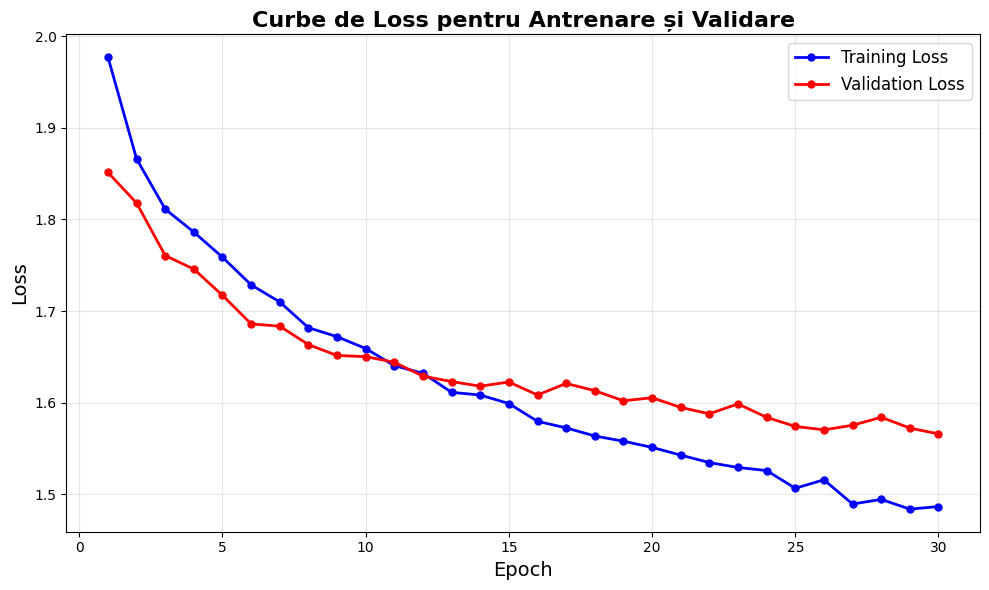

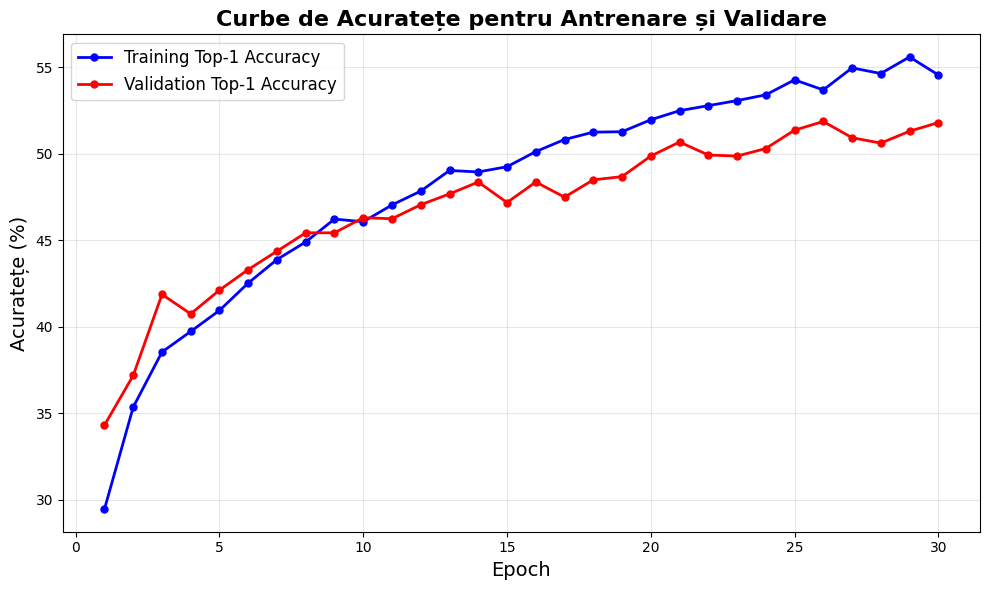

100%|██████████| 375/375 [00:21<00:00, 17.61it/s, epoch=31, train_loss=1.4852, top1_accuracy=55.39%]
Train - Loss: 1.4852, Top-1: 55.39%
100%|██████████| 50/50 [00:01<00:00, 38.58it/s, epoch=31, val_loss=1.5687, top1_accuracy=50.75%]
Val - Loss: 1.5687, Val - Top-1: 50.75%
EarlyStopping counter: 5 out of 7
100%|██████████| 375/375 [00:22<00:00, 16.67it/s, epoch=32, train_loss=1.4781, top1_accuracy=55.26%]
Train - Loss: 1.4781, Top-1: 55.26%
100%|██████████| 50/50 [00:01<00:00, 40.46it/s, epoch=32, val_loss=1.5716, top1_accuracy=51.44%]
Val - Loss: 1.5716, Val - Top-1: 51.44%
EarlyStopping counter: 6 out of 7
100%|██████████| 375/375 [00:17<00:00, 21.27it/s, epoch=33, train_loss=1.4753, top1_accuracy=55.88%]
Train - Loss: 1.4753, Top-1: 55.88%
100%|██████████| 50/50 [00:01<00:00, 42.08it/s, epoch=33, val_loss=1.5640, top1_accuracy=51.31%]
Val - Loss: 1.5640, Val - Top-1: 51.31%
EarlyStopping counter: 7 out of 7
Early stopping triggered at epoch 33

Model 2 Best Validation Accuracy: 51.8

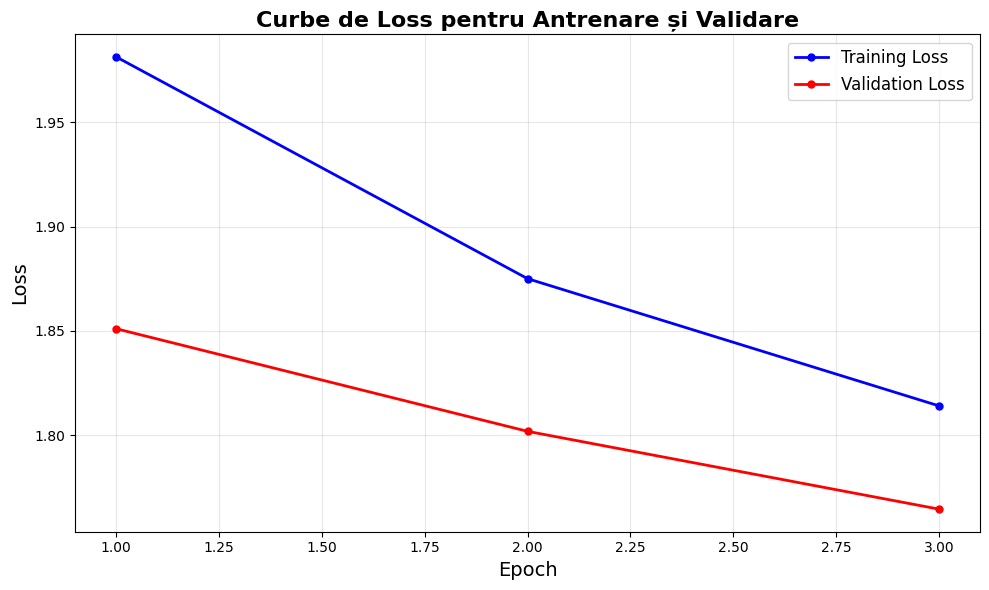

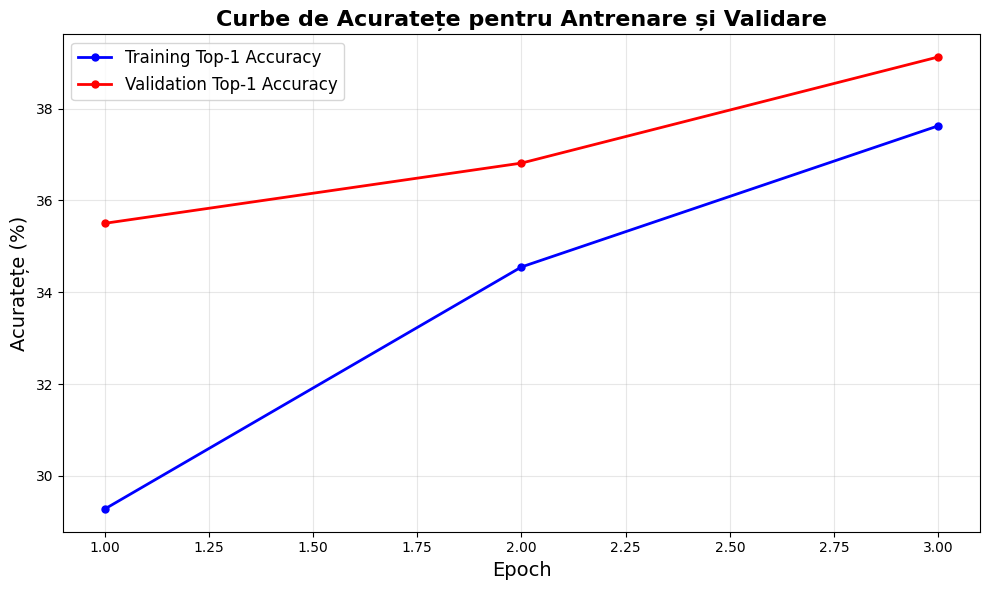

100%|██████████| 375/375 [00:16<00:00, 23.04it/s, epoch=4, train_loss=1.7863, top1_accuracy=39.96%]
Train - Loss: 1.7863, Top-1: 39.96%
100%|██████████| 50/50 [00:00<00:00, 55.60it/s, epoch=4, val_loss=1.7283, top1_accuracy=41.25%]
Val - Loss: 1.7283, Val - Top-1: 41.25%
Validation accuracy increased (39.125000 → 41.250000). Saving model...
100%|██████████| 375/375 [00:16<00:00, 22.23it/s, epoch=5, train_loss=1.7570, top1_accuracy=41.02%]
Train - Loss: 1.7570, Top-1: 41.02%
100%|██████████| 50/50 [00:00<00:00, 56.84it/s, epoch=5, val_loss=1.7221, top1_accuracy=42.19%]
Val - Loss: 1.7221, Val - Top-1: 42.19%
Validation accuracy increased (41.250000 → 42.187500). Saving model...
100%|██████████| 375/375 [00:16<00:00, 22.49it/s, epoch=6, train_loss=1.7391, top1_accuracy=42.11%]
Train - Loss: 1.7391, Top-1: 42.11%
100%|██████████| 50/50 [00:01<00:00, 49.87it/s, epoch=6, val_loss=1.6880, top1_accuracy=44.56%]
Val - Loss: 1.6880, Val - Top-1: 44.56%
Validation accuracy increased (42.187500 →

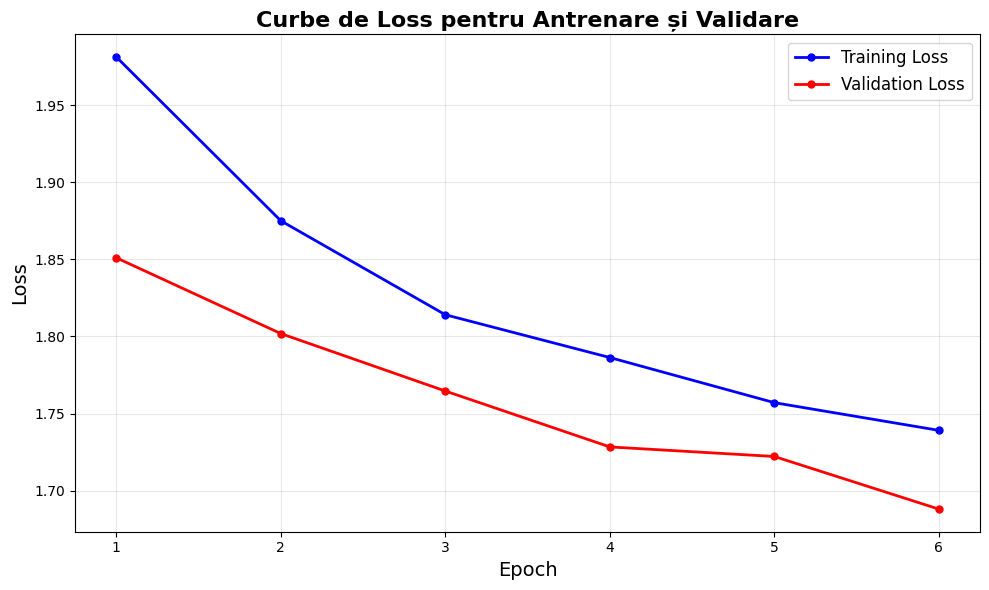

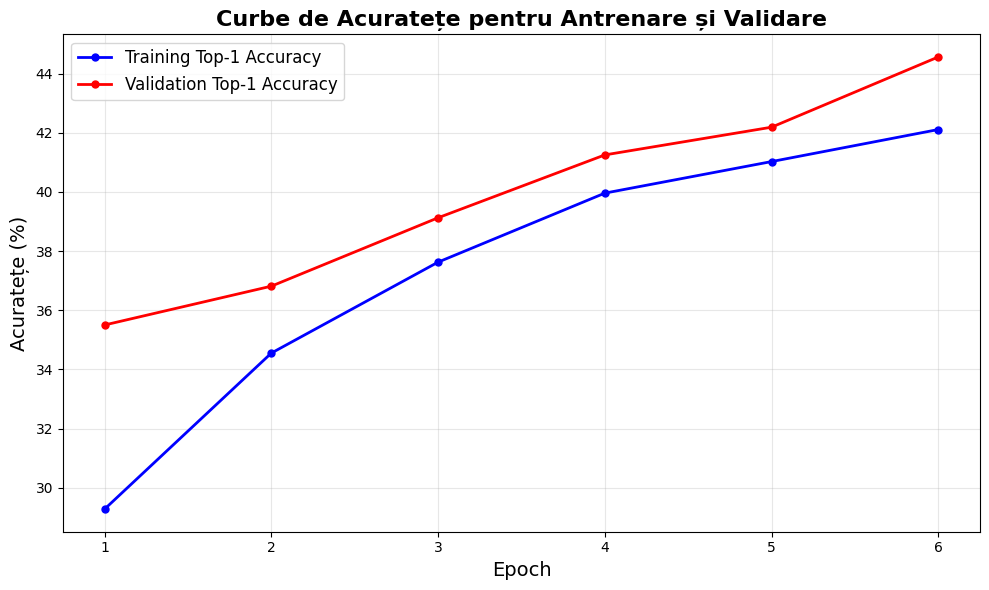

100%|██████████| 375/375 [00:16<00:00, 22.15it/s, epoch=7, train_loss=1.7160, top1_accuracy=43.02%]
Train - Loss: 1.7160, Top-1: 43.02%
100%|██████████| 50/50 [00:00<00:00, 55.08it/s, epoch=7, val_loss=1.6896, top1_accuracy=43.56%]
Val - Loss: 1.6896, Val - Top-1: 43.56%
EarlyStopping counter: 1 out of 7
100%|██████████| 375/375 [00:15<00:00, 23.81it/s, epoch=8, train_loss=1.6914, top1_accuracy=45.08%]
Train - Loss: 1.6914, Top-1: 45.08%
100%|██████████| 50/50 [00:00<00:00, 53.56it/s, epoch=8, val_loss=1.6666, top1_accuracy=45.06%]
Val - Loss: 1.6666, Val - Top-1: 45.06%
Validation accuracy increased (44.562500 → 45.062500). Saving model...
100%|██████████| 375/375 [00:16<00:00, 23.26it/s, epoch=9, train_loss=1.6774, top1_accuracy=45.53%]
Train - Loss: 1.6774, Top-1: 45.53%
100%|██████████| 50/50 [00:00<00:00, 50.51it/s, epoch=9, val_loss=1.6592, top1_accuracy=46.50%]
Val - Loss: 1.6592, Val - Top-1: 46.50%
Validation accuracy increased (45.062500 → 46.500000). Saving model...


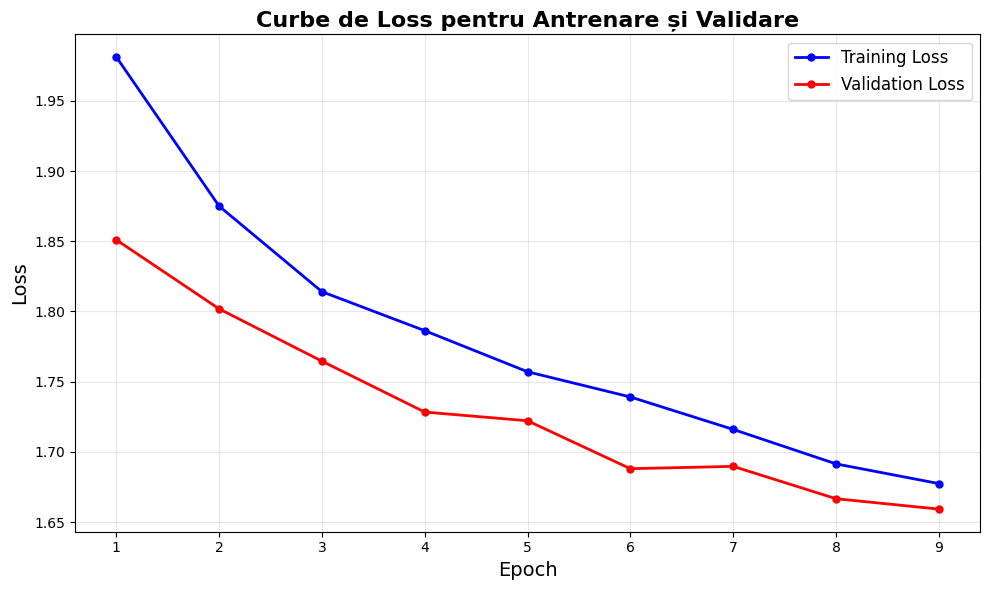

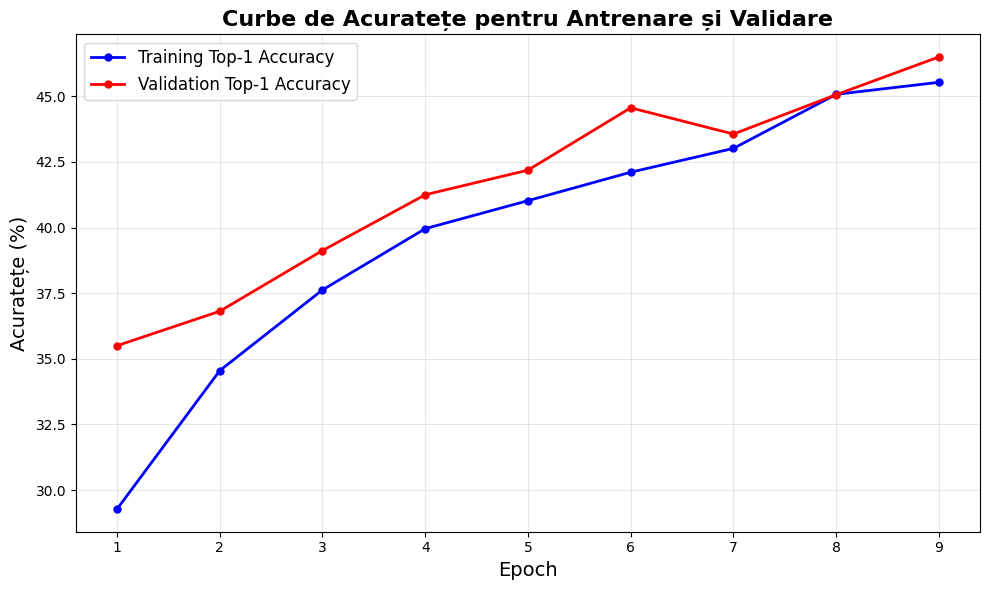

100%|██████████| 375/375 [00:16<00:00, 22.25it/s, epoch=10, train_loss=1.6714, top1_accuracy=45.77%]
Train - Loss: 1.6714, Top-1: 45.77%
100%|██████████| 50/50 [00:01<00:00, 32.56it/s, epoch=10, val_loss=1.6576, top1_accuracy=46.88%]
Val - Loss: 1.6576, Val - Top-1: 46.88%
Validation accuracy increased (46.500000 → 46.875000). Saving model...
100%|██████████| 375/375 [00:18<00:00, 20.74it/s, epoch=11, train_loss=1.6504, top1_accuracy=46.52%]
Train - Loss: 1.6504, Top-1: 46.52%
100%|██████████| 50/50 [00:01<00:00, 34.49it/s, epoch=11, val_loss=1.6389, top1_accuracy=46.94%]
Val - Loss: 1.6389, Val - Top-1: 46.94%
Validation accuracy increased (46.875000 → 46.937500). Saving model...
100%|██████████| 375/375 [00:19<00:00, 19.41it/s, epoch=12, train_loss=1.6382, top1_accuracy=47.45%]
Train - Loss: 1.6382, Top-1: 47.45%
100%|██████████| 50/50 [00:01<00:00, 38.45it/s, epoch=12, val_loss=1.6405, top1_accuracy=47.12%]
Val - Loss: 1.6405, Val - Top-1: 47.12%
Validation accuracy increased (46.93

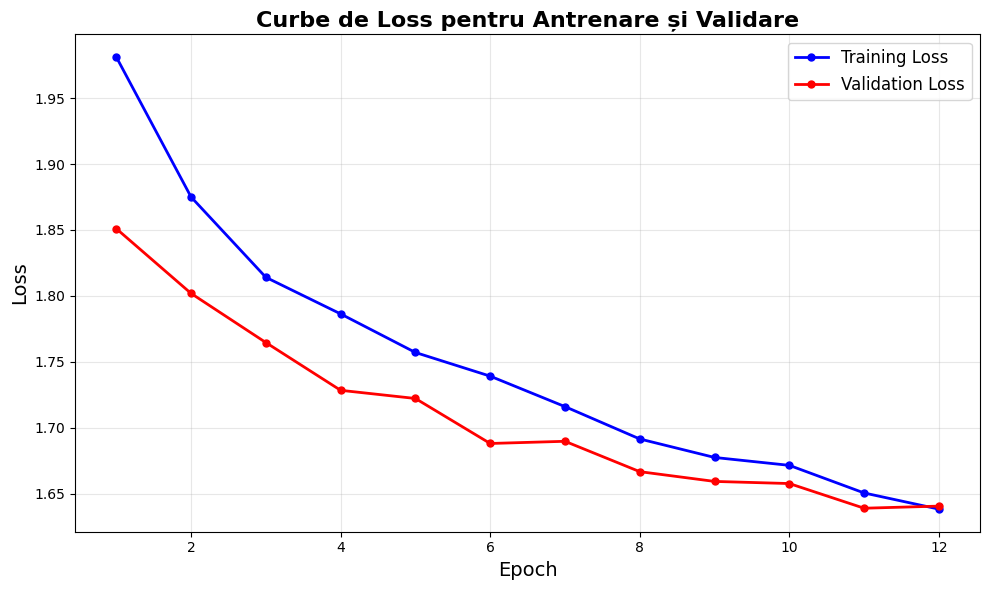

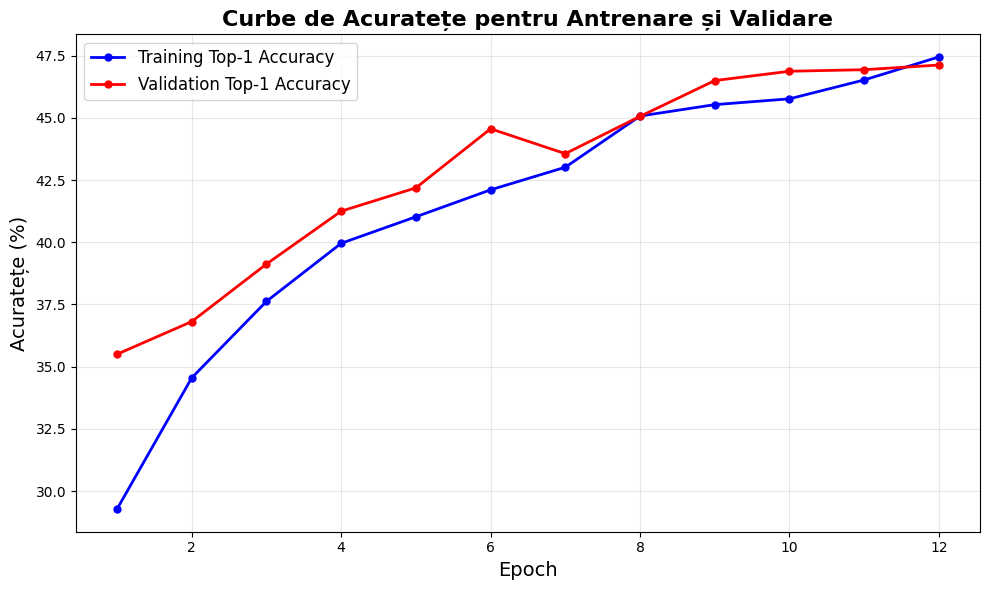

100%|██████████| 375/375 [00:17<00:00, 20.90it/s, epoch=13, train_loss=1.6190, top1_accuracy=48.36%]
Train - Loss: 1.6190, Top-1: 48.36%
100%|██████████| 50/50 [00:01<00:00, 42.06it/s, epoch=13, val_loss=1.6311, top1_accuracy=47.06%]
Val - Loss: 1.6311, Val - Top-1: 47.06%
EarlyStopping counter: 1 out of 7
100%|██████████| 375/375 [00:18<00:00, 19.90it/s, epoch=14, train_loss=1.6105, top1_accuracy=48.40%]
Train - Loss: 1.6105, Top-1: 48.40%
100%|██████████| 50/50 [00:01<00:00, 38.12it/s, epoch=14, val_loss=1.6218, top1_accuracy=47.88%]
Val - Loss: 1.6218, Val - Top-1: 47.88%
Validation accuracy increased (47.125000 → 47.875000). Saving model...
100%|██████████| 375/375 [00:18<00:00, 20.54it/s, epoch=15, train_loss=1.5952, top1_accuracy=49.38%]
Train - Loss: 1.5952, Top-1: 49.38%
100%|██████████| 50/50 [00:01<00:00, 39.90it/s, epoch=15, val_loss=1.6220, top1_accuracy=48.06%]
Val - Loss: 1.6220, Val - Top-1: 48.06%
Validation accuracy increased (47.875000 → 48.062500). Saving model...


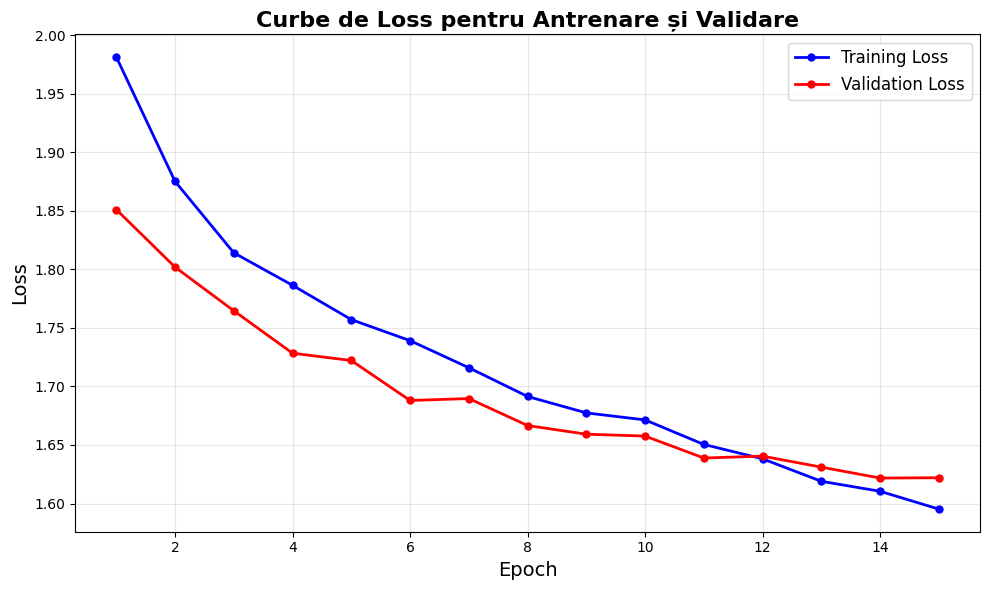

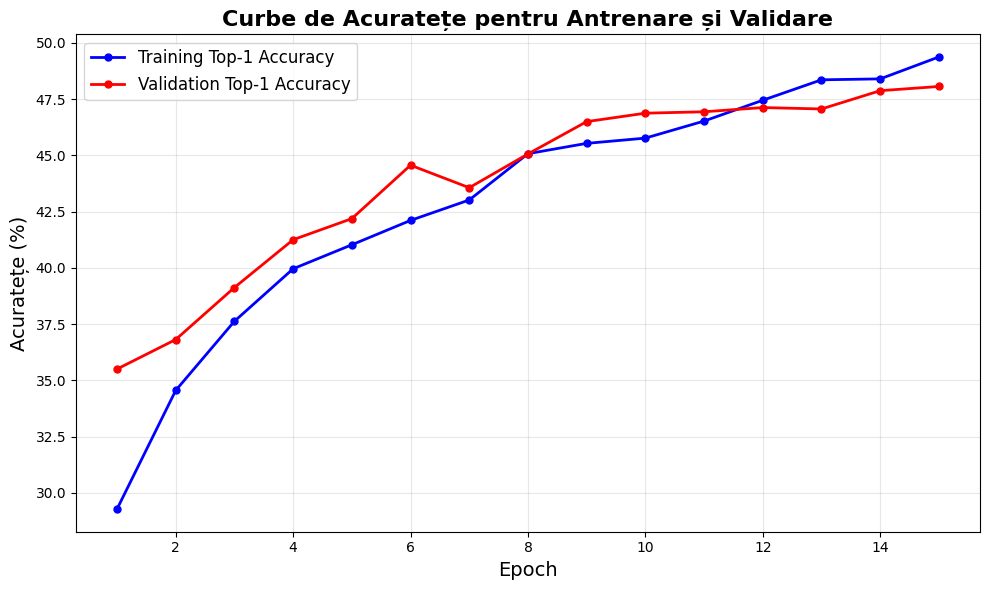

100%|██████████| 375/375 [00:19<00:00, 19.46it/s, epoch=16, train_loss=1.5914, top1_accuracy=50.14%]
Train - Loss: 1.5914, Top-1: 50.14%
100%|██████████| 50/50 [00:01<00:00, 35.28it/s, epoch=16, val_loss=1.6169, top1_accuracy=48.75%]
Val - Loss: 1.6169, Val - Top-1: 48.75%
Validation accuracy increased (48.062500 → 48.750000). Saving model...
100%|██████████| 375/375 [00:18<00:00, 20.34it/s, epoch=17, train_loss=1.5848, top1_accuracy=49.74%]
Train - Loss: 1.5848, Top-1: 49.74%
100%|██████████| 50/50 [00:01<00:00, 38.30it/s, epoch=17, val_loss=1.6106, top1_accuracy=49.81%]
Val - Loss: 1.6106, Val - Top-1: 49.81%
Validation accuracy increased (48.750000 → 49.812500). Saving model...
100%|██████████| 375/375 [00:18<00:00, 20.16it/s, epoch=18, train_loss=1.5705, top1_accuracy=50.87%]
Train - Loss: 1.5705, Top-1: 50.87%
100%|██████████| 50/50 [00:01<00:00, 40.02it/s, epoch=18, val_loss=1.6020, top1_accuracy=50.00%]
Val - Loss: 1.6020, Val - Top-1: 50.00%
Validation accuracy increased (49.81

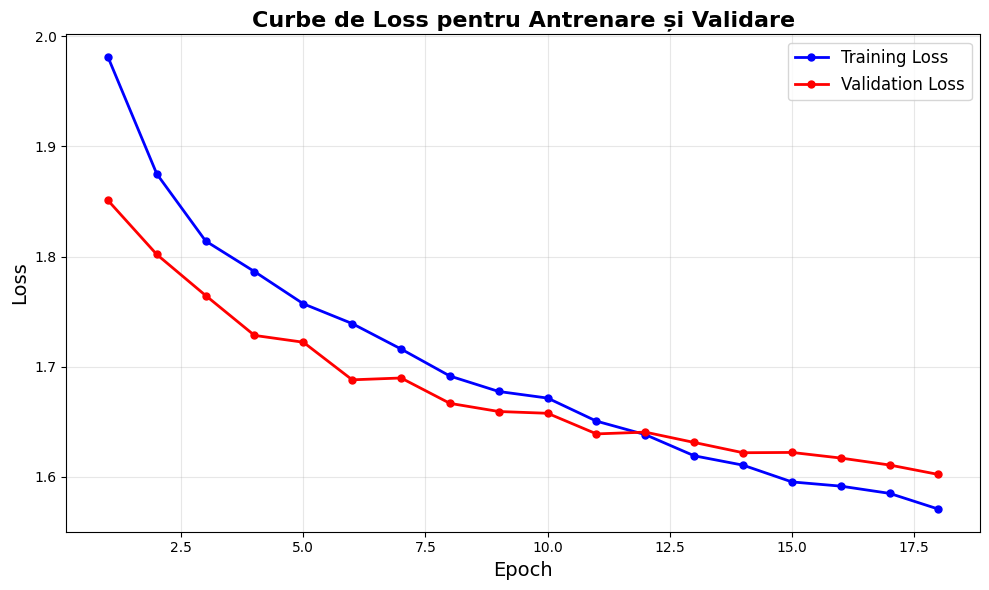

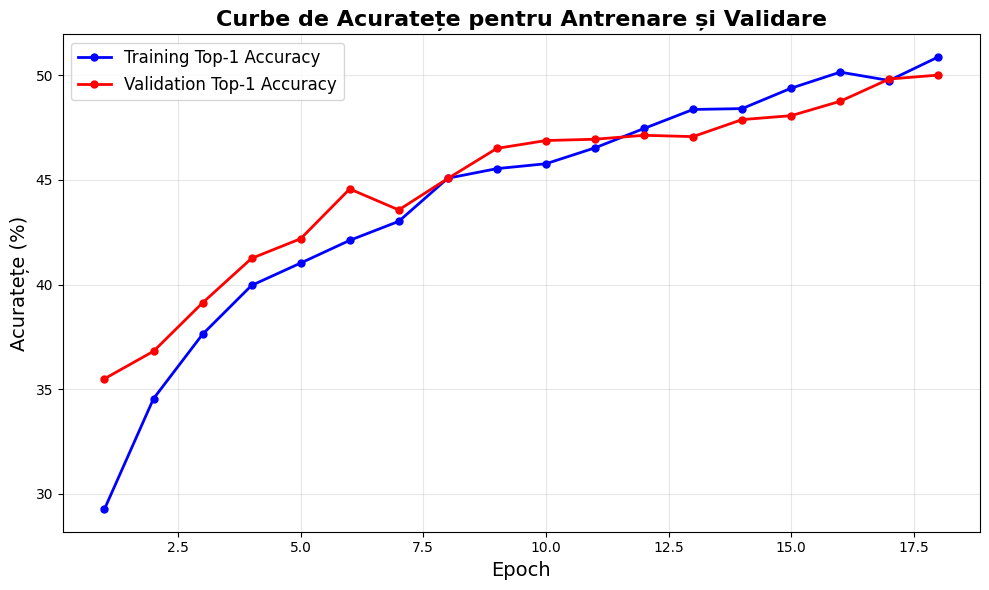

100%|██████████| 375/375 [00:19<00:00, 19.42it/s, epoch=19, train_loss=1.5726, top1_accuracy=50.66%]
Train - Loss: 1.5726, Top-1: 50.66%
100%|██████████| 50/50 [00:01<00:00, 34.90it/s, epoch=19, val_loss=1.5999, top1_accuracy=49.38%]
Val - Loss: 1.5999, Val - Top-1: 49.38%
EarlyStopping counter: 1 out of 7
100%|██████████| 375/375 [00:18<00:00, 20.04it/s, epoch=20, train_loss=1.5593, top1_accuracy=51.64%]
Train - Loss: 1.5593, Top-1: 51.64%
100%|██████████| 50/50 [00:01<00:00, 38.83it/s, epoch=20, val_loss=1.5981, top1_accuracy=49.69%]
Val - Loss: 1.5981, Val - Top-1: 49.69%
EarlyStopping counter: 2 out of 7
100%|██████████| 375/375 [00:18<00:00, 20.57it/s, epoch=21, train_loss=1.5621, top1_accuracy=51.02%]
Train - Loss: 1.5621, Top-1: 51.02%
100%|██████████| 50/50 [00:01<00:00, 37.91it/s, epoch=21, val_loss=1.5881, top1_accuracy=50.50%]
Val - Loss: 1.5881, Val - Top-1: 50.50%
Validation accuracy increased (50.000000 → 50.500000). Saving model...


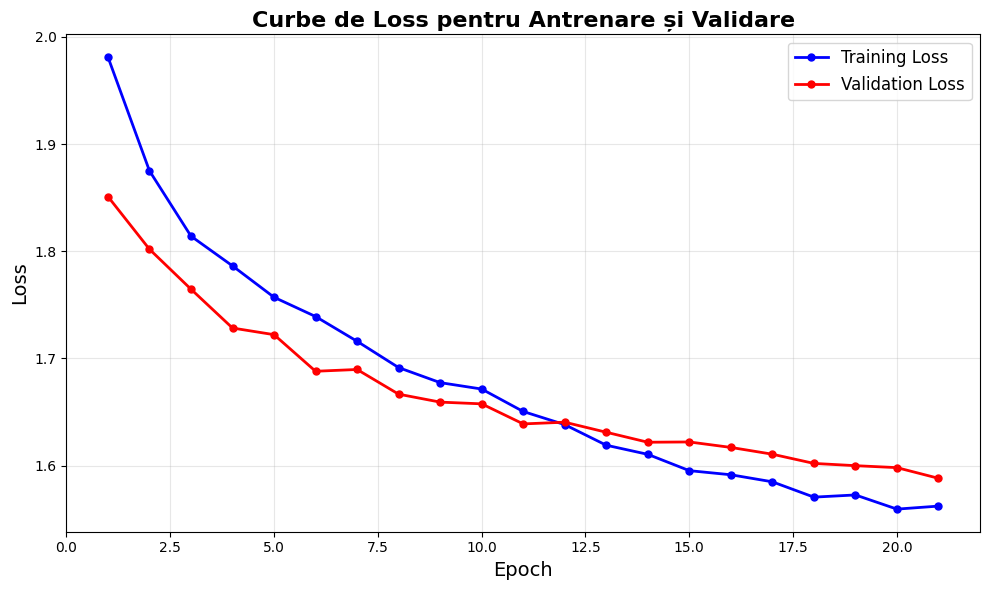

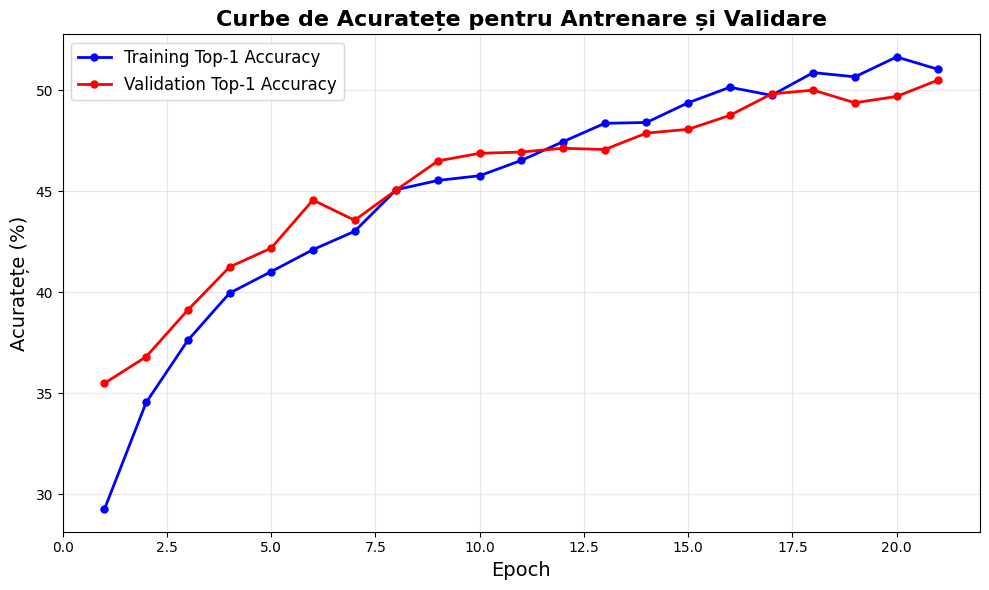

100%|██████████| 375/375 [00:18<00:00, 20.07it/s, epoch=22, train_loss=1.5380, top1_accuracy=51.83%]
Train - Loss: 1.5380, Top-1: 51.83%
100%|██████████| 50/50 [00:01<00:00, 40.44it/s, epoch=22, val_loss=1.5871, top1_accuracy=50.38%]
Val - Loss: 1.5871, Val - Top-1: 50.38%
EarlyStopping counter: 1 out of 7
100%|██████████| 375/375 [00:17<00:00, 21.03it/s, epoch=23, train_loss=1.5524, top1_accuracy=51.51%]
Train - Loss: 1.5524, Top-1: 51.51%
100%|██████████| 50/50 [00:01<00:00, 40.32it/s, epoch=23, val_loss=1.5999, top1_accuracy=49.38%]
Val - Loss: 1.5999, Val - Top-1: 49.38%
EarlyStopping counter: 2 out of 7
100%|██████████| 375/375 [00:18<00:00, 20.02it/s, epoch=24, train_loss=1.5378, top1_accuracy=52.88%]
Train - Loss: 1.5378, Top-1: 52.88%
100%|██████████| 50/50 [00:01<00:00, 36.88it/s, epoch=24, val_loss=1.5873, top1_accuracy=50.00%]
Val - Loss: 1.5873, Val - Top-1: 50.00%
EarlyStopping counter: 3 out of 7


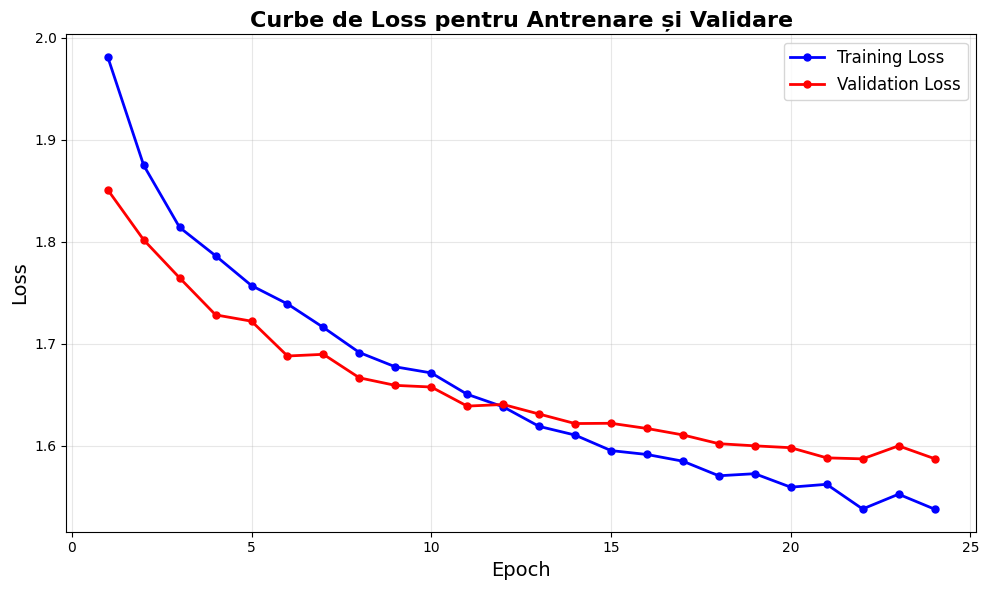

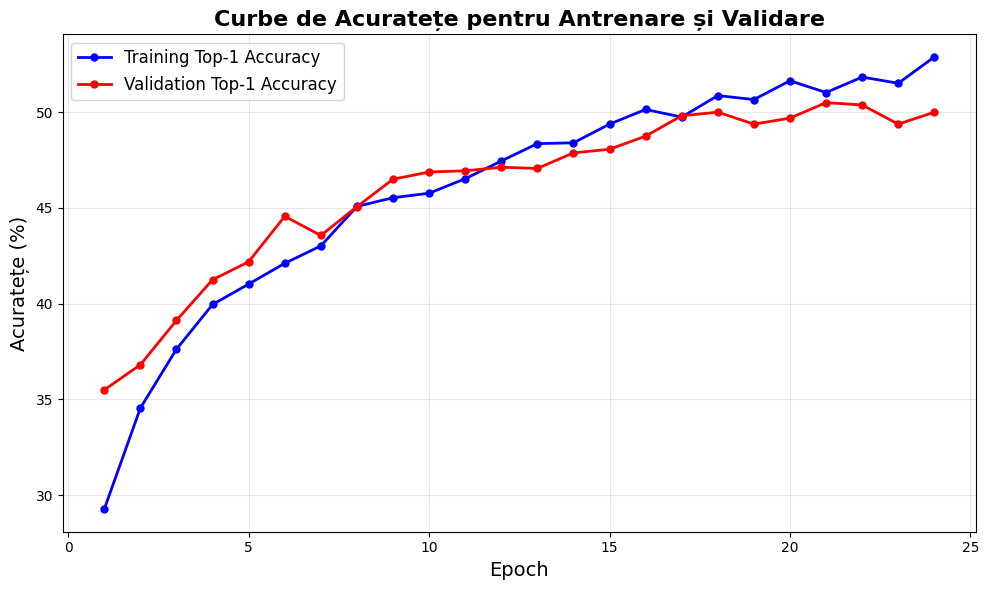

100%|██████████| 375/375 [00:18<00:00, 20.61it/s, epoch=25, train_loss=1.5335, top1_accuracy=52.58%]
Train - Loss: 1.5335, Top-1: 52.58%
100%|██████████| 50/50 [00:01<00:00, 38.74it/s, epoch=25, val_loss=1.5811, top1_accuracy=51.12%]
Val - Loss: 1.5811, Val - Top-1: 51.12%
Validation accuracy increased (50.500000 → 51.125000). Saving model...
100%|██████████| 375/375 [00:18<00:00, 20.80it/s, epoch=26, train_loss=1.5315, top1_accuracy=52.89%]
Train - Loss: 1.5315, Top-1: 52.89%
100%|██████████| 50/50 [00:01<00:00, 36.30it/s, epoch=26, val_loss=1.5835, top1_accuracy=50.81%]
Val - Loss: 1.5835, Val - Top-1: 50.81%
EarlyStopping counter: 1 out of 7
100%|██████████| 375/375 [00:17<00:00, 20.88it/s, epoch=27, train_loss=1.5230, top1_accuracy=53.22%]
Train - Loss: 1.5230, Top-1: 53.22%
100%|██████████| 50/50 [00:01<00:00, 40.08it/s, epoch=27, val_loss=1.5843, top1_accuracy=50.06%]
Val - Loss: 1.5843, Val - Top-1: 50.06%
EarlyStopping counter: 2 out of 7


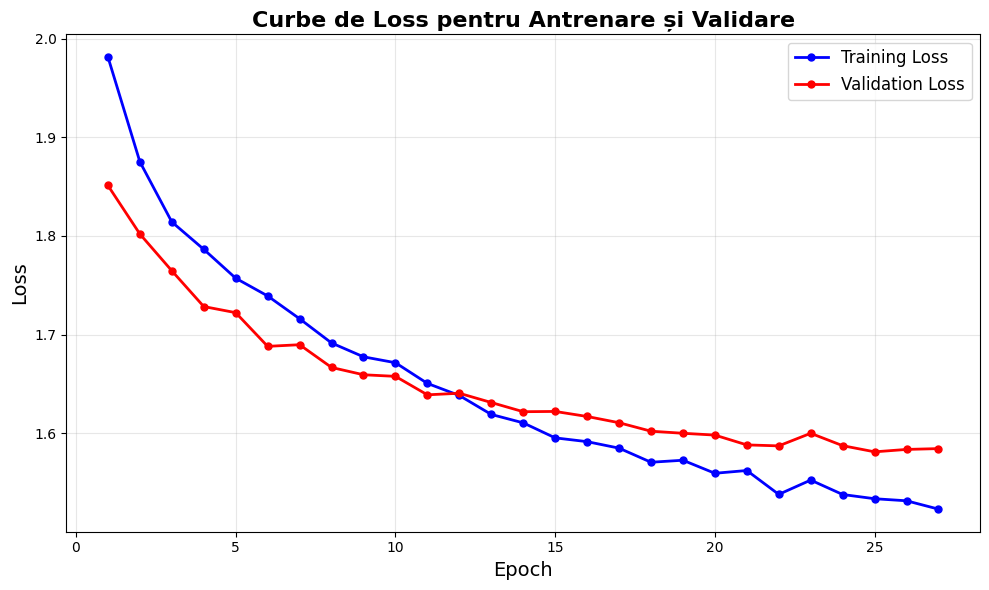

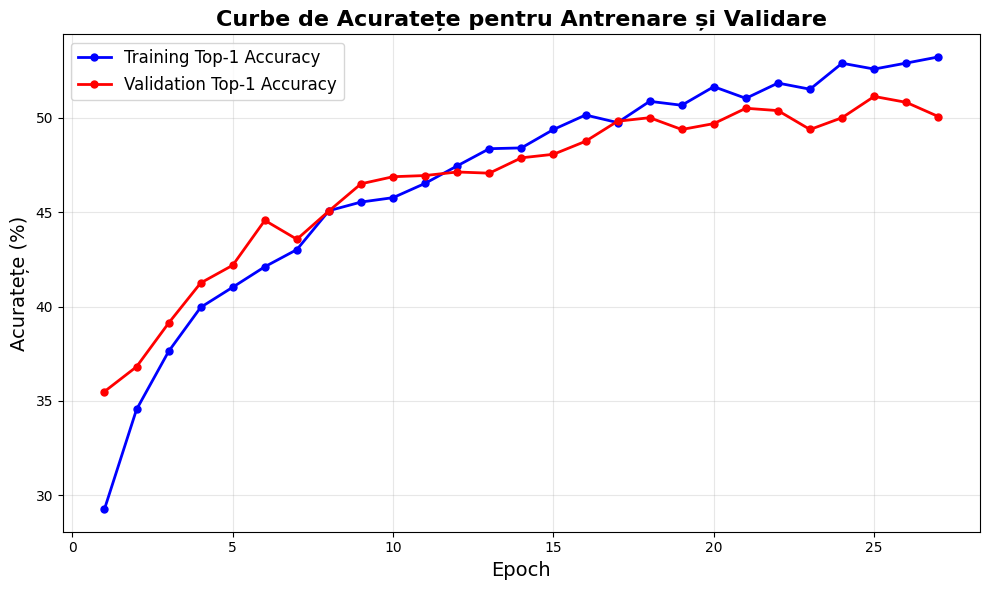

100%|██████████| 375/375 [00:18<00:00, 20.39it/s, epoch=28, train_loss=1.5260, top1_accuracy=53.07%]
Train - Loss: 1.5260, Top-1: 53.07%
100%|██████████| 50/50 [00:01<00:00, 41.28it/s, epoch=28, val_loss=1.5816, top1_accuracy=51.06%]
Val - Loss: 1.5816, Val - Top-1: 51.06%
EarlyStopping counter: 3 out of 7
100%|██████████| 375/375 [00:17<00:00, 21.68it/s, epoch=29, train_loss=1.5183, top1_accuracy=53.55%]
Train - Loss: 1.5183, Top-1: 53.55%
100%|██████████| 50/50 [00:01<00:00, 39.40it/s, epoch=29, val_loss=1.5822, top1_accuracy=50.06%]
Val - Loss: 1.5822, Val - Top-1: 50.06%
EarlyStopping counter: 4 out of 7
100%|██████████| 375/375 [00:18<00:00, 20.69it/s, epoch=30, train_loss=1.5208, top1_accuracy=53.90%]
Train - Loss: 1.5208, Top-1: 53.90%
100%|██████████| 50/50 [00:01<00:00, 36.49it/s, epoch=30, val_loss=1.5771, top1_accuracy=51.12%]
Val - Loss: 1.5771, Val - Top-1: 51.12%
EarlyStopping counter: 5 out of 7


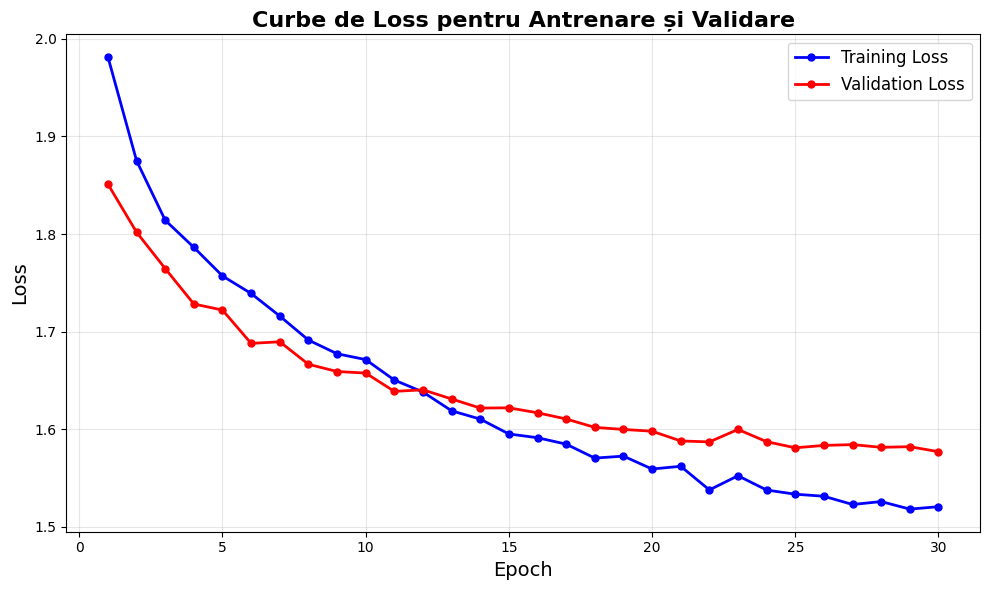

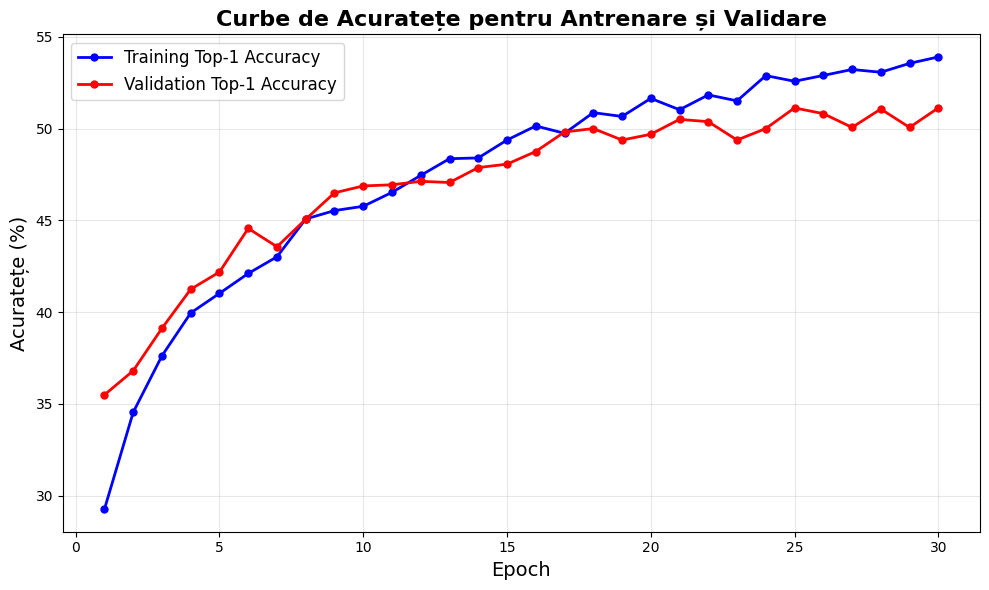

100%|██████████| 375/375 [00:18<00:00, 19.89it/s, epoch=31, train_loss=1.5172, top1_accuracy=53.84%]
Train - Loss: 1.5172, Top-1: 53.84%
100%|██████████| 50/50 [00:01<00:00, 31.35it/s, epoch=31, val_loss=1.5798, top1_accuracy=50.69%]
Val - Loss: 1.5798, Val - Top-1: 50.69%
EarlyStopping counter: 6 out of 7
100%|██████████| 375/375 [00:18<00:00, 19.74it/s, epoch=32, train_loss=1.5091, top1_accuracy=54.28%]
Train - Loss: 1.5091, Top-1: 54.28%
100%|██████████| 50/50 [00:01<00:00, 41.74it/s, epoch=32, val_loss=1.5748, top1_accuracy=50.81%]
Val - Loss: 1.5748, Val - Top-1: 50.81%
EarlyStopping counter: 7 out of 7
Early stopping triggered at epoch 32

Model 3 Best Validation Accuracy: 51.12%

Training Model 4/5
Config: lr=0.0009, weight_decay=9e-05, lr_decay=0.925

100%|██████████| 375/375 [00:15<00:00, 23.69it/s, epoch=1, train_loss=1.9836, top1_accuracy=29.06%]
Train - Loss: 1.9836, Top-1: 29.06%
100%|██████████| 50/50 [00:01<00:00, 45.08it/s, epoch=1, val_loss=1.8613, top1_accuracy=33.19%

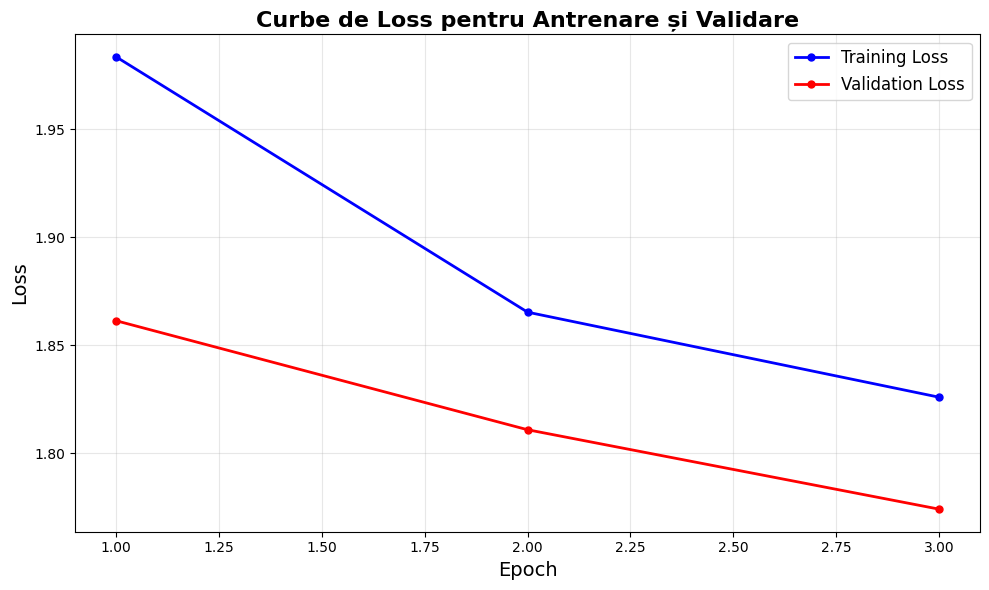

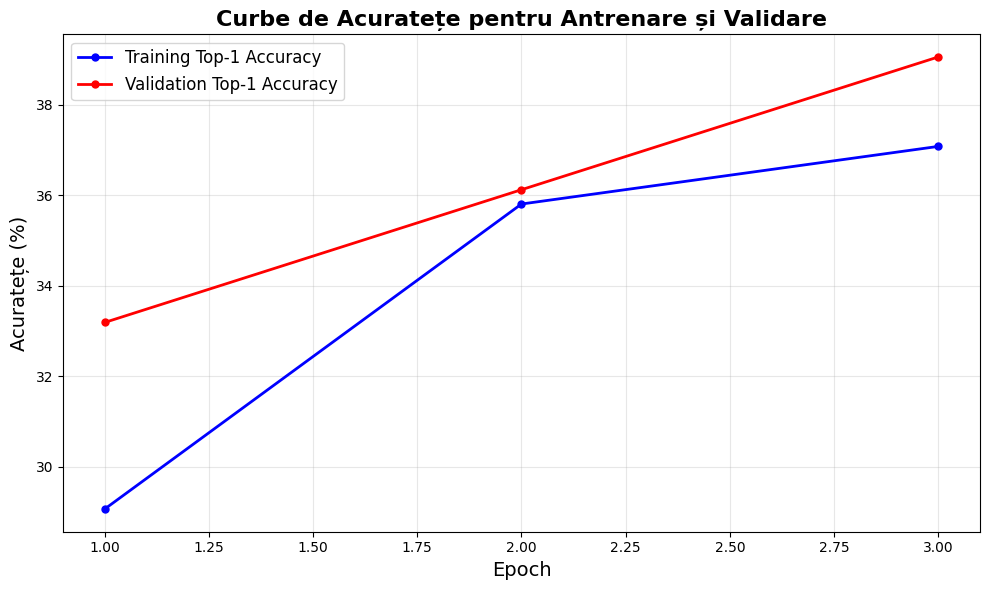

100%|██████████| 375/375 [00:20<00:00, 18.74it/s, epoch=4, train_loss=1.7902, top1_accuracy=39.38%]
Train - Loss: 1.7902, Top-1: 39.38%
100%|██████████| 50/50 [00:01<00:00, 34.24it/s, epoch=4, val_loss=1.7304, top1_accuracy=42.56%]
Val - Loss: 1.7304, Val - Top-1: 42.56%
Validation accuracy increased (39.062500 → 42.562500). Saving model...
100%|██████████| 375/375 [00:17<00:00, 21.44it/s, epoch=5, train_loss=1.7502, top1_accuracy=41.28%]
Train - Loss: 1.7502, Top-1: 41.28%
100%|██████████| 50/50 [00:00<00:00, 52.20it/s, epoch=5, val_loss=1.7211, top1_accuracy=42.44%]
Val - Loss: 1.7211, Val - Top-1: 42.44%
EarlyStopping counter: 1 out of 7
100%|██████████| 375/375 [00:15<00:00, 23.55it/s, epoch=6, train_loss=1.7415, top1_accuracy=42.08%]
Train - Loss: 1.7415, Top-1: 42.08%
100%|██████████| 50/50 [00:01<00:00, 46.64it/s, epoch=6, val_loss=1.6949, top1_accuracy=43.75%]
Val - Loss: 1.6949, Val - Top-1: 43.75%
Validation accuracy increased (42.562500 → 43.750000). Saving model...


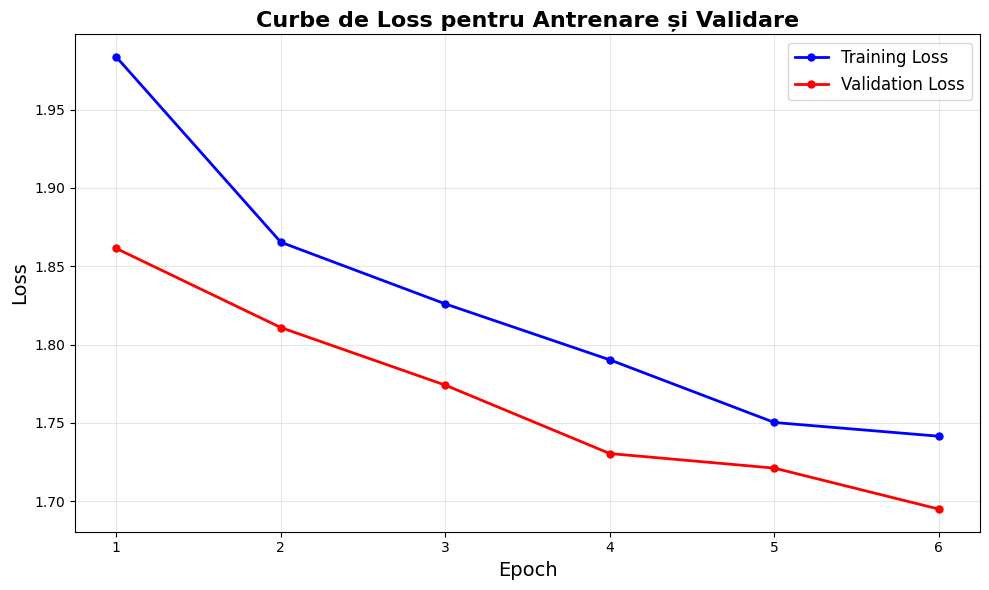

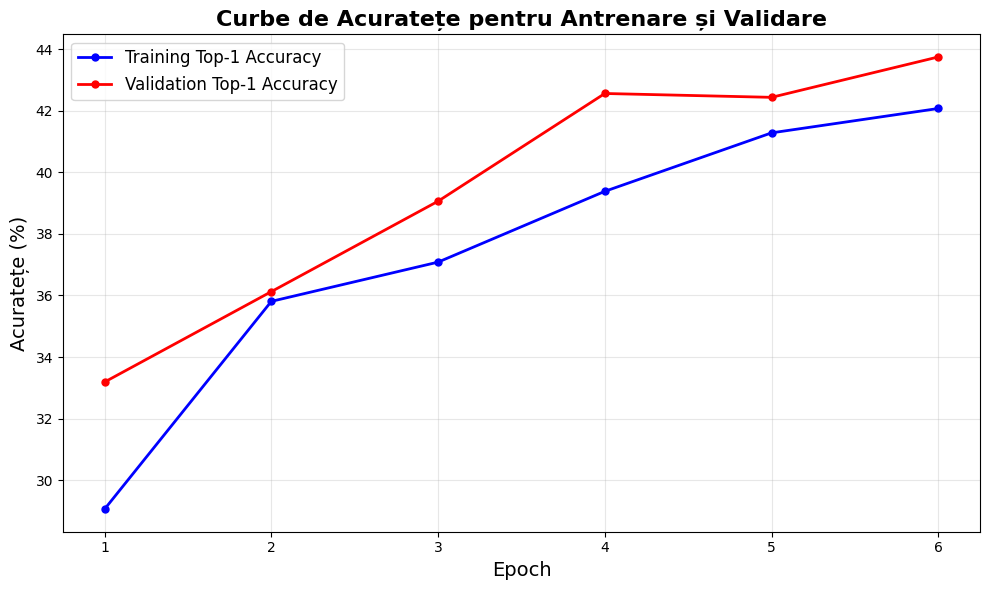

100%|██████████| 375/375 [00:16<00:00, 23.13it/s, epoch=7, train_loss=1.7115, top1_accuracy=43.57%]
Train - Loss: 1.7115, Top-1: 43.57%
100%|██████████| 50/50 [00:00<00:00, 51.43it/s, epoch=7, val_loss=1.6951, top1_accuracy=45.12%]
Val - Loss: 1.6951, Val - Top-1: 45.12%
Validation accuracy increased (43.750000 → 45.125000). Saving model...
100%|██████████| 375/375 [00:15<00:00, 24.56it/s, epoch=8, train_loss=1.6877, top1_accuracy=45.31%]
Train - Loss: 1.6877, Top-1: 45.31%
100%|██████████| 50/50 [00:01<00:00, 49.48it/s, epoch=8, val_loss=1.6668, top1_accuracy=45.75%]
Val - Loss: 1.6668, Val - Top-1: 45.75%
Validation accuracy increased (45.125000 → 45.750000). Saving model...
100%|██████████| 375/375 [00:15<00:00, 24.54it/s, epoch=9, train_loss=1.6834, top1_accuracy=44.79%]
Train - Loss: 1.6834, Top-1: 44.79%
100%|██████████| 50/50 [00:00<00:00, 52.97it/s, epoch=9, val_loss=1.6522, top1_accuracy=45.62%]
Val - Loss: 1.6522, Val - Top-1: 45.62%
EarlyStopping counter: 1 out of 7


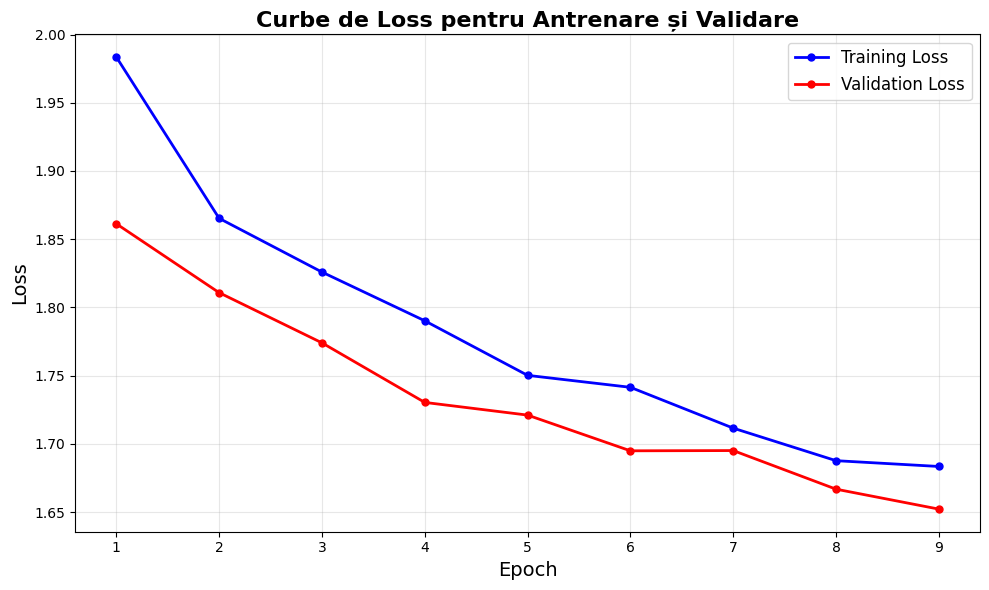

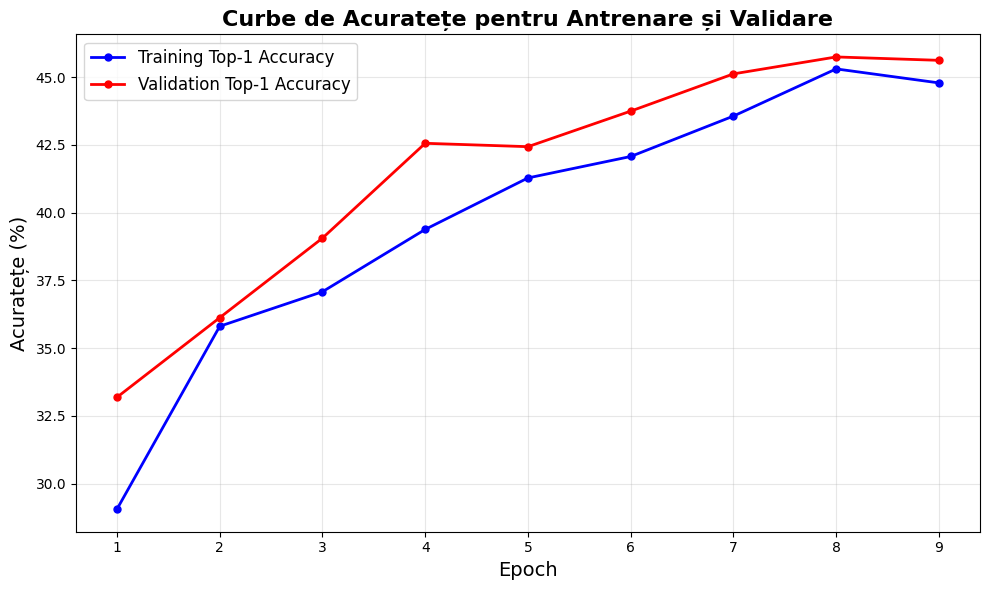

100%|██████████| 375/375 [00:16<00:00, 23.29it/s, epoch=10, train_loss=1.6612, top1_accuracy=46.06%]
Train - Loss: 1.6612, Top-1: 46.06%
100%|██████████| 50/50 [00:00<00:00, 54.38it/s, epoch=10, val_loss=1.6430, top1_accuracy=47.00%]
Val - Loss: 1.6430, Val - Top-1: 47.00%
Validation accuracy increased (45.750000 → 47.000000). Saving model...
100%|██████████| 375/375 [00:15<00:00, 24.13it/s, epoch=11, train_loss=1.6466, top1_accuracy=46.83%]
Train - Loss: 1.6466, Top-1: 46.83%
100%|██████████| 50/50 [00:00<00:00, 55.46it/s, epoch=11, val_loss=1.6436, top1_accuracy=47.12%]
Val - Loss: 1.6436, Val - Top-1: 47.12%
Validation accuracy increased (47.000000 → 47.125000). Saving model...
100%|██████████| 375/375 [00:15<00:00, 24.74it/s, epoch=12, train_loss=1.6316, top1_accuracy=47.38%]
Train - Loss: 1.6316, Top-1: 47.38%
100%|██████████| 50/50 [00:00<00:00, 52.06it/s, epoch=12, val_loss=1.6286, top1_accuracy=47.56%]
Val - Loss: 1.6286, Val - Top-1: 47.56%
Validation accuracy increased (47.12

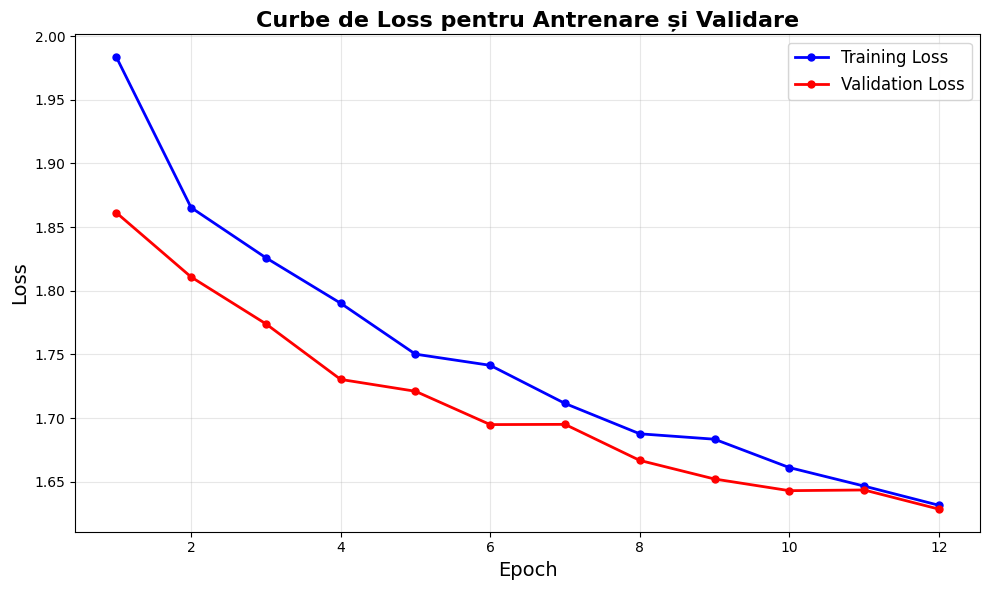

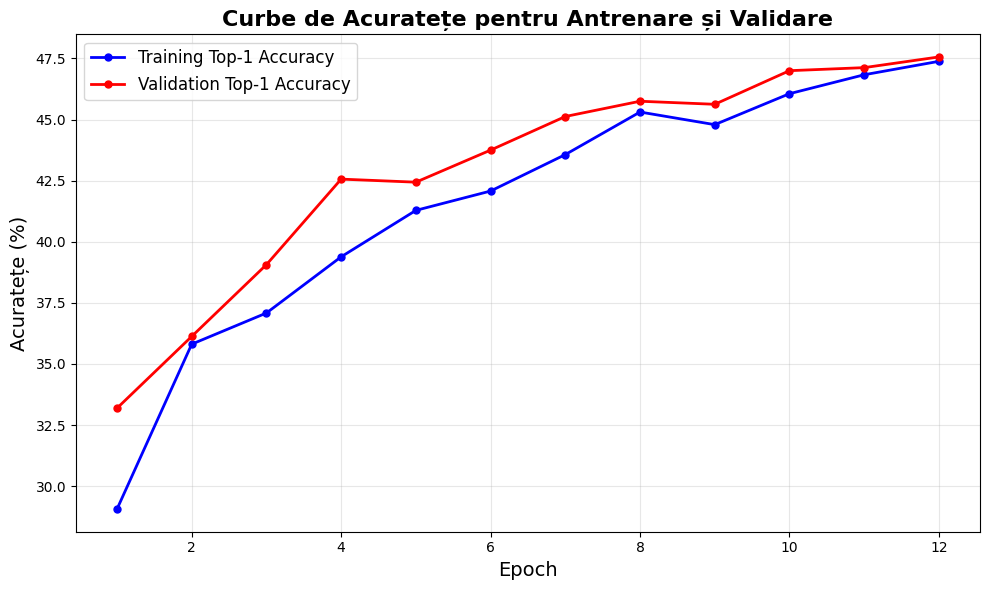

100%|██████████| 375/375 [00:15<00:00, 23.44it/s, epoch=13, train_loss=1.6266, top1_accuracy=48.06%]
Train - Loss: 1.6266, Top-1: 48.06%
100%|██████████| 50/50 [00:00<00:00, 50.63it/s, epoch=13, val_loss=1.6165, top1_accuracy=48.12%]
Val - Loss: 1.6165, Val - Top-1: 48.12%
Validation accuracy increased (47.562500 → 48.125000). Saving model...
100%|██████████| 375/375 [00:15<00:00, 24.28it/s, epoch=14, train_loss=1.6054, top1_accuracy=49.62%]
Train - Loss: 1.6054, Top-1: 49.62%
100%|██████████| 50/50 [00:01<00:00, 46.56it/s, epoch=14, val_loss=1.6056, top1_accuracy=48.69%]
Val - Loss: 1.6056, Val - Top-1: 48.69%
Validation accuracy increased (48.125000 → 48.687500). Saving model...
100%|██████████| 375/375 [00:17<00:00, 21.29it/s, epoch=15, train_loss=1.5935, top1_accuracy=49.35%]
Train - Loss: 1.5935, Top-1: 49.35%
100%|██████████| 50/50 [00:01<00:00, 41.55it/s, epoch=15, val_loss=1.6129, top1_accuracy=48.88%]
Val - Loss: 1.6129, Val - Top-1: 48.88%
Validation accuracy increased (48.68

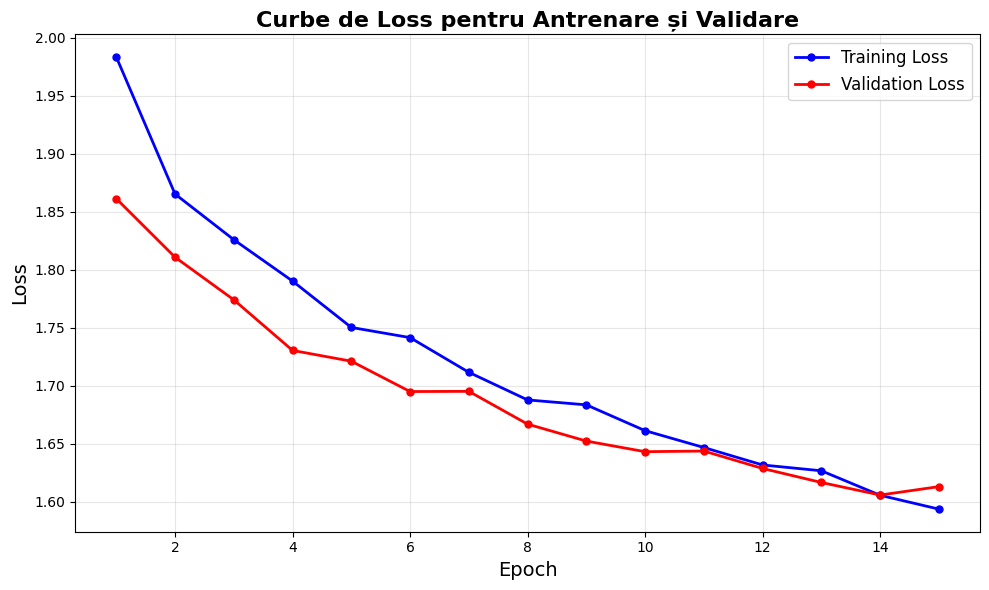

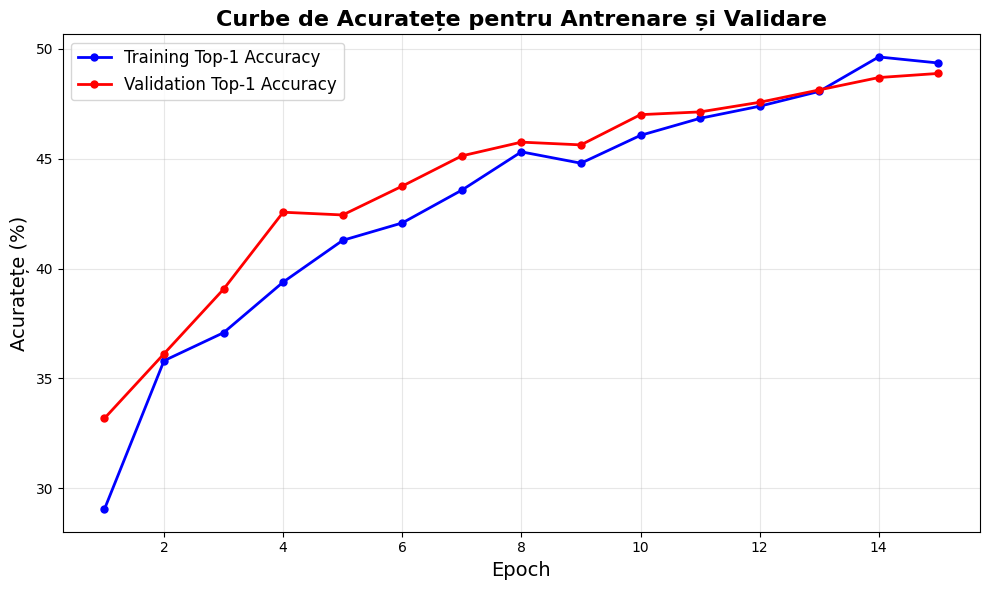

100%|██████████| 375/375 [00:16<00:00, 22.47it/s, epoch=16, train_loss=1.5871, top1_accuracy=50.05%]
Train - Loss: 1.5871, Top-1: 50.05%
100%|██████████| 50/50 [00:01<00:00, 42.40it/s, epoch=16, val_loss=1.6031, top1_accuracy=49.19%]
Val - Loss: 1.6031, Val - Top-1: 49.19%
Validation accuracy increased (48.875000 → 49.187500). Saving model...
100%|██████████| 375/375 [00:15<00:00, 23.86it/s, epoch=17, train_loss=1.5771, top1_accuracy=50.99%]
Train - Loss: 1.5771, Top-1: 50.99%
100%|██████████| 50/50 [00:00<00:00, 52.78it/s, epoch=17, val_loss=1.5988, top1_accuracy=51.25%]
Val - Loss: 1.5988, Val - Top-1: 51.25%
Validation accuracy increased (49.187500 → 51.250000). Saving model...
100%|██████████| 375/375 [00:15<00:00, 24.59it/s, epoch=18, train_loss=1.5577, top1_accuracy=51.30%]
Train - Loss: 1.5577, Top-1: 51.30%
100%|██████████| 50/50 [00:00<00:00, 60.00it/s, epoch=18, val_loss=1.5983, top1_accuracy=49.56%]
Val - Loss: 1.5983, Val - Top-1: 49.56%
EarlyStopping counter: 1 out of 7


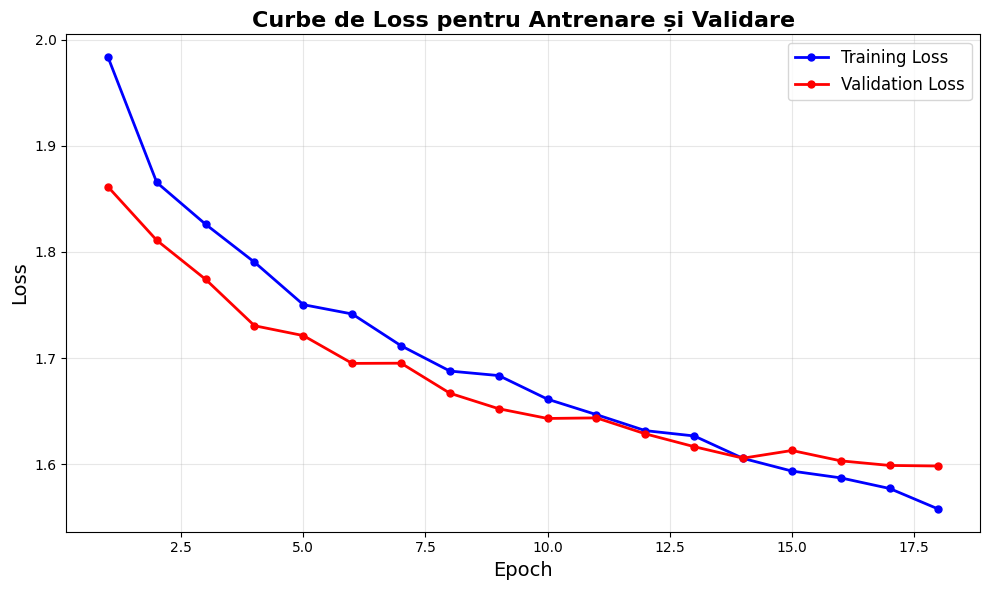

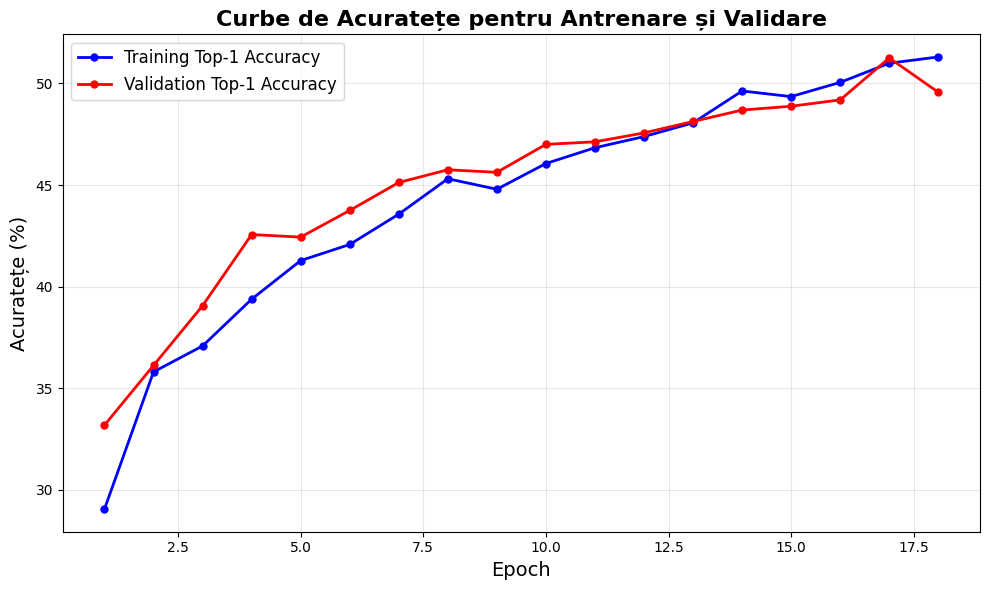

100%|██████████| 375/375 [00:16<00:00, 22.82it/s, epoch=19, train_loss=1.5606, top1_accuracy=51.02%]
Train - Loss: 1.5606, Top-1: 51.02%
100%|██████████| 50/50 [00:00<00:00, 52.56it/s, epoch=19, val_loss=1.5972, top1_accuracy=51.25%]
Val - Loss: 1.5972, Val - Top-1: 51.25%
EarlyStopping counter: 2 out of 7
100%|██████████| 375/375 [00:15<00:00, 24.19it/s, epoch=20, train_loss=1.5458, top1_accuracy=51.62%]
Train - Loss: 1.5458, Top-1: 51.62%
100%|██████████| 50/50 [00:01<00:00, 46.08it/s, epoch=20, val_loss=1.5990, top1_accuracy=50.00%]
Val - Loss: 1.5990, Val - Top-1: 50.00%
EarlyStopping counter: 3 out of 7
100%|██████████| 375/375 [00:15<00:00, 24.64it/s, epoch=21, train_loss=1.5395, top1_accuracy=52.73%]
Train - Loss: 1.5395, Top-1: 52.73%
100%|██████████| 50/50 [00:01<00:00, 49.81it/s, epoch=21, val_loss=1.5939, top1_accuracy=49.69%]
Val - Loss: 1.5939, Val - Top-1: 49.69%
EarlyStopping counter: 4 out of 7


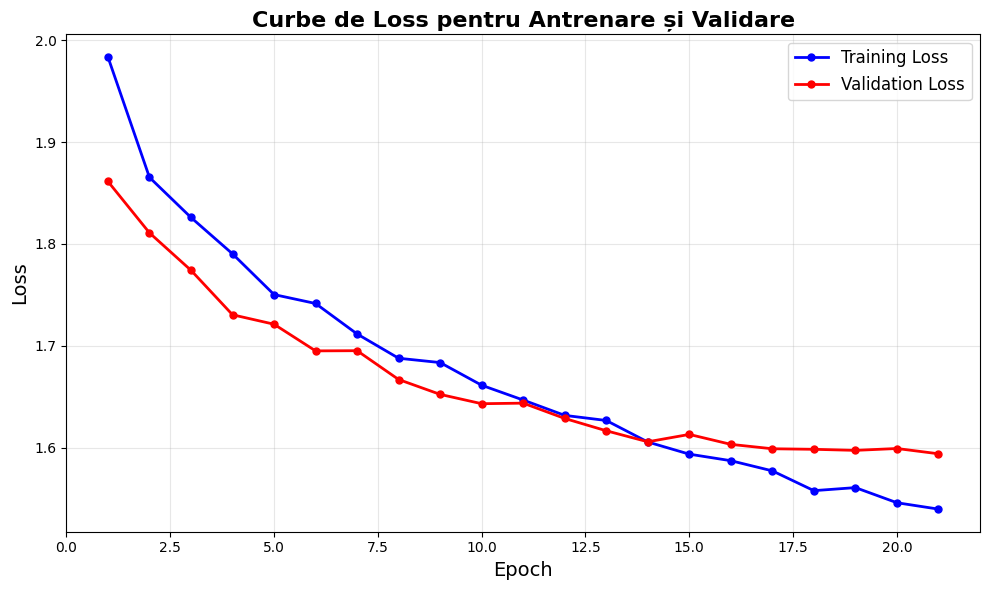

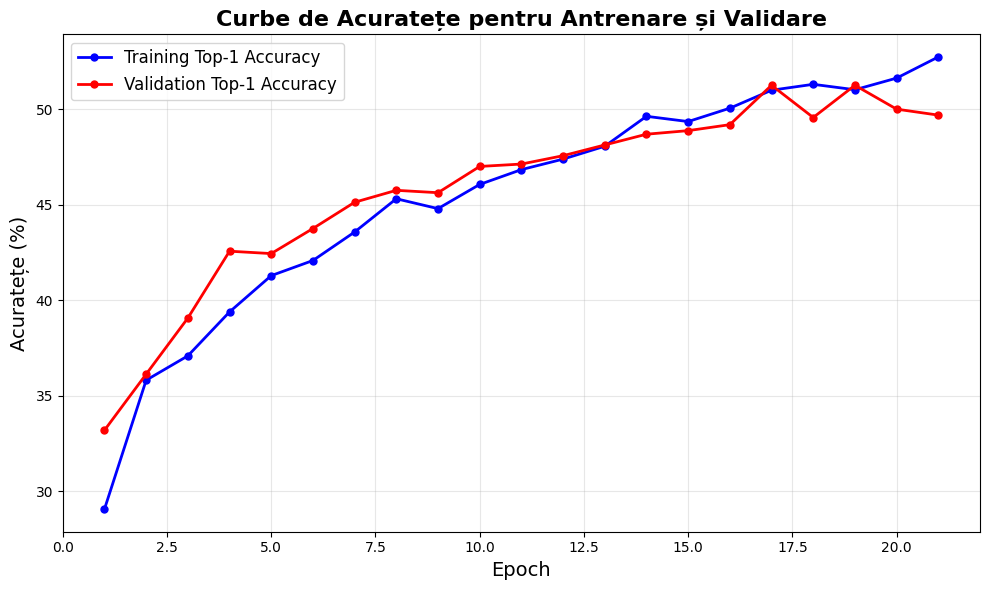

100%|██████████| 375/375 [00:16<00:00, 22.84it/s, epoch=22, train_loss=1.5305, top1_accuracy=53.06%]
Train - Loss: 1.5305, Top-1: 53.06%
100%|██████████| 50/50 [00:00<00:00, 51.79it/s, epoch=22, val_loss=1.5871, top1_accuracy=49.00%]
Val - Loss: 1.5871, Val - Top-1: 49.00%
EarlyStopping counter: 5 out of 7
100%|██████████| 375/375 [00:15<00:00, 24.16it/s, epoch=23, train_loss=1.5260, top1_accuracy=52.82%]
Train - Loss: 1.5260, Top-1: 52.82%
100%|██████████| 50/50 [00:00<00:00, 51.36it/s, epoch=23, val_loss=1.5924, top1_accuracy=50.12%]
Val - Loss: 1.5924, Val - Top-1: 50.12%
EarlyStopping counter: 6 out of 7
100%|██████████| 375/375 [00:15<00:00, 24.20it/s, epoch=24, train_loss=1.5276, top1_accuracy=52.72%]
Train - Loss: 1.5276, Top-1: 52.72%
100%|██████████| 50/50 [00:00<00:00, 50.62it/s, epoch=24, val_loss=1.5761, top1_accuracy=50.88%]
Val - Loss: 1.5761, Val - Top-1: 50.88%
EarlyStopping counter: 7 out of 7
Early stopping triggered at epoch 24

Model 4 Best Validation Accuracy: 51.2

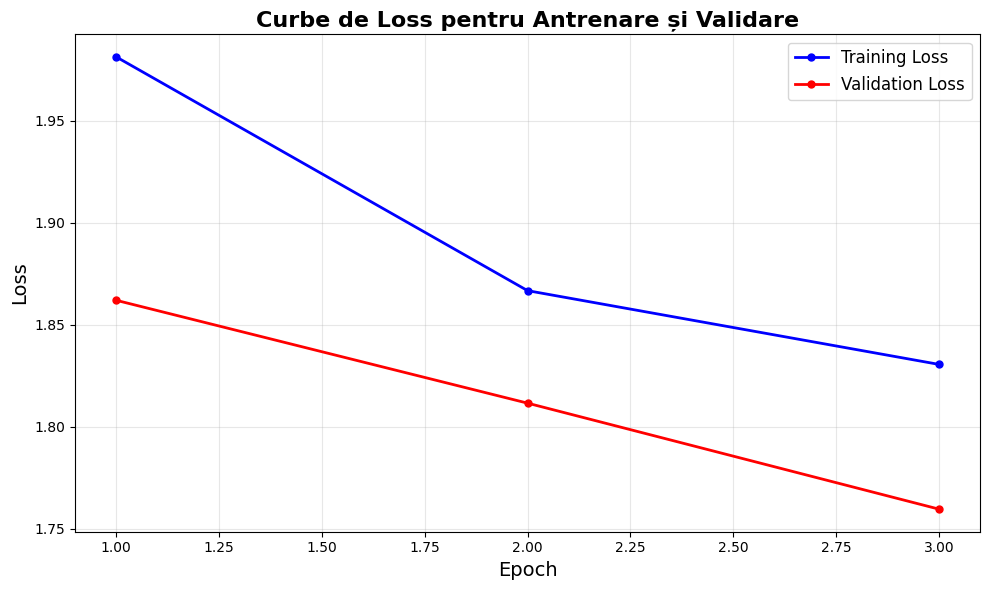

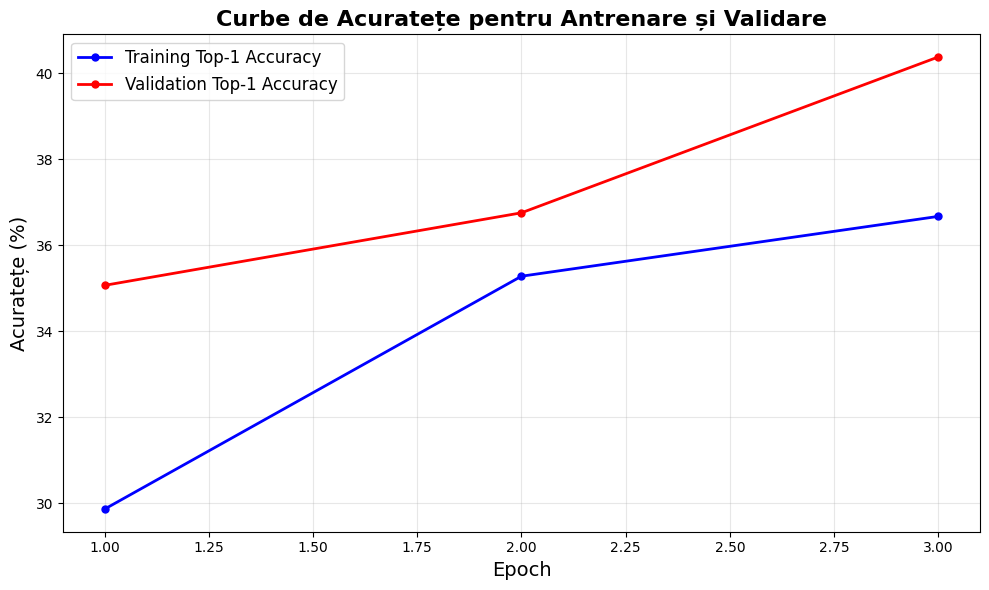

100%|██████████| 375/375 [00:18<00:00, 20.80it/s, epoch=4, train_loss=1.7878, top1_accuracy=39.21%]
Train - Loss: 1.7878, Top-1: 39.21%
100%|██████████| 50/50 [00:01<00:00, 48.24it/s, epoch=4, val_loss=1.7250, top1_accuracy=42.25%]
Val - Loss: 1.7250, Val - Top-1: 42.25%
Validation accuracy increased (40.375000 → 42.250000). Saving model...
100%|██████████| 375/375 [00:16<00:00, 23.02it/s, epoch=5, train_loss=1.7558, top1_accuracy=41.12%]
Train - Loss: 1.7558, Top-1: 41.12%
100%|██████████| 50/50 [00:01<00:00, 46.13it/s, epoch=5, val_loss=1.7240, top1_accuracy=43.12%]
Val - Loss: 1.7240, Val - Top-1: 43.12%
Validation accuracy increased (42.250000 → 43.125000). Saving model...
100%|██████████| 375/375 [00:16<00:00, 23.35it/s, epoch=6, train_loss=1.7385, top1_accuracy=42.33%]
Train - Loss: 1.7385, Top-1: 42.33%
100%|██████████| 50/50 [00:01<00:00, 46.71it/s, epoch=6, val_loss=1.6926, top1_accuracy=44.31%]
Val - Loss: 1.6926, Val - Top-1: 44.31%
Validation accuracy increased (43.125000 →

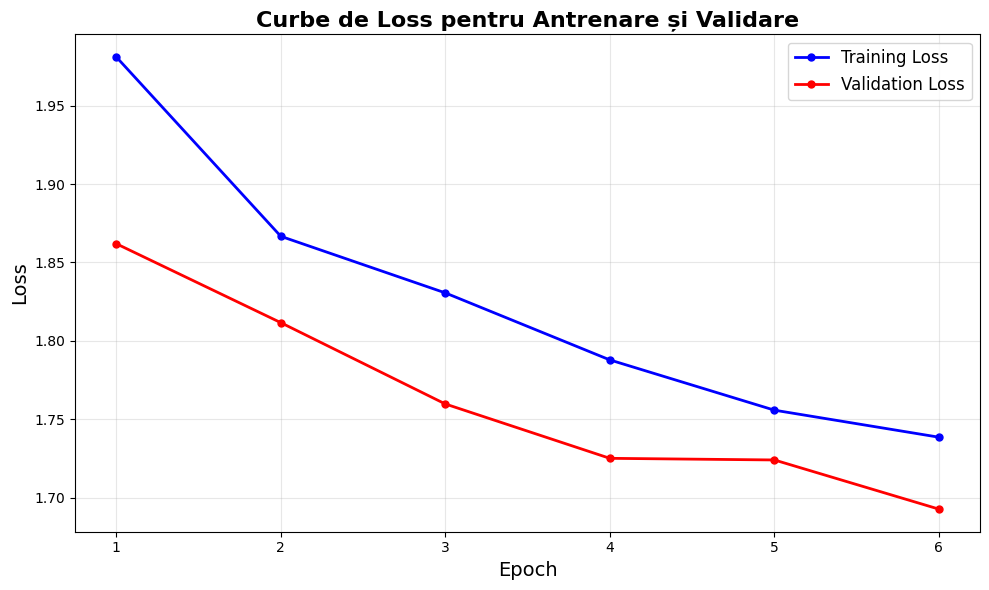

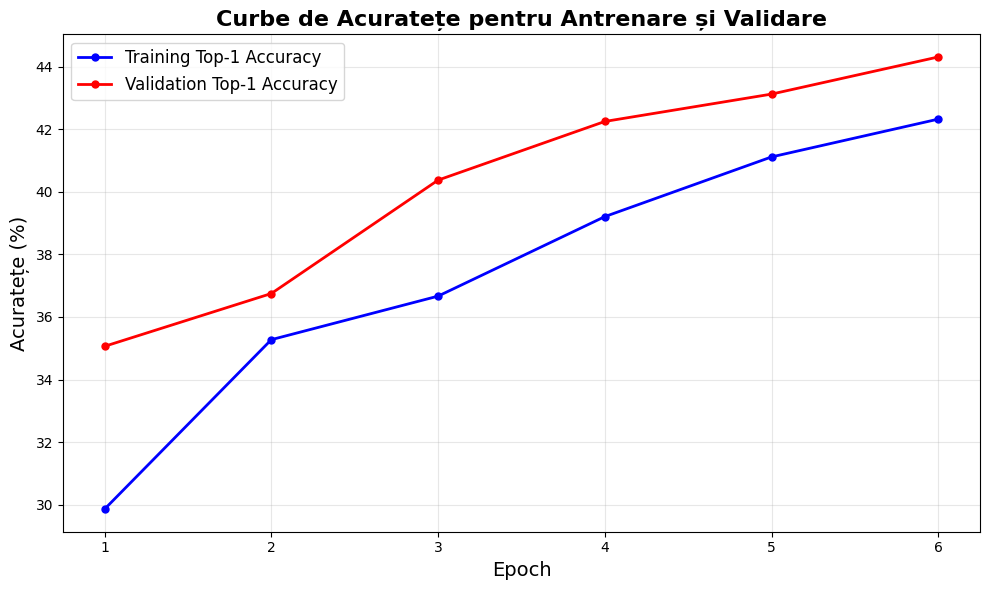

100%|██████████| 375/375 [00:16<00:00, 22.58it/s, epoch=7, train_loss=1.7142, top1_accuracy=43.71%]
Train - Loss: 1.7142, Top-1: 43.71%
100%|██████████| 50/50 [00:00<00:00, 53.68it/s, epoch=7, val_loss=1.6762, top1_accuracy=43.88%]
Val - Loss: 1.6762, Val - Top-1: 43.88%
EarlyStopping counter: 1 out of 7
100%|██████████| 375/375 [00:15<00:00, 24.39it/s, epoch=8, train_loss=1.6867, top1_accuracy=44.97%]
Train - Loss: 1.6867, Top-1: 44.97%
100%|██████████| 50/50 [00:00<00:00, 56.68it/s, epoch=8, val_loss=1.6698, top1_accuracy=44.69%]
Val - Loss: 1.6698, Val - Top-1: 44.69%
Validation accuracy increased (44.312500 → 44.687500). Saving model...
100%|██████████| 375/375 [00:14<00:00, 25.13it/s, epoch=9, train_loss=1.6912, top1_accuracy=44.68%]
Train - Loss: 1.6912, Top-1: 44.68%
100%|██████████| 50/50 [00:01<00:00, 44.24it/s, epoch=9, val_loss=1.6588, top1_accuracy=46.38%]
Val - Loss: 1.6588, Val - Top-1: 46.38%
Validation accuracy increased (44.687500 → 46.375000). Saving model...


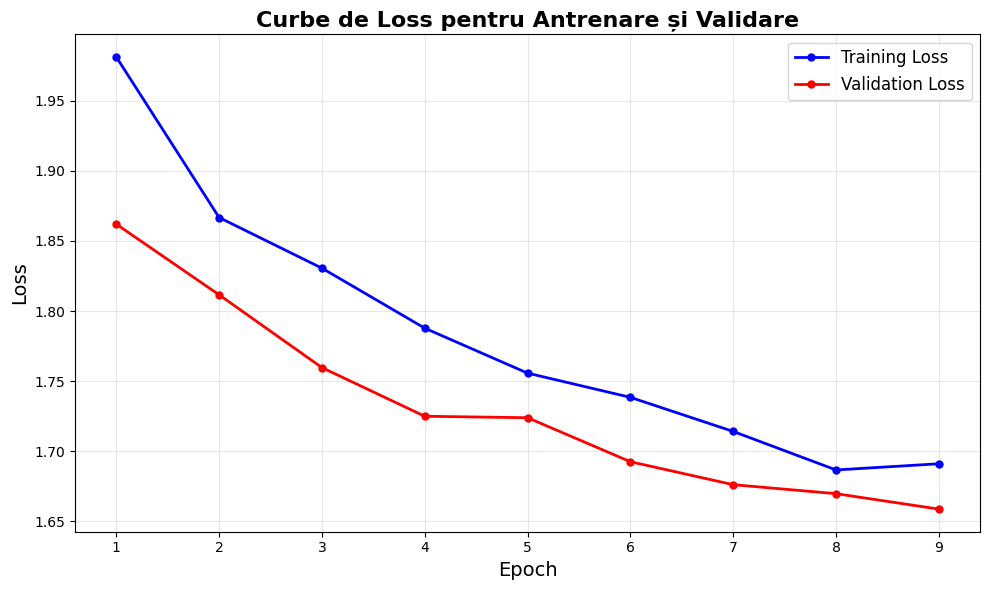

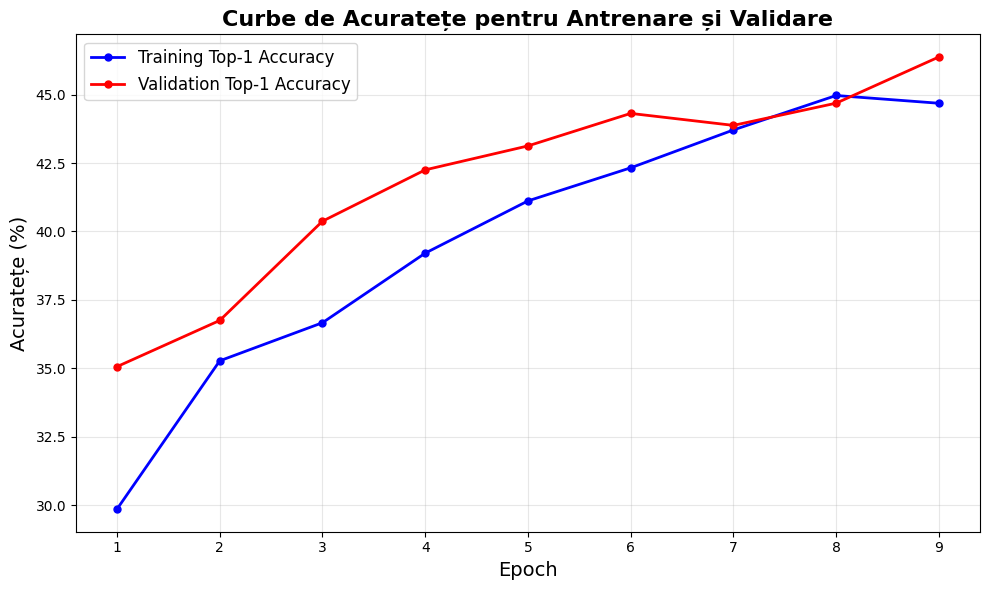

100%|██████████| 375/375 [00:19<00:00, 19.29it/s, epoch=10, train_loss=1.6554, top1_accuracy=46.56%]
Train - Loss: 1.6554, Top-1: 46.56%
100%|██████████| 50/50 [00:01<00:00, 44.69it/s, epoch=10, val_loss=1.6322, top1_accuracy=47.69%]
Val - Loss: 1.6322, Val - Top-1: 47.69%
Validation accuracy increased (46.375000 → 47.687500). Saving model...
100%|██████████| 375/375 [00:16<00:00, 23.39it/s, epoch=11, train_loss=1.6502, top1_accuracy=46.64%]
Train - Loss: 1.6502, Top-1: 46.64%
100%|██████████| 50/50 [00:01<00:00, 44.11it/s, epoch=11, val_loss=1.6361, top1_accuracy=46.75%]
Val - Loss: 1.6361, Val - Top-1: 46.75%
EarlyStopping counter: 1 out of 7
100%|██████████| 375/375 [00:15<00:00, 23.66it/s, epoch=12, train_loss=1.6326, top1_accuracy=47.72%]
Train - Loss: 1.6326, Top-1: 47.72%
100%|██████████| 50/50 [00:00<00:00, 56.56it/s, epoch=12, val_loss=1.6359, top1_accuracy=47.50%]
Val - Loss: 1.6359, Val - Top-1: 47.50%
EarlyStopping counter: 2 out of 7


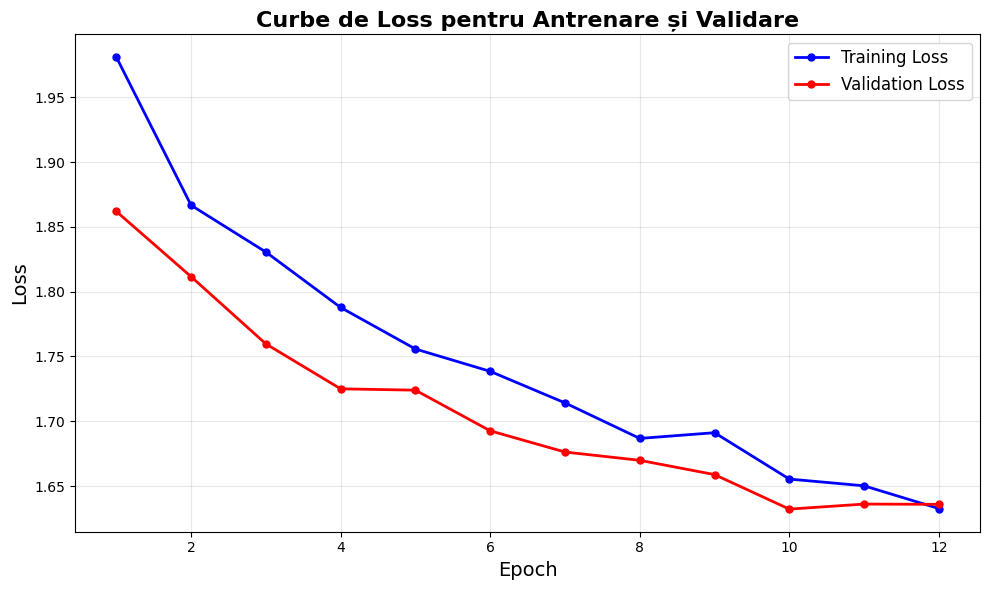

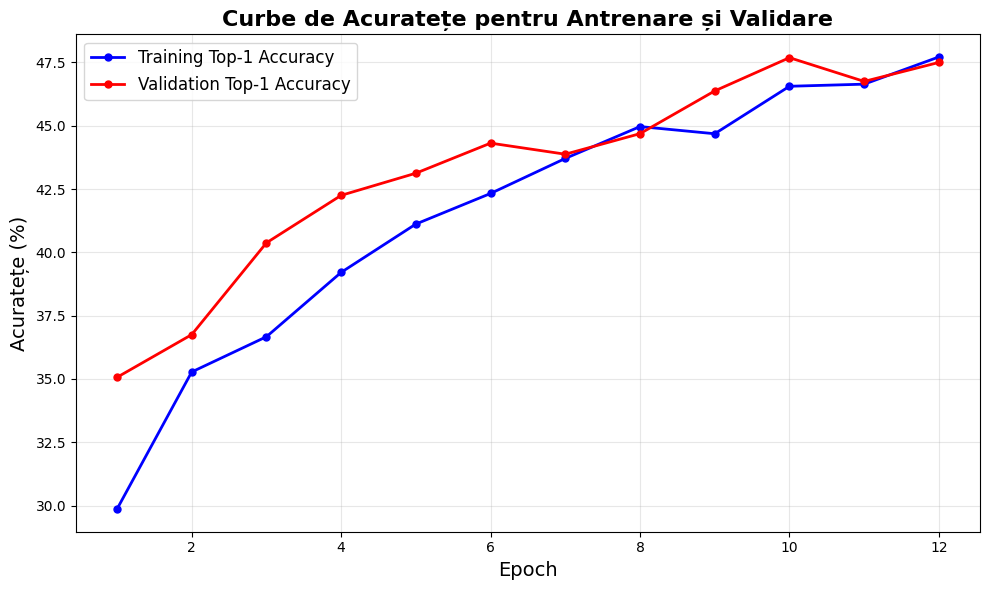

100%|██████████| 375/375 [00:16<00:00, 22.72it/s, epoch=13, train_loss=1.6254, top1_accuracy=48.41%]
Train - Loss: 1.6254, Top-1: 48.41%
100%|██████████| 50/50 [00:00<00:00, 56.96it/s, epoch=13, val_loss=1.6263, top1_accuracy=47.88%]
Val - Loss: 1.6263, Val - Top-1: 47.88%
Validation accuracy increased (47.687500 → 47.875000). Saving model...
100%|██████████| 375/375 [00:15<00:00, 24.72it/s, epoch=14, train_loss=1.6030, top1_accuracy=49.21%]
Train - Loss: 1.6030, Top-1: 49.21%
100%|██████████| 50/50 [00:00<00:00, 58.70it/s, epoch=14, val_loss=1.6109, top1_accuracy=48.81%]
Val - Loss: 1.6109, Val - Top-1: 48.81%
Validation accuracy increased (47.875000 → 48.812500). Saving model...
100%|██████████| 375/375 [00:15<00:00, 24.82it/s, epoch=15, train_loss=1.5955, top1_accuracy=49.81%]
Train - Loss: 1.5955, Top-1: 49.81%
100%|██████████| 50/50 [00:00<00:00, 59.35it/s, epoch=15, val_loss=1.6146, top1_accuracy=49.00%]
Val - Loss: 1.6146, Val - Top-1: 49.00%
Validation accuracy increased (48.81

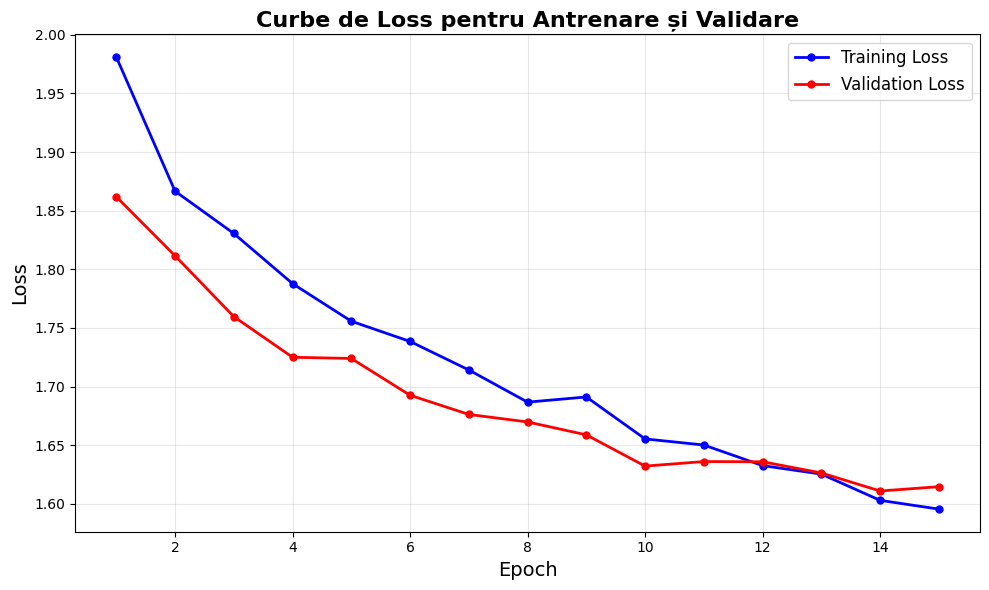

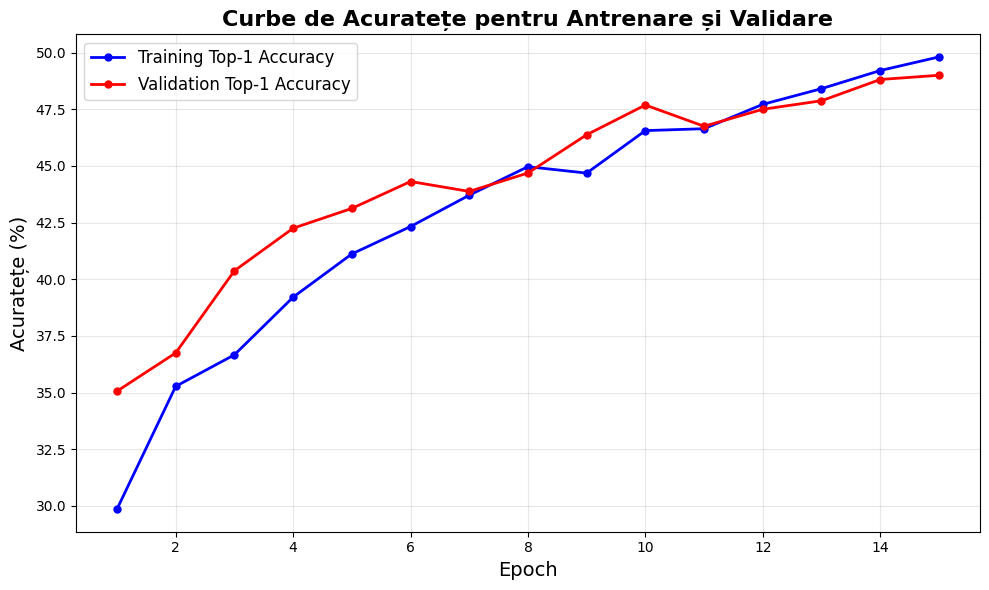

100%|██████████| 375/375 [00:16<00:00, 23.05it/s, epoch=16, train_loss=1.5939, top1_accuracy=50.14%]
Train - Loss: 1.5939, Top-1: 50.14%
100%|██████████| 50/50 [00:00<00:00, 54.32it/s, epoch=16, val_loss=1.6190, top1_accuracy=49.25%]
Val - Loss: 1.6190, Val - Top-1: 49.25%
Validation accuracy increased (49.000000 → 49.250000). Saving model...
100%|██████████| 375/375 [00:15<00:00, 24.80it/s, epoch=17, train_loss=1.5799, top1_accuracy=50.61%]
Train - Loss: 1.5799, Top-1: 50.61%
100%|██████████| 50/50 [00:00<00:00, 58.79it/s, epoch=17, val_loss=1.6154, top1_accuracy=49.44%]
Val - Loss: 1.6154, Val - Top-1: 49.44%
Validation accuracy increased (49.250000 → 49.437500). Saving model...
100%|██████████| 375/375 [00:15<00:00, 24.98it/s, epoch=18, train_loss=1.5657, top1_accuracy=51.05%]
Train - Loss: 1.5657, Top-1: 51.05%
100%|██████████| 50/50 [00:00<00:00, 57.47it/s, epoch=18, val_loss=1.5999, top1_accuracy=50.00%]
Val - Loss: 1.5999, Val - Top-1: 50.00%
Validation accuracy increased (49.43

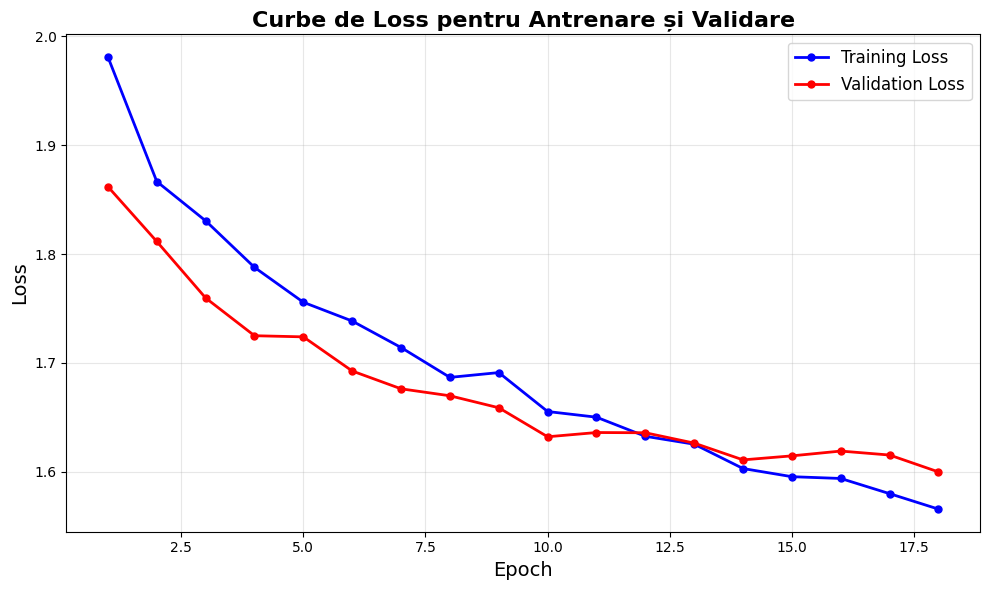

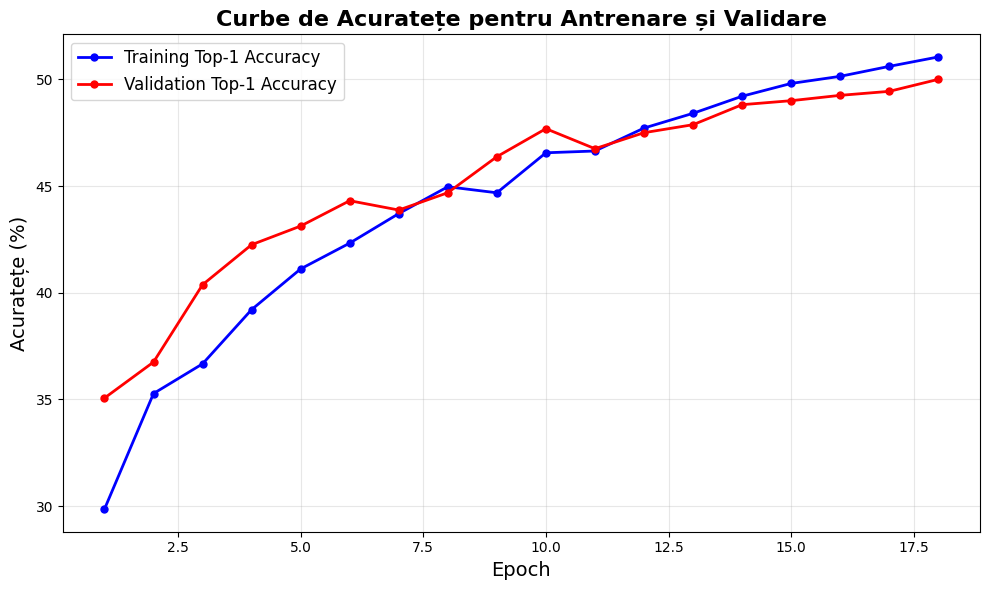

100%|██████████| 375/375 [00:16<00:00, 23.12it/s, epoch=19, train_loss=1.5663, top1_accuracy=50.61%]
Train - Loss: 1.5663, Top-1: 50.61%
100%|██████████| 50/50 [00:00<00:00, 59.42it/s, epoch=19, val_loss=1.5969, top1_accuracy=50.44%]
Val - Loss: 1.5969, Val - Top-1: 50.44%
Validation accuracy increased (50.000000 → 50.437500). Saving model...
100%|██████████| 375/375 [00:14<00:00, 25.93it/s, epoch=20, train_loss=1.5543, top1_accuracy=51.71%]
Train - Loss: 1.5543, Top-1: 51.71%
100%|██████████| 50/50 [00:00<00:00, 58.99it/s, epoch=20, val_loss=1.5966, top1_accuracy=50.25%]
Val - Loss: 1.5966, Val - Top-1: 50.25%
EarlyStopping counter: 1 out of 7
100%|██████████| 375/375 [00:14<00:00, 25.08it/s, epoch=21, train_loss=1.5466, top1_accuracy=51.89%]
Train - Loss: 1.5466, Top-1: 51.89%
100%|██████████| 50/50 [00:00<00:00, 62.88it/s, epoch=21, val_loss=1.5952, top1_accuracy=50.44%]
Val - Loss: 1.5952, Val - Top-1: 50.44%
EarlyStopping counter: 2 out of 7


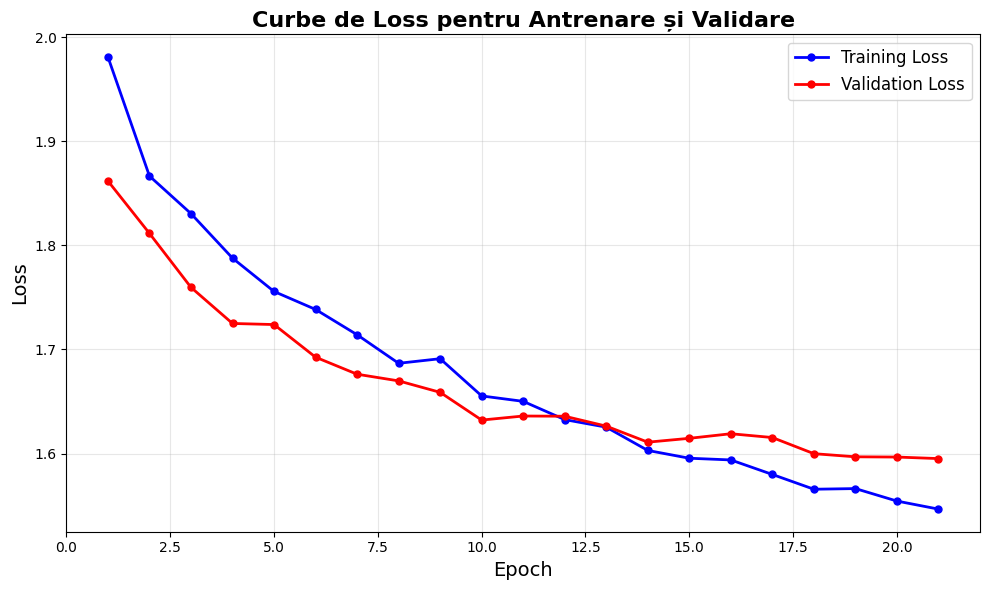

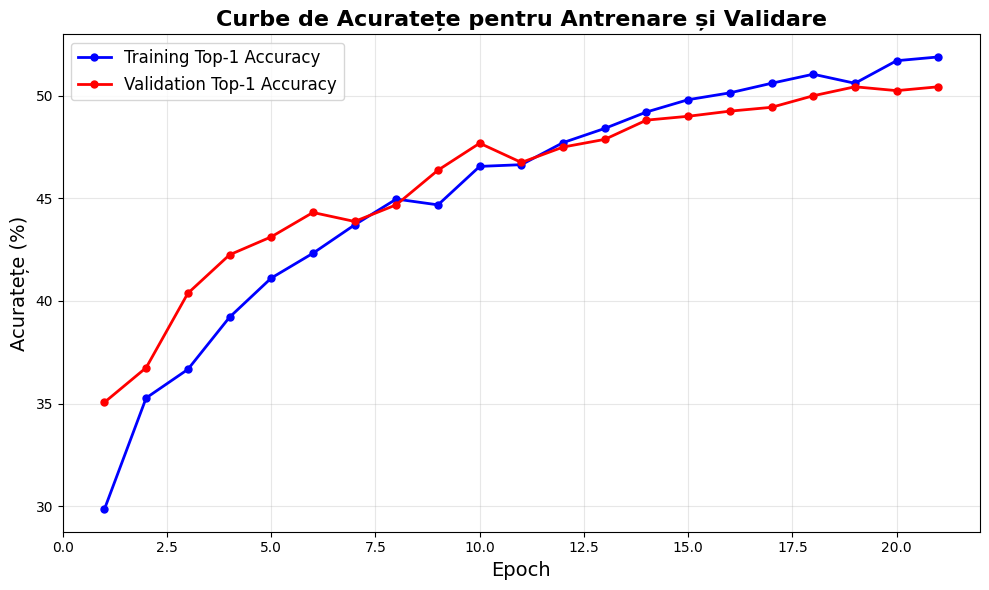

100%|██████████| 375/375 [00:14<00:00, 25.61it/s, epoch=22, train_loss=1.5397, top1_accuracy=52.62%]
Train - Loss: 1.5397, Top-1: 52.62%
100%|██████████| 50/50 [00:00<00:00, 63.85it/s, epoch=22, val_loss=1.5926, top1_accuracy=49.69%]
Val - Loss: 1.5926, Val - Top-1: 49.69%
EarlyStopping counter: 3 out of 7
100%|██████████| 375/375 [00:14<00:00, 26.20it/s, epoch=23, train_loss=1.5331, top1_accuracy=52.65%]
Train - Loss: 1.5331, Top-1: 52.65%
100%|██████████| 50/50 [00:00<00:00, 61.85it/s, epoch=23, val_loss=1.5913, top1_accuracy=50.50%]
Val - Loss: 1.5913, Val - Top-1: 50.50%
Validation accuracy increased (50.437500 → 50.500000). Saving model...
100%|██████████| 375/375 [00:14<00:00, 26.10it/s, epoch=24, train_loss=1.5250, top1_accuracy=53.33%]
Train - Loss: 1.5250, Top-1: 53.33%
100%|██████████| 50/50 [00:00<00:00, 63.72it/s, epoch=24, val_loss=1.5886, top1_accuracy=51.19%]
Val - Loss: 1.5886, Val - Top-1: 51.19%
Validation accuracy increased (50.500000 → 51.187500). Saving model...


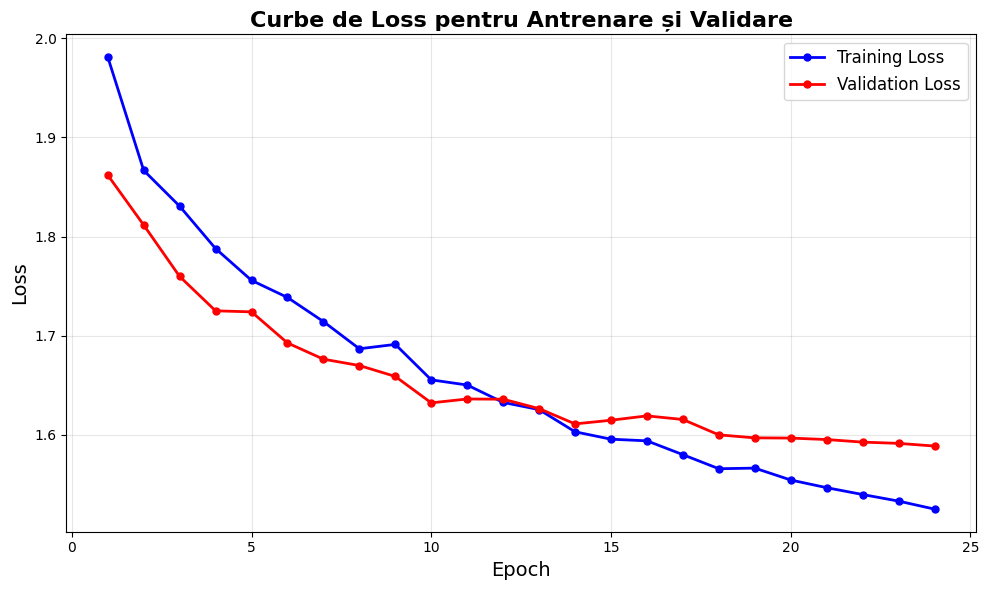

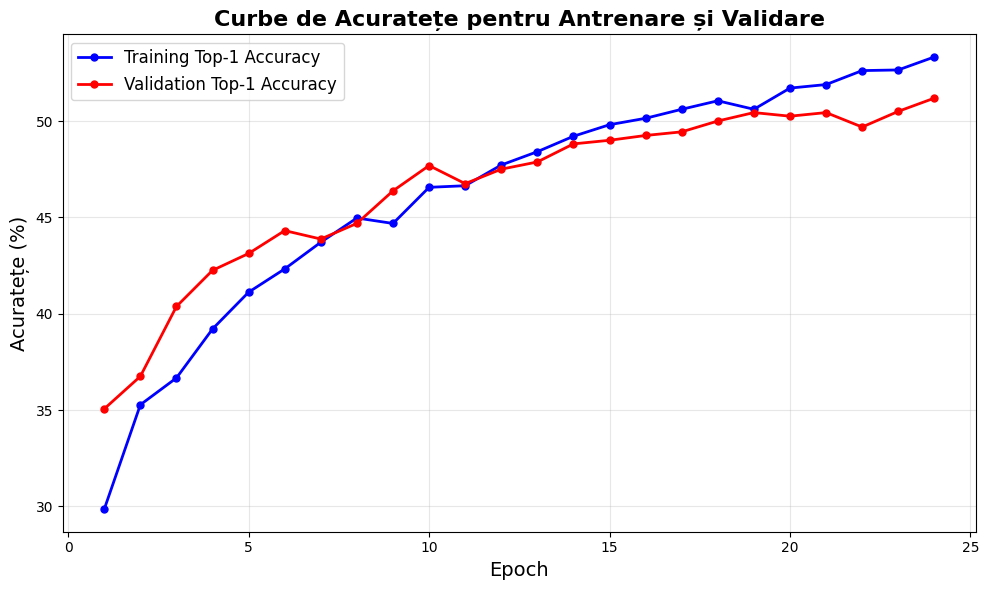

100%|██████████| 375/375 [00:14<00:00, 25.12it/s, epoch=25, train_loss=1.5220, top1_accuracy=53.49%]
Train - Loss: 1.5220, Top-1: 53.49%
100%|██████████| 50/50 [00:00<00:00, 58.99it/s, epoch=25, val_loss=1.5809, top1_accuracy=50.69%]
Val - Loss: 1.5809, Val - Top-1: 50.69%
EarlyStopping counter: 1 out of 7
100%|██████████| 375/375 [00:14<00:00, 25.97it/s, epoch=26, train_loss=1.5147, top1_accuracy=53.62%]
Train - Loss: 1.5147, Top-1: 53.62%
100%|██████████| 50/50 [00:00<00:00, 64.31it/s, epoch=26, val_loss=1.5844, top1_accuracy=50.88%]
Val - Loss: 1.5844, Val - Top-1: 50.88%
EarlyStopping counter: 2 out of 7
100%|██████████| 375/375 [00:16<00:00, 22.07it/s, epoch=27, train_loss=1.5163, top1_accuracy=54.04%]
Train - Loss: 1.5163, Top-1: 54.04%
100%|██████████| 50/50 [00:00<00:00, 53.25it/s, epoch=27, val_loss=1.5852, top1_accuracy=51.06%]
Val - Loss: 1.5852, Val - Top-1: 51.06%
EarlyStopping counter: 3 out of 7


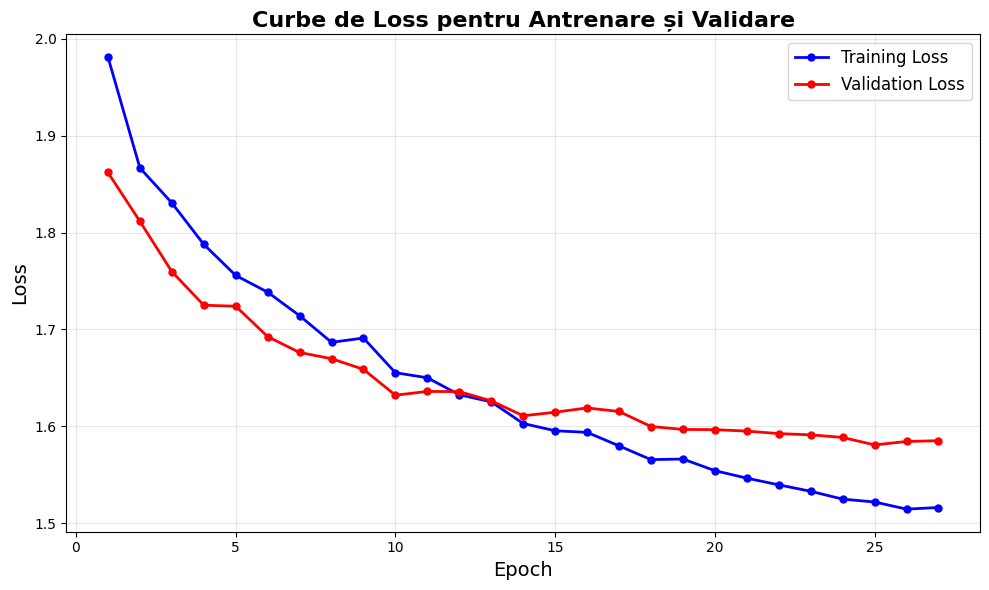

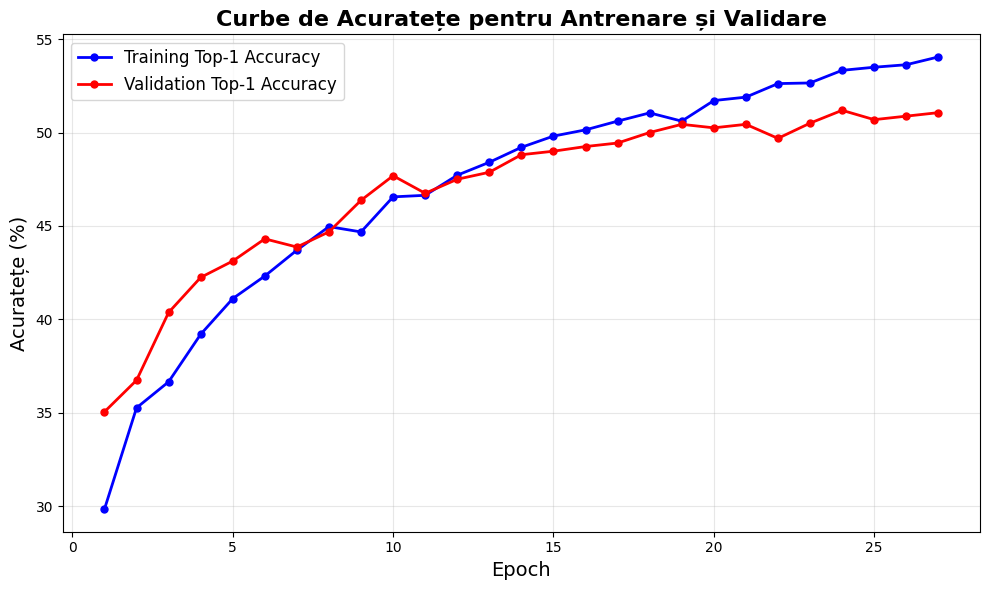

100%|██████████| 375/375 [00:24<00:00, 15.36it/s, epoch=28, train_loss=1.5230, top1_accuracy=52.65%]
Train - Loss: 1.5230, Top-1: 52.65%
100%|██████████| 50/50 [00:00<00:00, 58.62it/s, epoch=28, val_loss=1.5832, top1_accuracy=51.38%]
Val - Loss: 1.5832, Val - Top-1: 51.38%
Validation accuracy increased (51.187500 → 51.375000). Saving model...
100%|██████████| 375/375 [00:14<00:00, 25.68it/s, epoch=29, train_loss=1.5116, top1_accuracy=53.28%]
Train - Loss: 1.5116, Top-1: 53.28%
100%|██████████| 50/50 [00:00<00:00, 64.41it/s, epoch=29, val_loss=1.5847, top1_accuracy=51.06%]
Val - Loss: 1.5847, Val - Top-1: 51.06%
EarlyStopping counter: 1 out of 7
100%|██████████| 375/375 [00:15<00:00, 24.02it/s, epoch=30, train_loss=1.4985, top1_accuracy=54.42%]
Train - Loss: 1.4985, Top-1: 54.42%
100%|██████████| 50/50 [00:01<00:00, 44.60it/s, epoch=30, val_loss=1.5807, top1_accuracy=50.62%]
Val - Loss: 1.5807, Val - Top-1: 50.62%
EarlyStopping counter: 2 out of 7


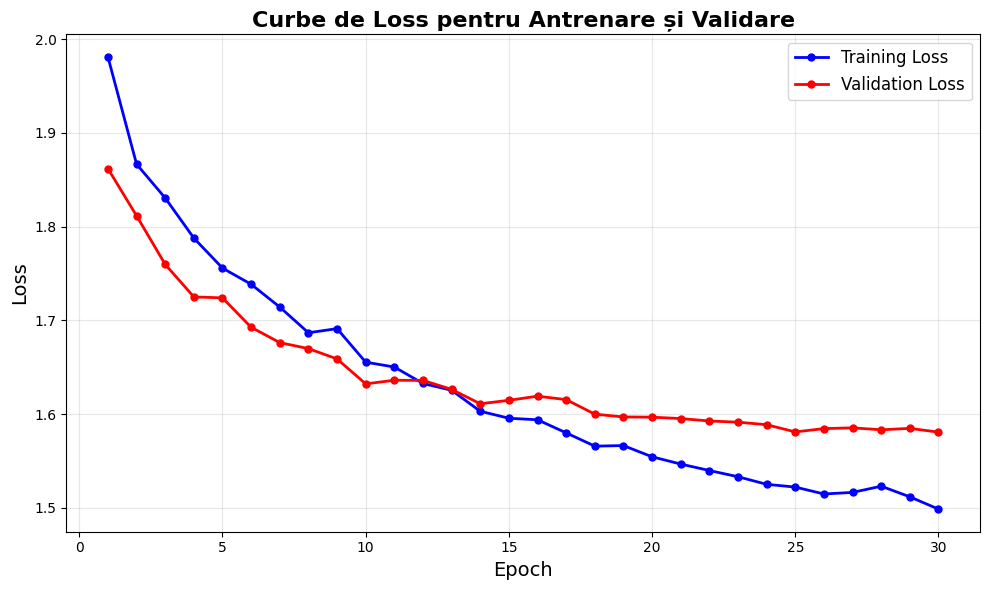

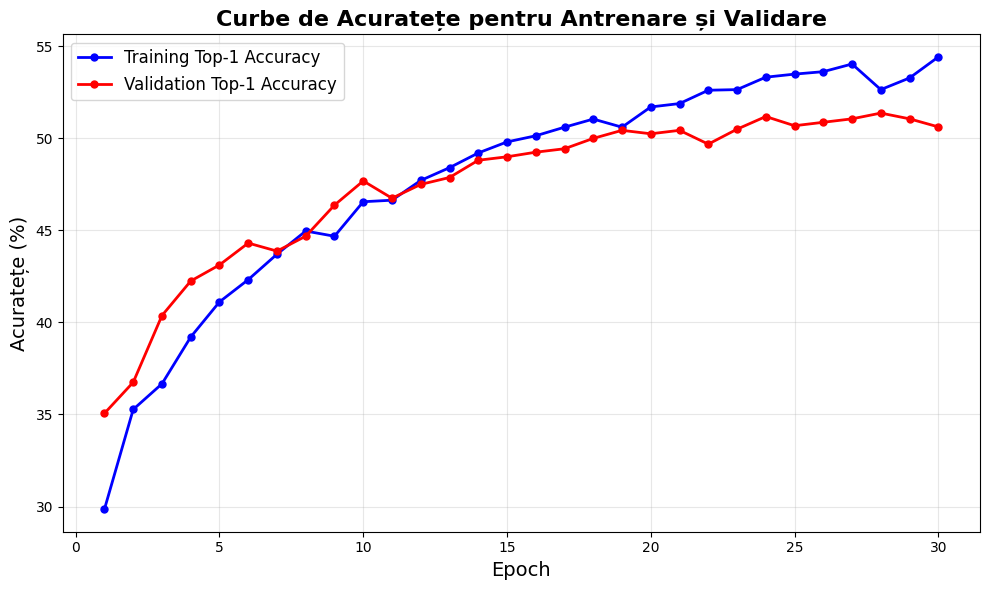

100%|██████████| 375/375 [00:16<00:00, 22.87it/s, epoch=31, train_loss=1.4997, top1_accuracy=54.44%]
Train - Loss: 1.4997, Top-1: 54.44%
100%|██████████| 50/50 [00:01<00:00, 48.91it/s, epoch=31, val_loss=1.5794, top1_accuracy=50.69%]
Val - Loss: 1.5794, Val - Top-1: 50.69%
EarlyStopping counter: 3 out of 7
100%|██████████| 375/375 [00:15<00:00, 24.82it/s, epoch=32, train_loss=1.4977, top1_accuracy=54.70%]
Train - Loss: 1.4977, Top-1: 54.70%
100%|██████████| 50/50 [00:00<00:00, 60.08it/s, epoch=32, val_loss=1.5770, top1_accuracy=51.00%]
Val - Loss: 1.5770, Val - Top-1: 51.00%
EarlyStopping counter: 4 out of 7
100%|██████████| 375/375 [00:14<00:00, 25.25it/s, epoch=33, train_loss=1.4969, top1_accuracy=54.58%]
Train - Loss: 1.4969, Top-1: 54.58%
100%|██████████| 50/50 [00:00<00:00, 66.17it/s, epoch=33, val_loss=1.5794, top1_accuracy=50.56%]
Val - Loss: 1.5794, Val - Top-1: 50.56%
EarlyStopping counter: 5 out of 7


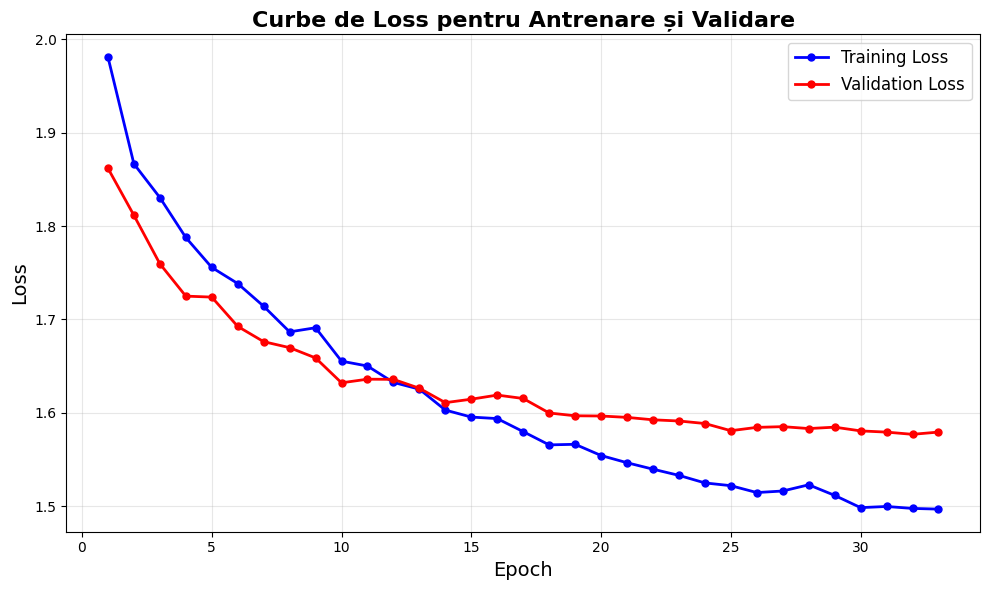

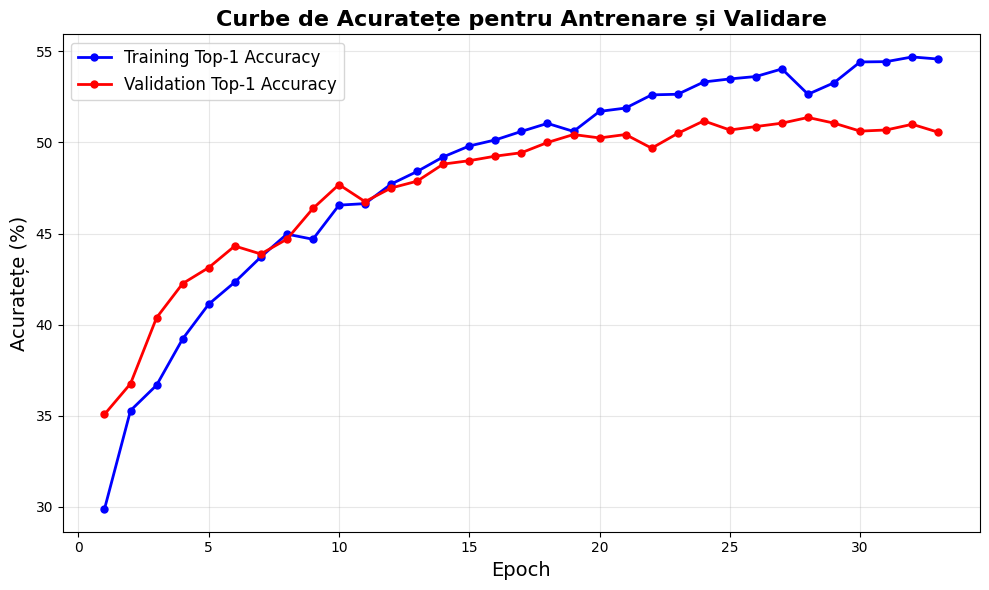

100%|██████████| 375/375 [00:15<00:00, 23.50it/s, epoch=34, train_loss=1.4891, top1_accuracy=55.28%]
Train - Loss: 1.4891, Top-1: 55.28%
100%|██████████| 50/50 [00:00<00:00, 62.41it/s, epoch=34, val_loss=1.5772, top1_accuracy=51.44%]
Val - Loss: 1.5772, Val - Top-1: 51.44%
Validation accuracy increased (51.375000 → 51.437500). Saving model...
100%|██████████| 375/375 [00:15<00:00, 24.64it/s, epoch=35, train_loss=1.4932, top1_accuracy=54.73%]
Train - Loss: 1.4932, Top-1: 54.73%
100%|██████████| 50/50 [00:00<00:00, 51.79it/s, epoch=35, val_loss=1.5838, top1_accuracy=50.94%]
Val - Loss: 1.5838, Val - Top-1: 50.94%
EarlyStopping counter: 1 out of 7
100%|██████████| 375/375 [00:15<00:00, 23.65it/s, epoch=36, train_loss=1.4867, top1_accuracy=55.31%]
Train - Loss: 1.4867, Top-1: 55.31%
100%|██████████| 50/50 [00:01<00:00, 46.92it/s, epoch=36, val_loss=1.5772, top1_accuracy=51.19%]
Val - Loss: 1.5772, Val - Top-1: 51.19%
EarlyStopping counter: 2 out of 7


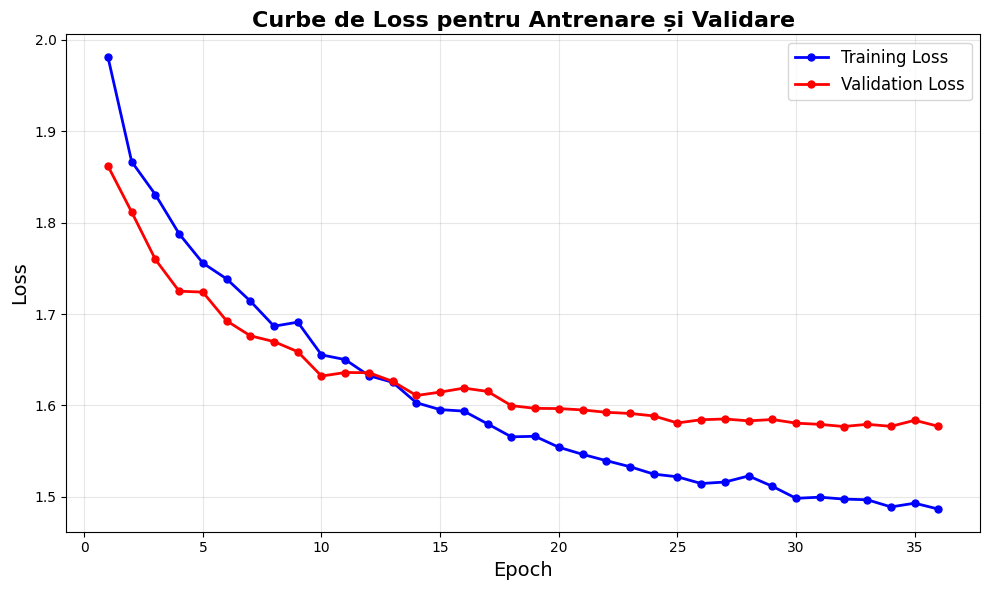

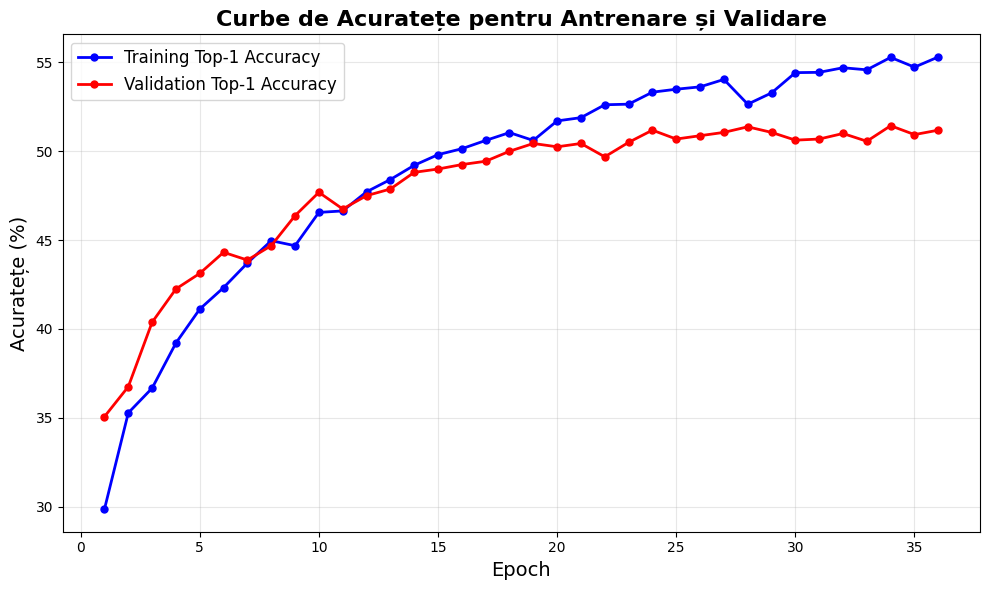

100%|██████████| 375/375 [00:16<00:00, 22.98it/s, epoch=37, train_loss=1.4823, top1_accuracy=55.13%]
Train - Loss: 1.4823, Top-1: 55.13%
100%|██████████| 50/50 [00:01<00:00, 46.05it/s, epoch=37, val_loss=1.5795, top1_accuracy=50.94%]
Val - Loss: 1.5795, Val - Top-1: 50.94%
EarlyStopping counter: 3 out of 7
100%|██████████| 375/375 [00:16<00:00, 22.77it/s, epoch=38, train_loss=1.4898, top1_accuracy=55.12%]
Train - Loss: 1.4898, Top-1: 55.12%
100%|██████████| 50/50 [00:01<00:00, 43.27it/s, epoch=38, val_loss=1.5835, top1_accuracy=50.38%]
Val - Loss: 1.5835, Val - Top-1: 50.38%
EarlyStopping counter: 4 out of 7
100%|██████████| 375/375 [00:15<00:00, 24.75it/s, epoch=39, train_loss=1.4856, top1_accuracy=55.03%]
Train - Loss: 1.4856, Top-1: 55.03%
100%|██████████| 50/50 [00:00<00:00, 63.17it/s, epoch=39, val_loss=1.5750, top1_accuracy=51.44%]
Val - Loss: 1.5750, Val - Top-1: 51.44%
EarlyStopping counter: 5 out of 7


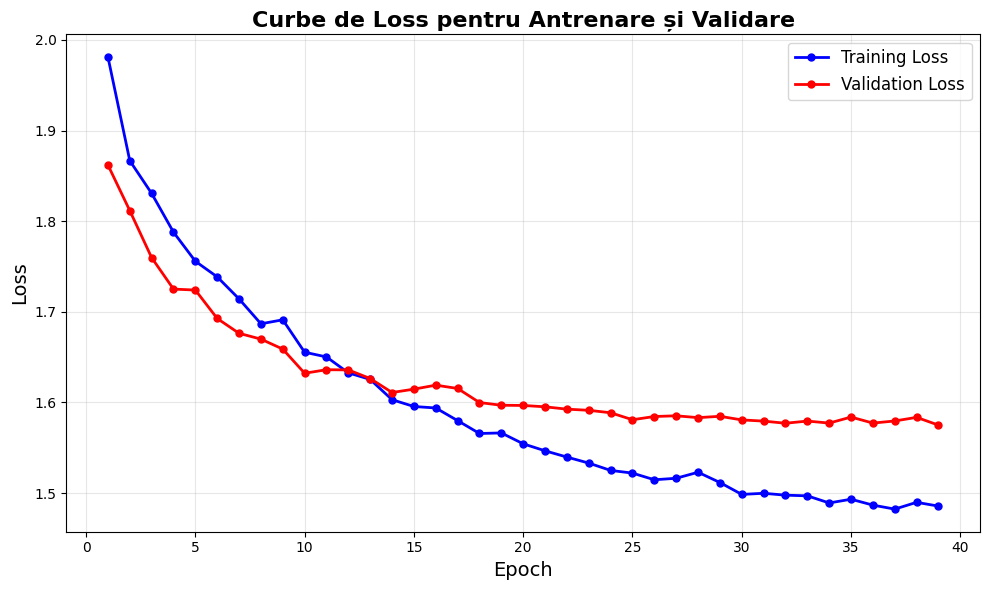

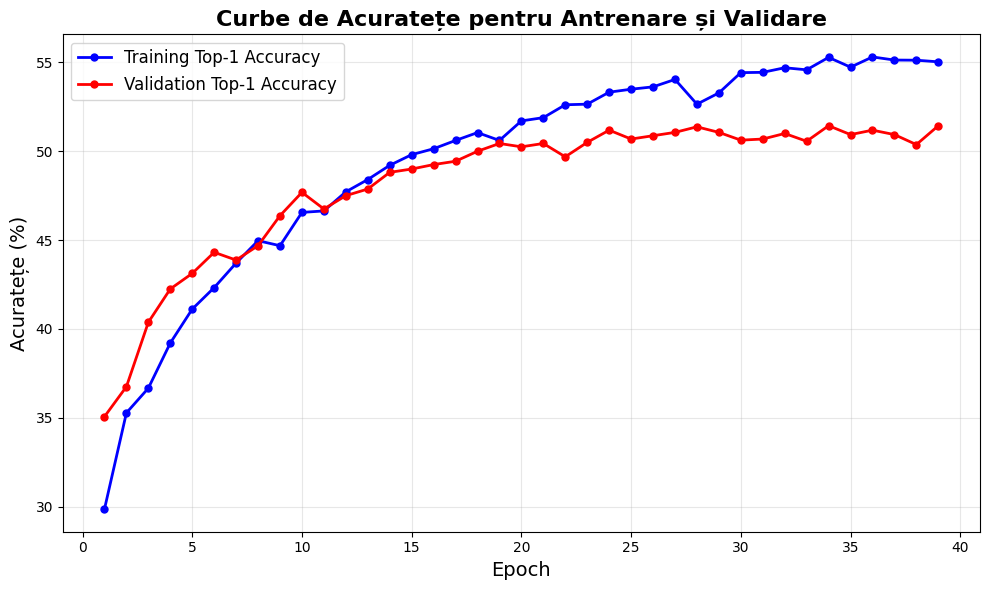

100%|██████████| 375/375 [00:16<00:00, 22.87it/s, epoch=40, train_loss=1.4792, top1_accuracy=55.37%]
Train - Loss: 1.4792, Top-1: 55.37%
100%|██████████| 50/50 [00:00<00:00, 55.07it/s, epoch=40, val_loss=1.5782, top1_accuracy=51.50%]
Val - Loss: 1.5782, Val - Top-1: 51.50%
Validation accuracy increased (51.437500 → 51.500000). Saving model...
100%|██████████| 375/375 [00:16<00:00, 22.68it/s, epoch=41, train_loss=1.4872, top1_accuracy=55.03%]
Train - Loss: 1.4872, Top-1: 55.03%
100%|██████████| 50/50 [00:00<00:00, 51.86it/s, epoch=41, val_loss=1.5827, top1_accuracy=51.25%]
Val - Loss: 1.5827, Val - Top-1: 51.25%
EarlyStopping counter: 1 out of 7
100%|██████████| 375/375 [00:15<00:00, 23.68it/s, epoch=42, train_loss=1.4815, top1_accuracy=55.52%]
Train - Loss: 1.4815, Top-1: 55.52%
100%|██████████| 50/50 [00:00<00:00, 51.32it/s, epoch=42, val_loss=1.5776, top1_accuracy=51.88%]
Val - Loss: 1.5776, Val - Top-1: 51.88%
Validation accuracy increased (51.500000 → 51.875000). Saving model...


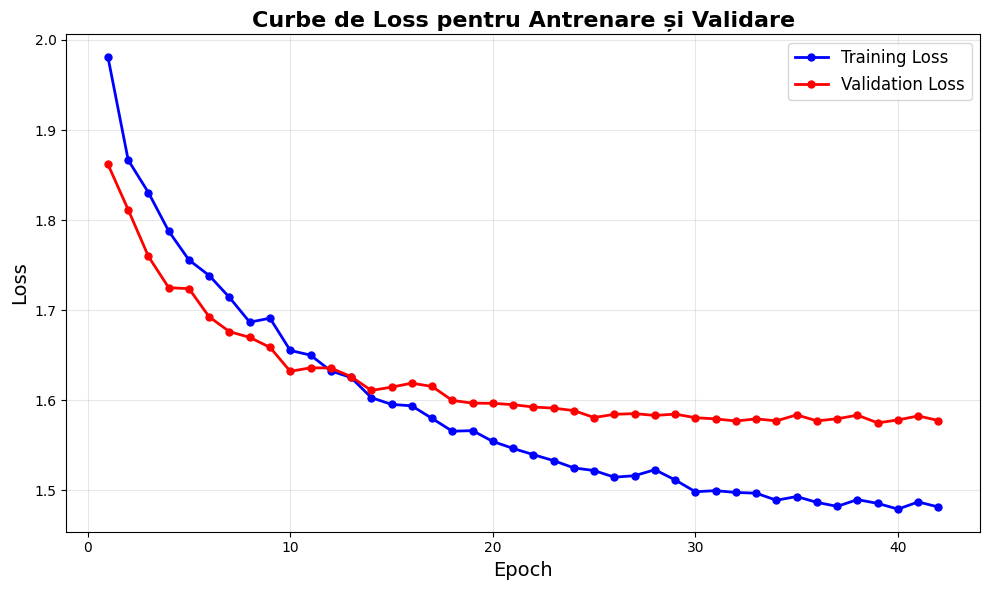

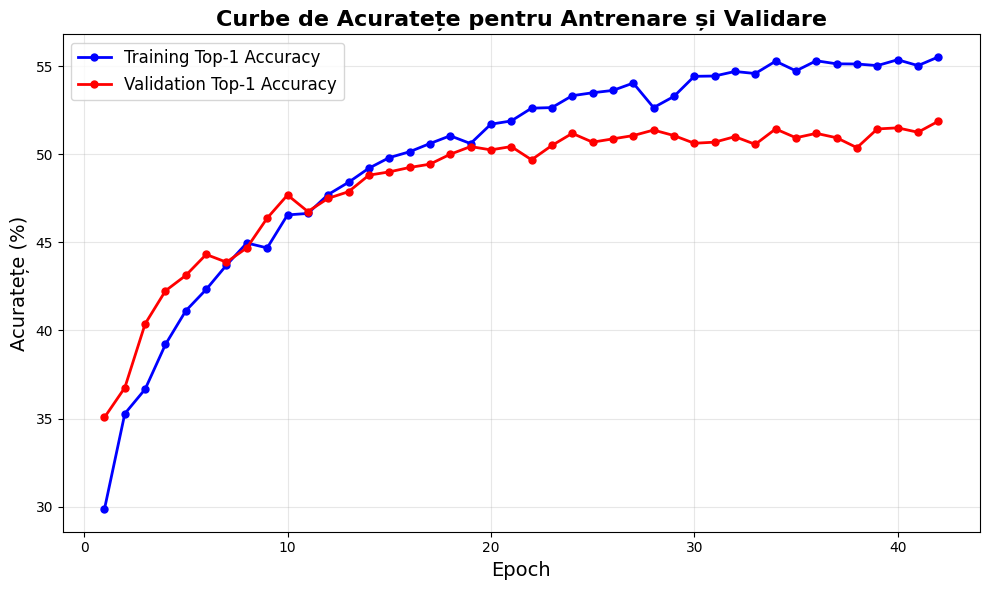

100%|██████████| 375/375 [00:17<00:00, 21.35it/s, epoch=43, train_loss=1.4872, top1_accuracy=55.08%]
Train - Loss: 1.4872, Top-1: 55.08%
100%|██████████| 50/50 [00:00<00:00, 52.18it/s, epoch=43, val_loss=1.5742, top1_accuracy=51.44%]
Val - Loss: 1.5742, Val - Top-1: 51.44%
EarlyStopping counter: 1 out of 7
100%|██████████| 375/375 [00:15<00:00, 24.08it/s, epoch=44, train_loss=1.4869, top1_accuracy=55.02%]
Train - Loss: 1.4869, Top-1: 55.02%
100%|██████████| 50/50 [00:00<00:00, 51.41it/s, epoch=44, val_loss=1.5744, top1_accuracy=51.56%]
Val - Loss: 1.5744, Val - Top-1: 51.56%
EarlyStopping counter: 2 out of 7
100%|██████████| 375/375 [00:15<00:00, 24.21it/s, epoch=45, train_loss=1.4694, top1_accuracy=56.03%]
Train - Loss: 1.4694, Top-1: 56.03%
100%|██████████| 50/50 [00:00<00:00, 54.62it/s, epoch=45, val_loss=1.5730, top1_accuracy=51.50%]
Val - Loss: 1.5730, Val - Top-1: 51.50%
EarlyStopping counter: 3 out of 7


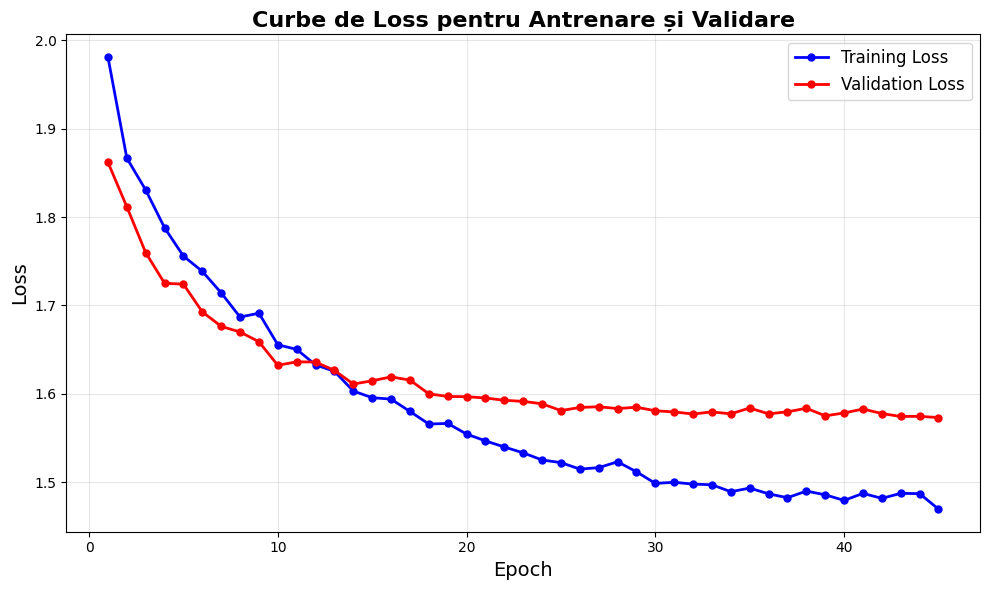

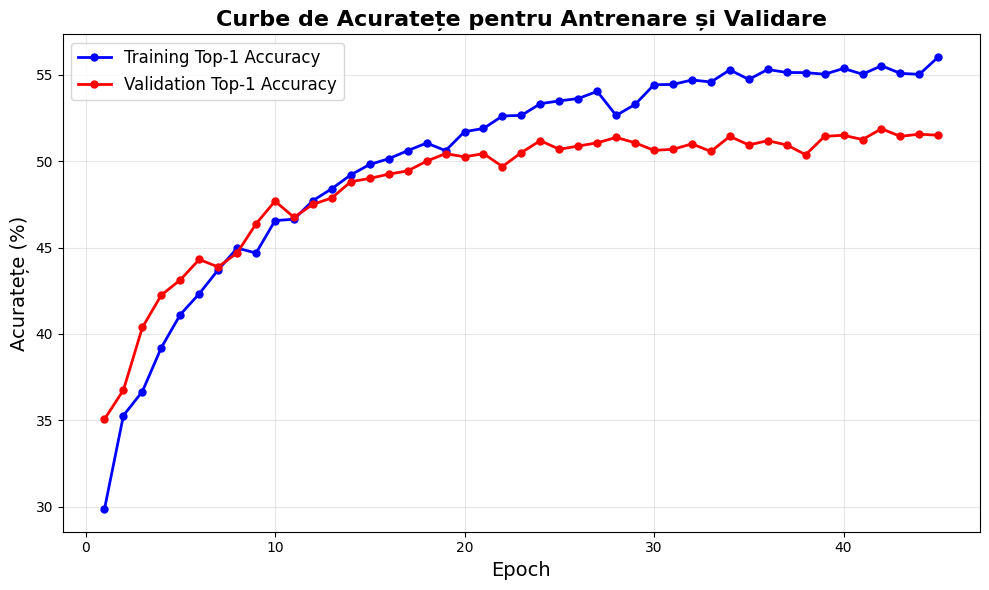

100%|██████████| 375/375 [00:17<00:00, 21.96it/s, epoch=46, train_loss=1.4757, top1_accuracy=55.39%]
Train - Loss: 1.4757, Top-1: 55.39%
100%|██████████| 50/50 [00:00<00:00, 52.03it/s, epoch=46, val_loss=1.5754, top1_accuracy=51.19%]
Val - Loss: 1.5754, Val - Top-1: 51.19%
EarlyStopping counter: 4 out of 7
100%|██████████| 375/375 [00:15<00:00, 23.93it/s, epoch=47, train_loss=1.4712, top1_accuracy=55.81%]
Train - Loss: 1.4712, Top-1: 55.81%
100%|██████████| 50/50 [00:00<00:00, 52.76it/s, epoch=47, val_loss=1.5703, top1_accuracy=51.12%]
Val - Loss: 1.5703, Val - Top-1: 51.12%
EarlyStopping counter: 5 out of 7
100%|██████████| 375/375 [00:15<00:00, 23.94it/s, epoch=48, train_loss=1.4679, top1_accuracy=55.83%]
Train - Loss: 1.4679, Top-1: 55.83%
100%|██████████| 50/50 [00:00<00:00, 54.68it/s, epoch=48, val_loss=1.5718, top1_accuracy=51.69%]
Val - Loss: 1.5718, Val - Top-1: 51.69%
EarlyStopping counter: 6 out of 7


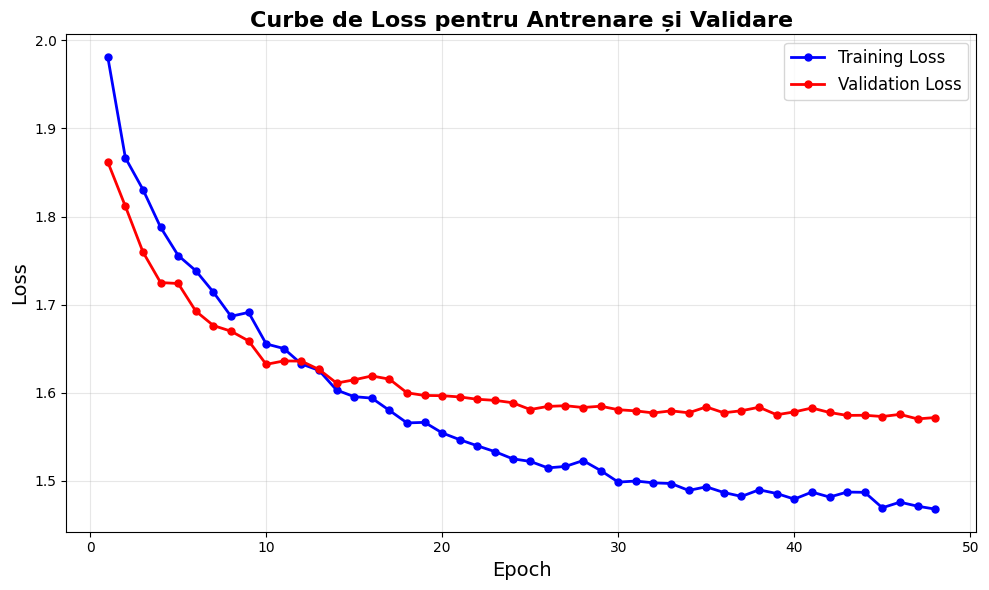

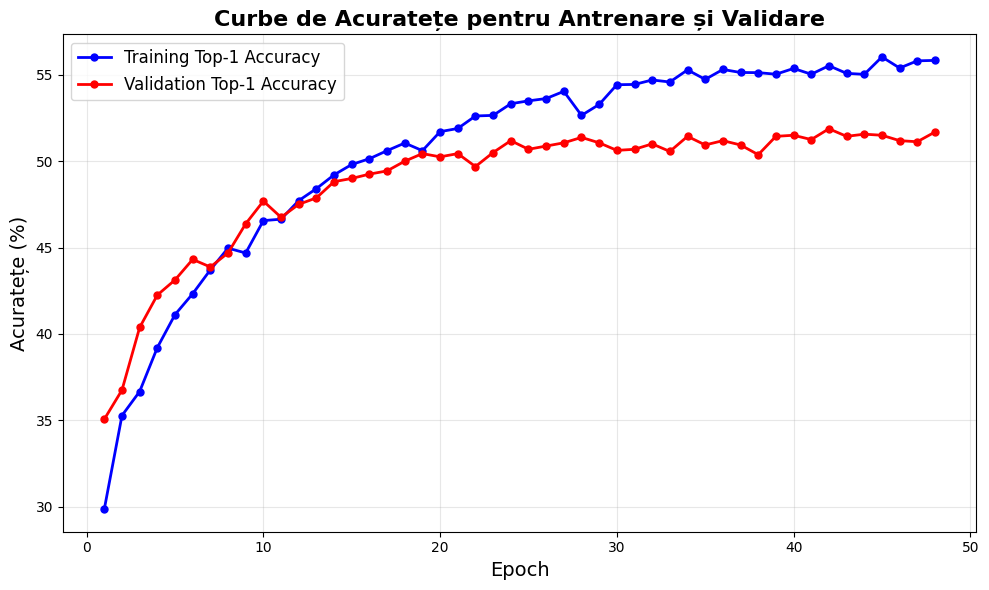

100%|██████████| 375/375 [00:17<00:00, 21.92it/s, epoch=49, train_loss=1.4715, top1_accuracy=55.81%]
Train - Loss: 1.4715, Top-1: 55.81%
100%|██████████| 50/50 [00:00<00:00, 54.66it/s, epoch=49, val_loss=1.5747, top1_accuracy=51.62%]
Val - Loss: 1.5747, Val - Top-1: 51.62%
EarlyStopping counter: 7 out of 7
Early stopping triggered at epoch 49

Model 5 Best Validation Accuracy: 51.88%

Ensemble Training Complete!

Individual Model Accuracies:
  Model 1: 51.19%
  Model 2: 51.88%
  Model 3: 51.12%
  Model 4: 51.25%
  Model 5: 51.88%

Average Accuracy: 51.46%


In [140]:
ensemble_configs = [
    {'lr': 8e-4, 'weight_decay': 1e-4, 'lr_decay': 0.92},
    {'lr': 1e-3, 'weight_decay': 8e-5, 'lr_decay': 0.93}, 
    {'lr': 6e-4, 'weight_decay': 3e-4, 'lr_decay': 0.91},
    {'lr': 9e-4, 'weight_decay': 9e-5, 'lr_decay': 0.925},
    {'lr': 7e-4, 'weight_decay': 1e-4, 'lr_decay': 0.915}
]

trained_models = []
model_accuracies = []

print(f"Starting Ensemble Training of {len(ensemble_configs)} models...\n")

for i, conf in enumerate(ensemble_configs):
    print(f"\n{'='*60}")
    print(f"Training Model {i+1}/{len(ensemble_configs)}")
    print(f"Config: lr={conf['lr']}, weight_decay={conf['weight_decay']}, lr_decay={conf['lr_decay']}")
    print(f"{'='*60}\n")
    
    model, best_acc = train_single_model(conf, train_loader, validation_loader, CFG.device)
    trained_models.append(model)
    model_accuracies.append(best_acc)
    
    print(f"\nModel {i+1} Best Validation Accuracy: {best_acc:.2f}%")

print(f"\n{'='*60}")
print("Ensemble Training Complete!")
print(f"{'='*60}")
print("\nIndividual Model Accuracies:")
for i, acc in enumerate(model_accuracies):
    print(f"  Model {i+1}: {acc:.2f}%")
print(f"\nAverage Accuracy: {np.mean(model_accuracies):.2f}%")

In [141]:
print("\nEvaluating Ensemble with TTA...")
for i in range(1,9):
    print(f" - Using {i} TTA augmentations...")
    y_pred_ens_tta, y_true_ens_tta = predict_ensemble_with_tta(trained_models, test_loader, CFG.device, num_tta=i)
    
    ens_tta_acc_i = accuracy_score(y_true_ens_tta, y_pred_ens_tta) * 100
    ens_tta_f1_i = f1_score(y_true_ens_tta, y_pred_ens_tta, average='weighted') * 100
    
    print(f"   Ensemble with {i} TTA Accuracy: {ens_tta_acc_i:.2f}%")
    print(f"   Ensemble with {i} TTA F1 Score: {ens_tta_f1_i:.2f}%")

# Compare with baseline
print("\nEvaluating Baseline Ensemble (without TTA)...")
y_pred_ensemble, y_true_ensemble = predict_ensemble(trained_models, test_loader, CFG.device)

ens_acc = accuracy_score(y_true_ensemble, y_pred_ensemble) * 100
ens_f1 = f1_score(y_true_ensemble, y_pred_ensemble, average='weighted') * 100

print(f"Baseline Ensemble Accuracy: {ens_acc:.2f}%")
print(f"Baseline Ensemble F1 Score: {ens_f1:.2f}%")


Evaluating Ensemble with TTA...
 - Using 1 TTA augmentations...


TTA Ensemble Prediction: 100%|██████████| 157/157 [00:47<00:00,  3.31it/s]


   Ensemble with 1 TTA Accuracy: 52.46%
   Ensemble with 1 TTA F1 Score: 51.90%
 - Using 2 TTA augmentations...


TTA Ensemble Prediction: 100%|██████████| 157/157 [01:11<00:00,  2.19it/s]


   Ensemble with 2 TTA Accuracy: 52.36%
   Ensemble with 2 TTA F1 Score: 51.84%
 - Using 3 TTA augmentations...


...

   Ensemble with 6 TTA Accuracy: 52.36%
   Ensemble with 6 TTA F1 Score: 51.84%
 - Using 7 TTA augmentations...


TTA Ensemble Prediction: 100%|██████████| 157/157 [01:16<00:00,  2.05it/s]


   Ensemble with 7 TTA Accuracy: 52.36%
   Ensemble with 7 TTA F1 Score: 51.84%
 - Using 8 TTA augmentations...


TTA Ensemble Prediction: 100%|██████████| 157/157 [01:15<00:00,  2.09it/s]


   Ensemble with 8 TTA Accuracy: 52.36%
   Ensemble with 8 TTA F1 Score: 51.84%

Evaluating Baseline Ensemble (without TTA)...
Baseline Ensemble Accuracy: 52.46%
Baseline Ensemble F1 Score: 51.90%



Evaluating Ensemble...
Ensemble Accuracy: 52.20%
Ensemble F1 Score: 51.70%

Generating Ensemble Confusion Matrix...


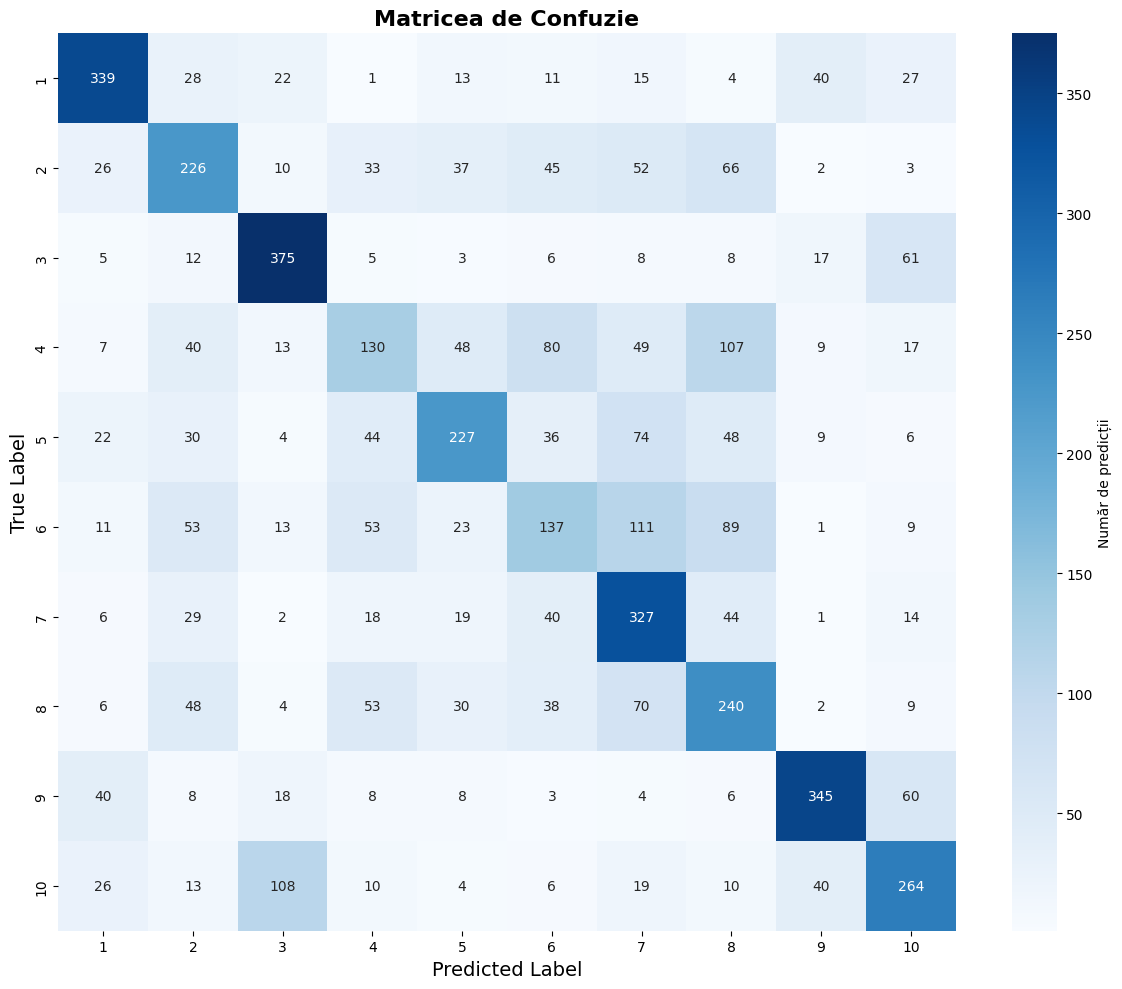

array([[339,  28,  22,   1,  13,  11,  15,   4,  40,  27],
       [ 26, 226,  10,  33,  37,  45,  52,  66,   2,   3],
       [  5,  12, 375,   5,   3,   6,   8,   8,  17,  61],
       [  7,  40,  13, 130,  48,  80,  49, 107,   9,  17],
       [ 22,  30,   4,  44, 227,  36,  74,  48,   9,   6],
       [ 11,  53,  13,  53,  23, 137, 111,  89,   1,   9],
       [  6,  29,   2,  18,  19,  40, 327,  44,   1,  14],
       [  6,  48,   4,  53,  30,  38,  70, 240,   2,   9],
       [ 40,   8,  18,   8,   8,   3,   4,   6, 345,  60],
       [ 26,  13, 108,  10,   4,   6,  19,  10,  40, 264]])

In [142]:
print("\nEvaluating Ensemble...")
y_pred_hard_ensemble, y_true_hard_ensemble = predict_hard_voting_ensemble(trained_models, test_loader, CFG.device)

ens_acc = accuracy_score(y_true_hard_ensemble, y_pred_hard_ensemble) * 100
ens_f1 = f1_score(y_true_hard_ensemble, y_pred_hard_ensemble, average='weighted') * 100

print(f"Ensemble Accuracy: {ens_acc:.2f}%")
print(f"Ensemble F1 Score: {ens_f1:.2f}%")

# Plot Confusion Matrix for Ensemble
print("\nGenerating Ensemble Confusion Matrix...")
plot_confusion_matrix(y_true_hard_ensemble, y_pred_hard_ensemble)